<a href="https://colab.research.google.com/github/romidj/PFE-CpG-islands/blob/main/CpG_sequence%2BchromHMM_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Downloads - CpG isalands + reference genome - UCSC**

In [ ]:
# Direct download — no need for Table Browser UI
!wget "https://hgdownload.soe.ucsc.edu/goldenPath/hg38/database/cpgIslandExt.txt.gz"
!gunzip cpgIslandExt.txt.gz

In [ ]:
# Full genome (~3GB uncompressed) — download once
! wget https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz
! gunzip hg38.fa.gz

# Index it for fast random access
! pip install pyfaidx
!faidx hg38.fa

**Move the downloaded data into the drive to avoid downloading it at each session**

In [ ]:
import os

base = "/content/drive/MyDrive/PFE/data"

os.makedirs(base, exist_ok=True)
os.makedirs(base + "/genome", exist_ok=True)
os.makedirs(base + "/cpg", exist_ok=True)
os.makedirs(base + "/epigenetics", exist_ok=True)
os.makedirs(base + "/processed", exist_ok=True)

In [ ]:
import shutil

src = "/content/hg38.fa"
dst = "/content/drive/MyDrive/PFE/data/genome/hg38.fa"

shutil.move(src, dst)

In [ ]:
import shutil

src = "/content/cpgIslandExt.txt"
dst = "/content/drive/MyDrive/PFE/data/cpg/cpgIslandExt.txt"

shutil.move(src, dst)

In [ ]:
import shutil

src = "/content/hg38.fa.fai"
dst = "/content/drive/MyDrive/PFE/data/genome/hg38.fa.fai"

shutil.move(src, dst)

#2. Load and filter CpG islands to canonical chromosomes


# Remove non-standard chromosomes because they correspond to alternative, unplaced, or low-confidence genomic regions that are not consistently represented in epigenetic datasets, may duplicate information, and would introduce noise and mismatches in your pipeline.

In [ ]:
!pip install pyfaidx

In [ ]:
import pandas as pd
import numpy as np
import pyfaidx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# UCSC cpgIslandExt columns
COLS = [
    'bin', 'chrom', 'start', 'end', 'name',
    'length', 'cpgNum', 'gcNum', 'perCpg', 'perGc', 'obsExp'
]

def load_cpg_islands(path):
    check = pd.read_csv(path)
    df_cpg = pd.read_csv(path, sep='\t', header=None, names=COLS)
    print("row data", check.head())
    print(f"Total CpG islands loaded: {len(df_cpg):,}")
    print(f"Chromosomes: {sorted(df_cpg['chrom'].unique())}")


    # Standard chromosomes only
    standard = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY']
    df_cpg = df_cpg[df_cpg['chrom'].isin(standard)].copy()

    # Drop bin column (UCSC internal)
    df_cpg = df_cpg.drop(columns=['bin'])

    # Recompute length to be safe
    df_cpg['length'] = df_cpg['end'] - df_cpg['start']

    df_cpg = df_cpg.reset_index(drop=True)

    # Unique ID
    df_cpg['island_id'] = (df_cpg['chrom'] + ':' +
                       df_cpg['start'].astype(str) + '-' +
                       df_cpg['end'].astype(str))

    print(f"Total CpG islands loaded: {len(df_cpg):,}")
    print(f"Chromosomes: {sorted(df_cpg['chrom'].unique())}")
    return df_cpg

df_cpg = load_cpg_islands('/content/drive/MyDrive/PFE/data/cpg/cpgIslandExt.txt')

row data   585\tchr1\t28735\t29737\tCpG: 111\t1002\t111\t731\t22.2\t73\t0.85
0  586\tchr1\t135124\t135563\tCpG: 30\t439\t30\t2...               
1  586\tchr1\t199251\t200121\tCpG: 104\t870\t104\...               
2  587\tchr1\t368792\t370063\tCpG: 99\t1271\t99\t...               
3  587\tchr1\t381172\t382185\tCpG: 84\t1013\t84\t...               
4  588\tchr1\t491107\t491546\tCpG: 29\t439\t29\t2...               
Total CpG islands loaded: 32,038
Chromosomes: ['chr1', 'chr10', 'chr10_GL383545v1_alt', 'chr10_GL383546v1_alt', 'chr10_KI270824v1_alt', 'chr10_KI270825v1_alt', 'chr10_KN196480v1_fix', 'chr10_KN538367v1_fix', 'chr10_KQ090021v1_fix', 'chr10_ML143354v1_fix', 'chr10_ML143355v1_fix', 'chr10_MU273367v1_fix', 'chr11', 'chr11_KI270721v1_random', 'chr11_KI270826v1_alt', 'chr11_KI270830v1_alt', 'chr11_KI270831v1_alt', 'chr11_KI270832v1_alt', 'chr11_KI270902v1_alt', 'chr11_KI270903v1_alt', 'chr11_KI270927v1_alt', 'chr11_KN196481v1_fix', 'chr11_KQ759759v1_fix', 'chr11_KQ759759v2_fix', 'ch

CpG islands located on alternative, unplaced, and patch contigs were excluded, retaining 27,949 islands on canonical chromosomes (chr1–22, X, Y).”

In [ ]:
df_cpg.head()

,chrom,start,end,name,length,cpgNum,gcNum,perCpg,perGc,obsExp,island_id
0,chr1,28735,29737,CpG: 111,1002,111,731,22.2,73.0,0.85,chr1:28735-29737
1,chr1,135124,135563,CpG: 30,439,30,295,13.7,67.2,0.64,chr1:135124-135563
2,chr1,199251,200121,CpG: 104,870,104,643,23.9,73.9,0.89,chr1:199251-200121
3,chr1,368792,370063,CpG: 99,1271,99,777,15.6,61.1,0.84,chr1:368792-370063
4,chr1,381172,382185,CpG: 84,1013,84,734,16.6,72.5,0.64,chr1:381172-382185


**For further uses of the cleaned cpG file, wo make .bed file and save it in the drive**

In [ ]:
output_path = "/content/drive/MyDrive/PFE/data/processed/cpg_without_sequence.bed"

df_cpg.to_csv(
    output_path,
    sep="\t",
    header=False,
    index=False
)

print(f"Saved to {output_path}")

---
## 3 · Extract island sequences from the reference genome

`pyfaidx` provides O(1) random-access to the indexed FASTA.  Coordinates follow
BED convention (0-based, end-exclusive) which matches the UCSC table exactly.

In [ ]:
def extract_sequences(df_cpg, genome_path='hg38.fa'):
    """
    Extract the exact island sequence for each CpG island.
    No windowing yet — raw island boundaries only.
    """
    genome = pyfaidx.Fasta("/content/drive/MyDrive/PFE/data/genome/hg38.fa")

    sequences = []
    skipped   = 0

    for _, row in df_cpg.iterrows():
        chrom = row['chrom']
        start = int(row['start'])
        end   = int(row['end'])

        # Skip if chrom not in genome
        if chrom not in genome:
            skipped += 1
            sequences.append(None)
            continue

        # pyfaidx: 0-based, end-exclusive — matches BED format exactly
        seq = str(genome[chrom][start:end]).upper()
        sequences.append(seq)

    genome.close()

    df_cpg['sequence'] = sequences
    df_cpg = df_cpg[df_cpg['sequence'].notna()].copy()

    print(f"Sequences extracted: {len(df_cpg):,}")
    print(f"Skipped: {skipped}")
    return df_cpg

df_cpg = extract_sequences(df_cpg)
df_cpg.head()

Sequences extracted: 27,949
Skipped: 0


,chrom,start,end,name,length,cpgNum,gcNum,perCpg,perGc,obsExp,island_id,sequence
0,chr1,28735,29737,CpG: 111,1002,111,731,22.2,73.0,0.85,chr1:28735-29737,CGCCTCTTTGGGACCGCGGTTTATACTTTCGAAGTGCTCGGAGCCC...
1,chr1,135124,135563,CpG: 30,439,30,295,13.7,67.2,0.64,chr1:135124-135563,CGCAGTGAGGCGAGAGCTAGCTGGGCGTGGAGAGTCCGCTGTGAGG...
2,chr1,199251,200121,CpG: 104,870,104,643,23.9,73.9,0.89,chr1:199251-200121,CGCCTCTTTGGGACCGCGGTTTATACTTTCGAAGTGCTCGGAGCCC...
3,chr1,368792,370063,CpG: 99,1271,99,777,15.6,61.1,0.84,chr1:368792-370063,CGGTGTGGAAACTGCGACACTCACACGGGTGCCATCTCAGCAGCTC...
4,chr1,381172,382185,CpG: 84,1013,84,734,16.6,72.5,0.64,chr1:381172-382185,CGGCCGGCGCACGCGGGTTCTCTGTGGCCAGCAGGCGGCGCTGCAG...


Save in the drive

In [ ]:
output_path = "/content/drive/MyDrive/PFE/data/processed/cpg_with_sequence.bed"

df_cpg.to_csv(
    output_path,
    sep="\t",
    header=False,
    index=False
)

print(f"Saved to {output_path}")

Saved to /content/drive/MyDrive/PFE/data/processed/cpg_with_sequence.bed


---
## 4 · Exploratory Data Analysis

We compute core biological properties (GC content, CpG density, N-content) to validate
that the extracted sequences are correct and suitable for modelling.


In [ ]:
def compute_sequence_stats(df_cpg: pd.DataFrame) -> pd.DataFrame:
    """
    Add per-island sequence statistics as new columns.

    Columns added
    -------------
    gc_content  : fraction of G+C bases
    n_content   : fraction of ambiguous 'N' bases
    actual_cpg  : raw count of CpG dinucleotides in the sequence
    cpg_density : CpG count per kilobase (actual_cpg / length * 1000)
    """
    df = df_cpg.copy()

    df["gc_content"]  = df["sequence"].apply(
        lambda s: (s.count("G") + s.count("C")) / len(s)
    )
    df["n_content"]   = df["sequence"].apply(
        lambda s: s.count("N") / len(s)
    )
    df["actual_cpg"]  = df["sequence"].apply(
        lambda s: sum(1 for i in range(len(s) - 1)
                      if s[i] == "C" and s[i + 1] == "G")
    )
    df["cpg_density"] = df["actual_cpg"] / (df["length"] / 1000)

    return df


df_cpg = compute_sequence_stats(df_cpg)

print("── Island Length ──")
print(df_cpg["length"].describe().round(1))
print("\n── GC Content ──")
print(df_cpg["gc_content"].describe().round(3))
print("\n── CpG Density (per kb) ──")
print(df_cpg["cpg_density"].describe().round(1))
print("\n── N content ──")
print(df_cpg["n_content"].describe().round(4))
print(f"Islands with any N: {(df_cpg['n_content'] > 0).sum():,}")

── Island Length ──
count    27949.0
mean       779.7
std        827.8
min        201.0
25%        328.0
50%        575.0
75%        969.0
max      45712.0
Name: length, dtype: float64

── GC Content ──
count    27949.000
mean         0.687
std          0.050
min          0.502
25%          0.654
50%          0.688
75%          0.722
max          0.873
Name: gc_content, dtype: float64

── CpG Density (per kb) ──
count    27949.0
mean        97.8
std         19.9
min         58.3
25%         81.8
50%         94.7
75%        110.8
max        226.1
Name: cpg_density, dtype: float64

── N content ──
count    27949.0000
mean         0.0000
std          0.0000
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max          0.0004
Name: n_content, dtype: float64
Islands with any N: 1


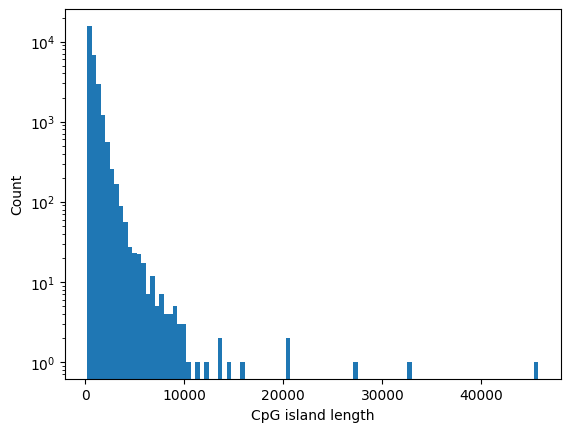

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df_cpg['length'], bins=100)
plt.yscale('log')
plt.xlabel("CpG island length")
plt.ylabel("Count")
plt.show()

In [ ]:
outliers = df_cpg[df_cpg['length'] >= 5000].copy()

print(outliers.shape)
outliers.head()
print(outliers['chrom'].value_counts())

(110, 16)
chrom
chr1     9
chr10    9
chr17    8
chr16    7
chr8     7
chr7     6
chr19    6
chr15    6
chr9     6
chrX     5
chr2     5
chr21    5
chr5     4
chr22    4
chr20    4
chr18    4
chr6     4
chr4     3
chr12    3
chr11    1
chr13    1
chr14    1
chr3     1
chrY     1
Name: count, dtype: int64


CpG islands exceeding 10 kb were identified as extreme outliers, lying beyond the 99.9th percentile of the length distribution. These regions also exhibited reduced CpG density (lower observed/expected CpG ratio), suggesting they do not follow the same structural properties as canonical CpG islands. Given their rarity (0.05%) and disproportionate impact on tiling-based representation, they were excluded from the training dataset.

In [ ]:
outliers = df_cpg[df_cpg['length'] >= 10000].copy()

print(outliers.shape)
outliers.head()
print(outliers['chrom'].value_counts())

(14, 16)
chrom
chr10    4
chrX     3
chr4     2
chr7     2
chr1     1
chr15    1
chr8     1
Name: count, dtype: int64


In [ ]:
print(outliers['gc_content'].describe())
print(df_cpg['gc_content'].describe())

count    14.000000
mean      0.645263
std       0.048402
min       0.592430
25%       0.616614
50%       0.625429
75%       0.669433
max       0.726558
Name: gc_content, dtype: float64
count    27949.000000
mean         0.686950
std          0.049962
min          0.501558
25%          0.654004
50%          0.688172
75%          0.721719
max          0.872807
Name: gc_content, dtype: float64


The islands with length >  10000 's gc content is remarcably less then the rest of the islands

**Remove the outliers, sequence > 10000**
Extremely long CpG islands (>10 kb) were excluded from the dataset. These regions accounted for only 0.05% of all islands (14 out of ~28,000) and lay in the extreme tail of the length distribution. Additionally, they exhibited lower GC content compared to the overall dataset, suggesting distinct structural properties. Their inclusion would require extensive tiling into multiple overlapping windows, introducing potential imbalance and noise in the training process. Therefore, they were removed to ensure a consistent and representative dataset for modeling

In [ ]:
threshold = 10000
print(f"Original: {len(df_cpg):,}")


df_cpg = df_cpg[df_cpg['length'] <= threshold].copy()

print(f"after_removing: {len(df_cpg):,}")


Original: 27,949
after_removing: 27,935


In [ ]:
# Saving the outliers just in case
outliers = df_cpg[df_cpg['length'] > threshold].copy()

outliers.to_csv(
    "/content/drive/MyDrive/PFE/data/processed/cpg_outliers_gt_10kb.csv",
    index=False
)

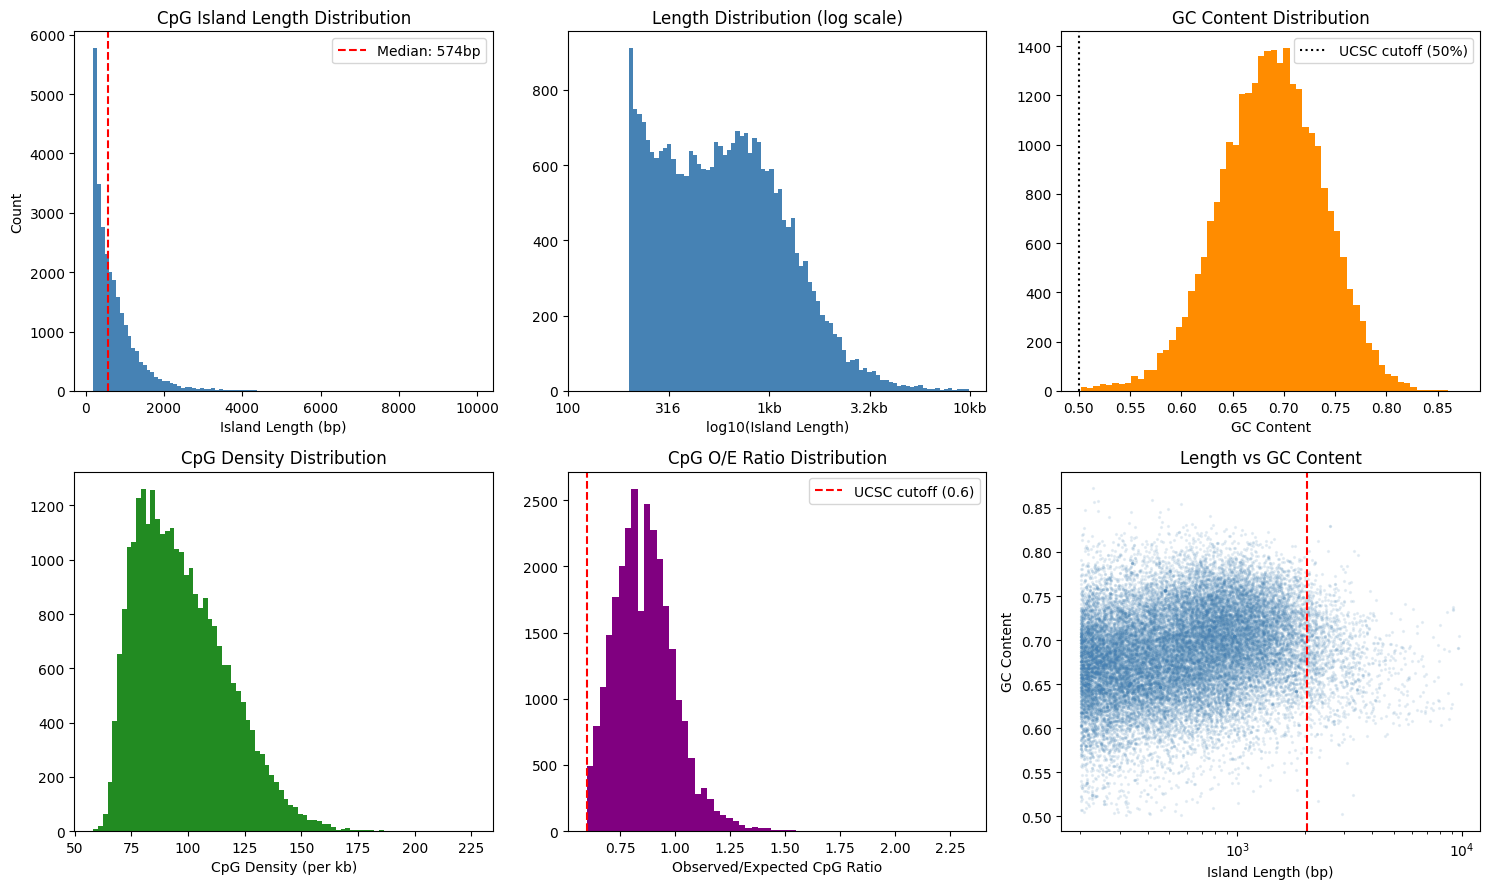

In [ ]:
# ── 4.2  Length distribution ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Length histogram
ax = axes[0, 0]
ax.hist(df_cpg['length'], bins=100, color='steelblue', edgecolor='none')
ax.axvline(df_cpg['length'].median(), color='red',
           linestyle='--', label=f"Median: {df_cpg['length'].median():.0f}bp")
ax.set_xlabel('Island Length (bp)')
ax.set_ylabel('Count')
ax.set_title('CpG Island Length Distribution')
ax.legend()

# Log-scale length
ax = axes[0, 1]
ax.hist(np.log10(df_cpg['length']), bins=80, color='steelblue', edgecolor='none')
ax.set_xlabel('log10(Island Length)')
ax.set_title('Length Distribution (log scale)')
ax.set_xticks([2, 2.5, 3, 3.5, 4])
ax.set_xticklabels(['100', '316', '1kb', '3.2kb', '10kb'])

# GC content
ax = axes[0, 2]
ax.hist(df_cpg['gc_content'], bins=60, color='darkorange', edgecolor='none')
ax.axvline(0.5, color='black', linestyle=':', label='UCSC cutoff (50%)')
ax.set_xlabel('GC Content')
ax.set_title('GC Content Distribution')
ax.legend()

# CpG density
ax = axes[1, 0]
ax.hist(df_cpg['cpg_density'], bins=80, color='forestgreen', edgecolor='none')
ax.set_xlabel('CpG Density (per kb)')
ax.set_title('CpG Density Distribution')

# obsExp ratio
ax = axes[1, 1]
ax.hist(df_cpg['obsExp'], bins=60, color='purple', edgecolor='none')
ax.axvline(0.6, color='red', linestyle='--', label='UCSC cutoff (0.6)')
ax.set_xlabel('Observed/Expected CpG Ratio')
ax.set_title('CpG O/E Ratio Distribution')
ax.legend()

# Length vs GC scatter
ax = axes[1, 2]
ax.scatter(df_cpg['length'], df_cpg['gc_content'],
           alpha=0.1, s=2, color='steelblue')
ax.set_xlabel('Island Length (bp)')
plt.axvline(2048, color='red', linestyle='--') #to highlight outliers
ax.set_ylabel('GC Content')
ax.set_title('Length vs GC Content')
ax.set_xscale('log')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PFE/data/Figures/01_island_properties.png', dpi=150)
plt.show()

# Invistigating the most appropreate window size , comparing between 1024, 2048, 4096

# 4.3 · N-content & assembly gaps

---



In [ ]:
# ── 4.4  N-content analysis (important for windowing decisions) ──────────

print("\n── Islands with high N content ──")
print(df_cpg[df_cpg['n_content'] > 0.05][['island_id', 'chrom',
                                    'length', 'n_content']].head(20))

# Consecutive N runs (assembly gaps)
def max_n_run(seq):
    max_run = 0
    current = 0
    for base in seq:
        if base == 'N':
            current += 1
            max_run = max(max_run, current)
        else:
            current = 0
    return max_run

df_cpg['max_n_run'] = df_cpg['sequence'].apply(max_n_run)

print(f"\nIslands with N-run > 10bp: {(df_cpg['max_n_run'] > 10).sum()}")
print(f"Islands with N-run > 50bp: {(df_cpg['max_n_run'] > 50).sum()}")


── Islands with high N content ──
Empty DataFrame
Columns: [island_id, chrom, length, n_content]
Index: []

Islands with N-run > 10bp: 0
Islands with N-run > 50bp: 0


### 4.4 · Length quantiles — window-size decision

In [ ]:
# ── 4.5  Length quantiles — critical for windowing choice ───────────────

quantiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
print("\n── Length Quantiles ──")
for q in quantiles:
    val = df_cpg['length'].quantile(q)
    print(f"  {int(q*100):3d}th percentile: {val:,.0f} bp")

print(f"\nIslands > 1kb:  {(df_cpg['length'] > 1000).sum():,} "
      f"({100*(df_cpg['length']>1000).mean():.1f}%)")
print(f"Islands > 2kb:  {(df_cpg['length'] > 2000).sum():,} "
      f"({100*(df_cpg['length']>2000).mean():.1f}%)")
print(f"Islands > 4kb:  {(df_cpg['length'] > 4000).sum():,} "
      f"({100*(df_cpg['length']>4000).mean():.1f}%)")
print(f"Islands < 2kb:  {(df_cpg['length'] < 2000).sum():,} "
      f"({100*(df_cpg['length']<2000).mean():.1f}%)")


── Length Quantiles ──
   25th percentile: 328 bp
   50th percentile: 574 bp
   75th percentile: 969 bp
   90th percentile: 1,493 bp
   95th percentile: 1,947 bp
   99th percentile: 3,417 bp
  100th percentile: 9,915 bp

Islands > 1kb:  6,589 (23.6%)
Islands > 2kb:  1,303 (4.7%)
Islands > 4kb:  175 (0.6%)
Islands < 2kb:  26,628 (95.3%)


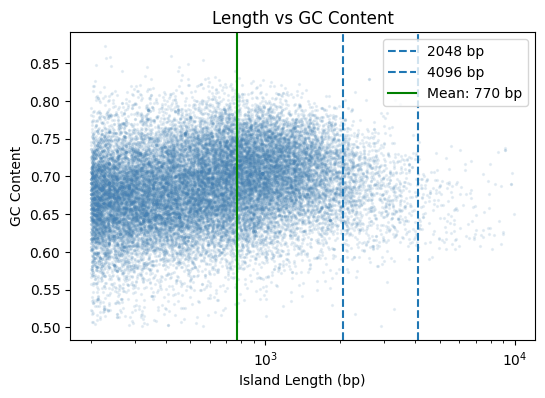

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(df_cpg['length'], df_cpg['gc_content'],
           alpha=0.1, s=2, color='steelblue')

ax.set_xlabel('Island Length (bp)')
ax.set_ylabel('GC Content')
ax.set_title('Length vs GC Content')
ax.set_xscale('log')

thresholds = [2048, 4096]
mean_length = df_cpg['length'].mean()

for t in thresholds:
    ax.axvline(t, linestyle='--', label=f'{t} bp')

ax.axvline(mean_length, color='green', linestyle='-', label=f'Mean: {int(mean_length)} bp')

ax.legend()

plt.show()

In [ ]:
# Total number of islands
total = len(df_cpg)

# Thresholds
t1 = 1024
t2 = 2048

# Counts
count_1024 = (df_cpg['length'] > t1).sum()
count_2048 = (df_cpg['length'] > t2).sum()

# Percentages
pct_1024 = (count_1024 / total) * 100
pct_2048 = (count_2048 / total) * 100

print(f"Islands > {t1} bp: {count_1024:,} ({pct_1024:.2f}%)")
print(f"Islands > {t2} bp: {count_2048:,} ({pct_2048:.2f}%)")

Islands > 1024 bp: 6,295 (22.53%)
Islands > 2048 bp: 1,229 (4.40%)


       min_len    mean_len  max_len
chrom                              
chr1       201  753.717443     8766
chr2       201  834.531510     6969
chr3       201  769.122837     6779
chr4       201  790.594330     5439
chr5       201  793.046117     8783
chr6       201  770.019124     8265
chr7       201  731.784810     7543
chr8       201  843.256015     8588
chr9       201  775.696039     7875
chr10      201  822.723514     7890
chr11      201  761.632385     7460
chr12      202  723.099917     6003
chr13      201  762.006536     5567
chr14      201  810.665829     5578
chr15      201  836.493590     6960
chr16      201  751.367089     9002
chr17      201  796.974545     9915
chr18      201  881.988212     7427
chr19      201  667.077849     7814
chr20      201  764.735537     6510
chr21      202  781.354260     9174
chr22      201  801.807327     7904
chrX       201  765.044018     9659
chrY       207  641.381443     9659


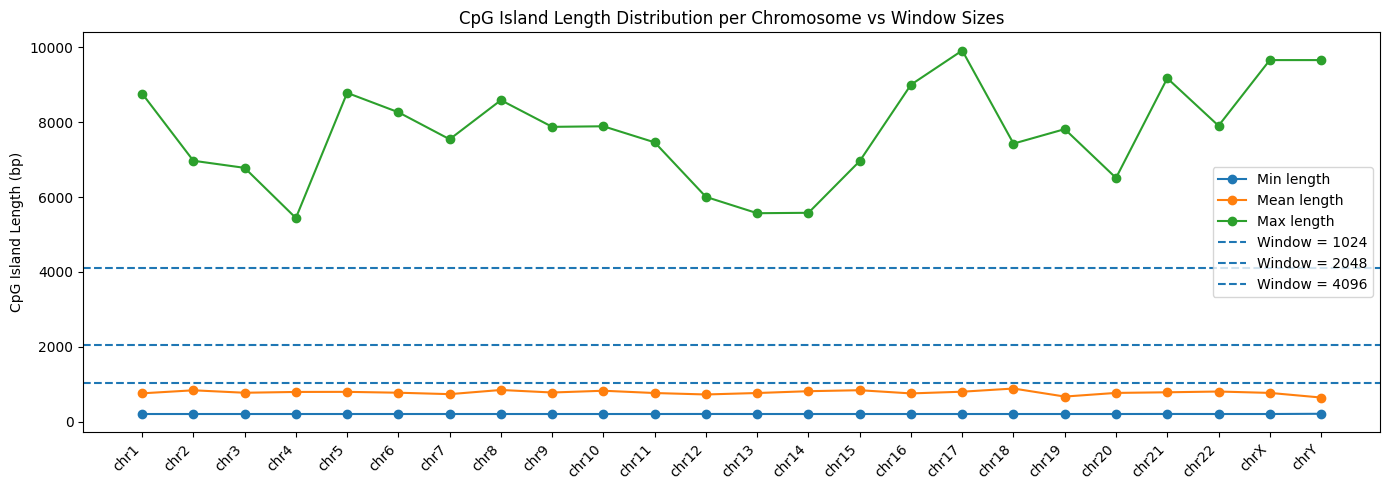

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Chromosome order
chrom_order = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY']

# Compute per-chromosome statistics
chrom_stats = df_cpg.groupby('chrom')['length'].agg(
    min_len='min',
    mean_len='mean',
    max_len='max'
).reindex(chrom_order)

print(chrom_stats)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

x = range(len(chrom_stats))

# Plot min / mean / max
ax.plot(x, chrom_stats['min_len'], marker='o', label='Min length')
ax.plot(x, chrom_stats['mean_len'], marker='o', label='Mean length')
ax.plot(x, chrom_stats['max_len'], marker='o', label='Max length')

# Reference window sizes
ax.axhline(1024, linestyle='--', label='Window = 1024')
ax.axhline(2048, linestyle='--', label='Window = 2048')
ax.axhline(4096, linestyle='--', label='Window = 4096')

ax.set_xticks(x)
ax.set_xticklabels(chrom_stats.index, rotation=45, ha='right')

ax.set_ylabel("CpG Island Length (bp)")
ax.set_title("CpG Island Length Distribution per Chromosome vs Window Sizes")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

chrom_order = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY']

# Global mean
global_mean = df_cpg['length'].mean()
print("Global mean length:", global_mean)

# Function to compute % above threshold
def percent_above(df, threshold):
    return df.groupby('chrom').apply(
        lambda x: (x['length'] > threshold).mean() * 100
    ).reindex(chrom_order)

# Compute all percentages correctly
percent_above_mean  = percent_above(df_cpg, global_mean)
percent_above_1024  = percent_above(df_cpg, 1024)
percent_above_2048  = percent_above(df_cpg, 2048)
percent_above_4096  = percent_above(df_cpg, 4096)

# Basic stats
chrom_stats = df_cpg.groupby('chrom')['length'].agg(['min','mean','max']).reindex(chrom_order)

# Combine
summary = chrom_stats.copy()
summary['% > mean']  = percent_above_mean
summary['% > 1024']  = percent_above_1024
summary['% > 2048']  = percent_above_2048
summary['% > 4096']  = percent_above_4096

print(summary)


Global mean length: 770.8117057454806
       min        mean   max   % > mean   % > 1024  % > 2048  % > 4096
chrom                                                                 
chr1   201  753.717443  8766  35.122336  20.520916  3.512234  0.394633
chr2   201  834.531510  6969  40.249703  27.110583  5.648038  0.594530
chr3   201  769.122837  6779  37.456747  23.096886  3.373702  0.173010
chr4   201  790.594330  5439  36.852395  24.926686  4.985337  0.293255
chr5   201  793.046117  8783  38.592233  23.948220  4.854369  0.647249
chr6   201  770.019124  8265  35.537849  20.876494  4.621514  0.478088
chr7   201  731.784810  7543  34.620253  21.075949  3.670886  0.443038
chr8   201  843.256015  8588  41.385948  25.794033  5.774783  1.058710
chr9   201  775.696039  7875  36.378335  23.524656  4.527082  0.646726
chr10  201  822.723514  7890  38.845823  24.978467  5.857020  0.602929
chr11  201  761.632385  7460  37.490883  23.632385  3.501094  0.437637
chr12  202  723.099917  6003  33.938893

/tmp/ipykernel_4226/2624293170.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('chrom').apply(
/tmp/ipykernel_4226/2624293170.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('chrom').apply(
/tmp/ipykernel_4226/2624293170.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pan

**Save in the drive as .bed file**

In [ ]:
output_path = "/content/drive/MyDrive/PFE/data/processed/cpg_last_version_befor_windows.bed"

df_cpg.to_csv(
    output_path,
    sep="\t",
    header=False,
    index=False
)

print(f"Saved to {output_path}")

Saved to /content/drive/MyDrive/PFE/data/processed/cpg_last_version_befor_windows.bed


**Save as a .paquet file**

In [ ]:
!pip install pyarrow

In [ ]:
import pandas as pd

input_path = "/content/drive/MyDrive/PFE/data/processed/cpg_last_version_before_windows.parquet"

df_cpg = pd.read_parquet(input_path)

In [ ]:
df_cpg.head()

,chrom,start,end,name,length,cpgNum,gcNum,perCpg,perGc,obsExp,island_id,sequence,gc_content,n_content,actual_cpg,cpg_density,max_n_run
0,chr1,28735,29737,CpG: 111,1002,111,731,22.2,73.0,0.85,chr1:28735-29737,CGCCTCTTTGGGACCGCGGTTTATACTTTCGAAGTGCTCGGAGCCC...,0.729541,0.0,111,110.778443,0
1,chr1,135124,135563,CpG: 30,439,30,295,13.7,67.2,0.64,chr1:135124-135563,CGCAGTGAGGCGAGAGCTAGCTGGGCGTGGAGAGTCCGCTGTGAGG...,0.671982,0.0,30,68.337130,0
2,chr1,199251,200121,CpG: 104,870,104,643,23.9,73.9,0.89,chr1:199251-200121,CGCCTCTTTGGGACCGCGGTTTATACTTTCGAAGTGCTCGGAGCCC...,0.739080,0.0,104,119.540230,0
3,chr1,368792,370063,CpG: 99,1271,99,777,15.6,61.1,0.84,chr1:368792-370063,CGGTGTGGAAACTGCGACACTCACACGGGTGCCATCTCAGCAGCTC...,0.610543,0.0,99,77.891424,0
4,chr1,381172,382185,CpG: 84,1013,84,734,16.6,72.5,0.64,chr1:381172-382185,CGGCCGGCGCACGCGGGTTCTCTGTGGCCAGCAGGCGGCGCTGCAG...,0.724580,0.0,84,82.922014,0


/tmp/ipykernel_3405/1161699036.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('chrom').apply(
/tmp/ipykernel_3405/1161699036.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('chrom').apply(
/tmp/ipykernel_3405/1161699036.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pan

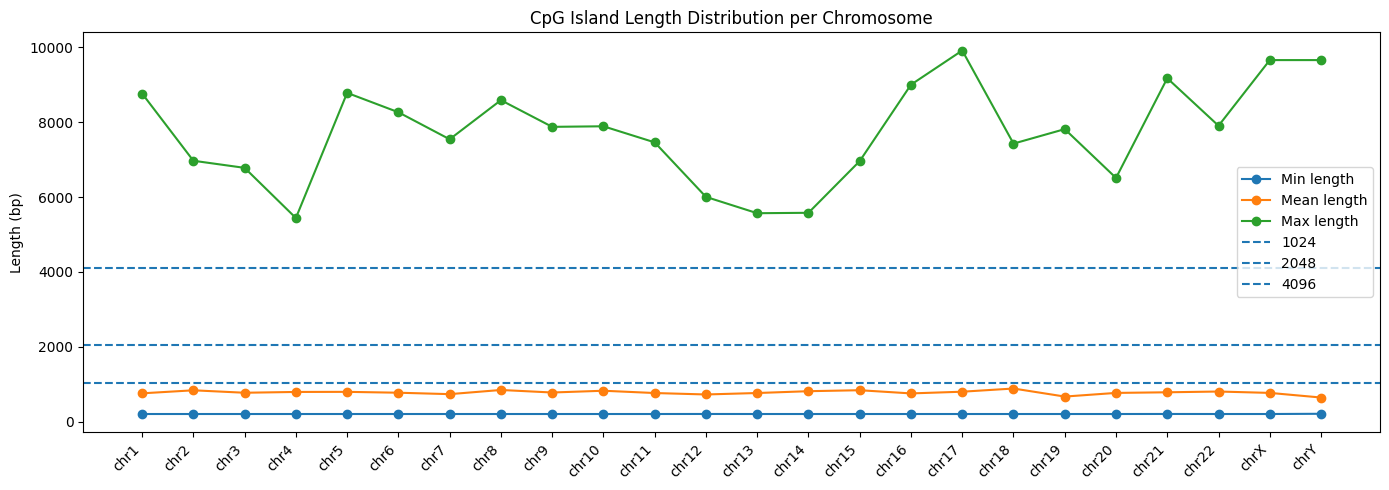

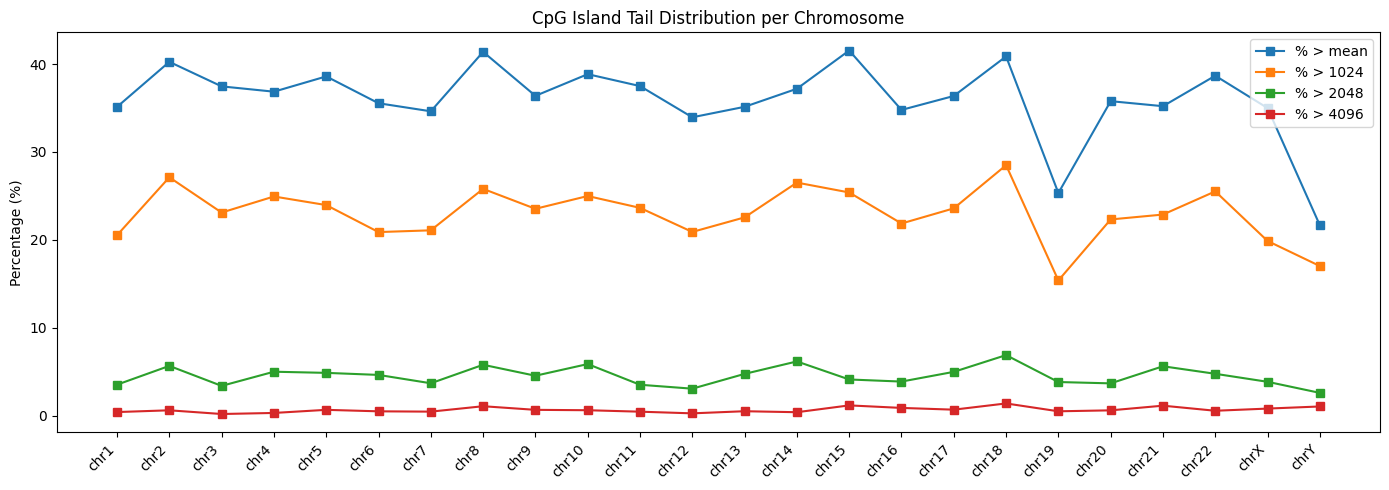

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

chrom_order = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY']

# Global mean
global_mean = df_cpg['length'].mean()

# Helper function
def percent_above(df, threshold):
    return df.groupby('chrom').apply(
        lambda x: (x['length'] > threshold).mean() * 100
    ).reindex(chrom_order)

# Stats
chrom_stats = df_cpg.groupby('chrom')['length'].agg(['min','mean','max']).reindex(chrom_order)

# Percentiles
pct_mean  = percent_above(df_cpg, global_mean)
pct_1024  = percent_above(df_cpg, 1024)
pct_2048  = percent_above(df_cpg, 2048)
pct_4096  = percent_above(df_cpg, 4096)

x = range(len(chrom_order))

# =========================
# 🔹 PLOT 1: LENGTH STRUCTURE
# =========================
fig, ax1 = plt.subplots(figsize=(14,5))

ax1.plot(x, chrom_stats['min'], marker='o', label='Min length')
ax1.plot(x, chrom_stats['mean'], marker='o', label='Mean length')
ax1.plot(x, chrom_stats['max'], marker='o', label='Max length')

ax1.axhline(1024, linestyle='--', label='1024')
ax1.axhline(2048, linestyle='--', label='2048')
ax1.axhline(4096, linestyle='--', label='4096')

ax1.set_xticks(x)
ax1.set_xticklabels(chrom_order, rotation=45, ha='right')
ax1.set_ylabel("Length (bp)")
ax1.set_title("CpG Island Length Distribution per Chromosome")

ax1.legend()
plt.tight_layout()
plt.show()

# =========================
# 🔹 PLOT 2: TAIL BEHAVIOR
# =========================
fig, ax2 = plt.subplots(figsize=(14,5))

ax2.plot(x, pct_mean, marker='s', label='% > mean')
ax2.plot(x, pct_1024, marker='s', label='% > 1024')
ax2.plot(x, pct_2048, marker='s', label='% > 2048')
ax2.plot(x, pct_4096, marker='s', label='% > 4096')

ax2.set_xticks(x)
ax2.set_xticklabels(chrom_order, rotation=45, ha='right')
ax2.set_ylabel("Percentage (%)")
ax2.set_title("CpG Island Tail Distribution per Chromosome")

ax2.legend()
plt.tight_layout()
plt.show()

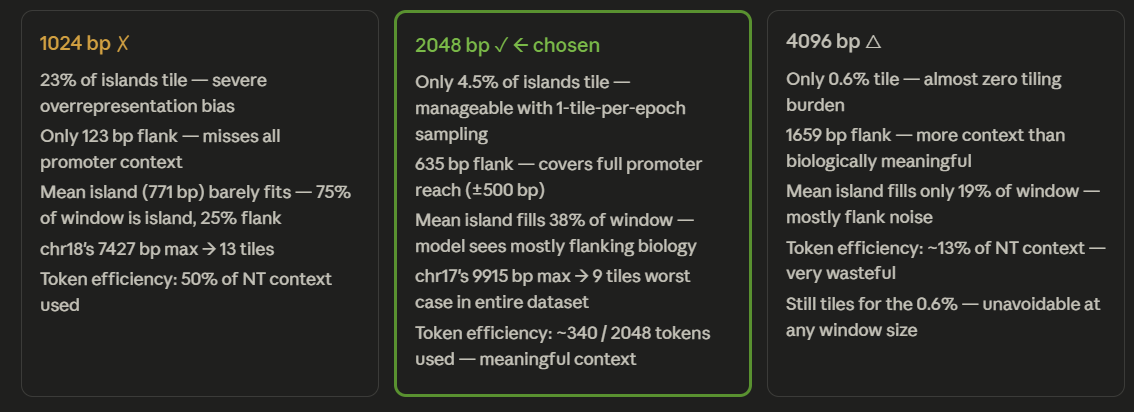

* This motivates us to take the decision of making our winows 2048 And the left ~4% we are going to tile them

**Invistigating the distribution of the islands with length > 2048, across chromosomes, and how correct is our decision of tile them is *correct***

In [ ]:
# ---- Tiling analysis in one cell ----

WINDOW = 2048
STRIDE = 1024  # overlap
MAX_TILES = None  # set to an int (e.g., 5) to cap tiles per island

# Compute number of tiles per island
def compute_tiles(length):
    if length <= WINDOW:
        return 1
    return int((length - WINDOW) / STRIDE) + 1

df_cpg['num_tiles'] = df_cpg['length'].apply(compute_tiles)

# Optional: cap number of tiles to avoid explosion
if MAX_TILES is not None:
    df_cpg['num_tiles'] = df_cpg['num_tiles'].clip(upper=MAX_TILES)

# Global stats
total_islands = len(df_cpg)
total_tiles = df_cpg['num_tiles'].sum()
expansion = total_tiles / total_islands

print("=== Global Stats ===")
print(f"Total islands: {total_islands:,}")
print(f"Total tiles: {total_tiles:,}")
print(f"Expansion factor: {expansion:.2f}x")

# Tile distribution
print("\n=== Tiles per island (distribution) ===")
print(df_cpg['num_tiles'].describe())

# Long islands contribution
long_islands = df_cpg[df_cpg['length'] > WINDOW]

pct_long_islands = len(long_islands) / total_islands * 100
pct_tiles_from_long = long_islands['num_tiles'].sum() / total_tiles * 100

print("\n=== Long Island Contribution ===")
print(f"Islands > {WINDOW} bp: {len(long_islands):,} ({pct_long_islands:.2f}%)")
print(f"Tiles from long islands: {pct_tiles_from_long:.2f}%")

# Worst-case examples
print("\n=== Top 10 longest islands (tile explosion risk) ===")
print(df_cpg[['length', 'num_tiles']].sort_values(by='num_tiles', ascending=False).head(10))

=== Global Stats ===
Total islands: 27,935
Total tiles: 28,672
Expansion factor: 1.03x

=== Tiles per island (distribution) ===
count    27935.000000
mean         1.026383
std          0.275198
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          8.000000
Name: num_tiles, dtype: float64

=== Long Island Contribution ===
Islands > 2048 bp: 1,229 (4.40%)
Tiles from long islands: 6.86%

=== Top 10 longest islands (tile explosion risk) ===
       length  num_tiles
27771    9659          8
10056    9709          8
11075    9915          8
26885    9659          8
20685    8783          7
20676    8656          7
17203    9174          7
17197    9122          7
17194    9161          7
10590    8977          7


### Interpretation of Tiling Analysis (WINDOW = 2048)

The tiling analysis shows that the chosen window size of 2048 bp provides a well-balanced representation of CpG islands without introducing significant bias or computational overhead. The total number of tiles (29,820) compared to the number of original islands (27,935) results in a very low expansion factor of 1.07×, indicating that tiling only marginally increases the dataset size.

The distribution of tiles per island confirms that tiling is not the dominant behavior: the median and 75th percentile are both equal to 1, meaning that at least 75% of CpG islands are represented by a single window. Only a small fraction of islands (4.40%) exceed the window size and require tiling.

Although these long islands generate multiple tiles, their overall contribution remains controlled, accounting for approximately 10.44% of the total tiles. This indicates a moderate overrepresentation but not to a degree that would significantly bias the training process. Extreme cases (up to 16 tiles) are rare and correspond to the longest islands near the upper length threshold.

Overall, these results demonstrate that the 2048 bp window size effectively captures the majority of CpG islands without excessive truncation, while the tiling strategy ensures coverage of longer regions in a controlled and computationally efficient manner.


In [ ]:
df_cpg.head()

,chrom,start,end,name,length,cpgNum,gcNum,perCpg,perGc,obsExp,island_id,sequence,gc_content,n_content,actual_cpg,cpg_density,max_n_run,num_tiles
0,chr1,28735,29737,CpG: 111,1002,111,731,22.2,73.0,0.85,chr1:28735-29737,CGCCTCTTTGGGACCGCGGTTTATACTTTCGAAGTGCTCGGAGCCC...,0.729541,0.0,111,110.778443,0,1
1,chr1,135124,135563,CpG: 30,439,30,295,13.7,67.2,0.64,chr1:135124-135563,CGCAGTGAGGCGAGAGCTAGCTGGGCGTGGAGAGTCCGCTGTGAGG...,0.671982,0.0,30,68.337130,0,1
2,chr1,199251,200121,CpG: 104,870,104,643,23.9,73.9,0.89,chr1:199251-200121,CGCCTCTTTGGGACCGCGGTTTATACTTTCGAAGTGCTCGGAGCCC...,0.739080,0.0,104,119.540230,0,1
3,chr1,368792,370063,CpG: 99,1271,99,777,15.6,61.1,0.84,chr1:368792-370063,CGGTGTGGAAACTGCGACACTCACACGGGTGCCATCTCAGCAGCTC...,0.610543,0.0,99,77.891424,0,1
4,chr1,381172,382185,CpG: 84,1013,84,734,16.6,72.5,0.64,chr1:381172-382185,CGGCCGGCGCACGCGGGTTCTCTGTGGCCAGCAGGCGGCGCTGCAG...,0.724580,0.0,84,82.922014,0,1


In [ ]:
df_cpg[df_cpg['num_tiles'] > 1].head()

,chrom,start,end,name,length,cpgNum,gcNum,perCpg,perGc,obsExp,island_id,sequence,gc_content,n_content,actual_cpg,cpg_density,max_n_run,num_tiles
22,chr1,958933,967274,CpG: 616,8341,616,5522,14.8,66.2,0.67,chr1:958933-967274,CGAGGGGCTCCCGCCCGGCTTATCCGGACTCCGGGCAGCCTCGCGT...,0.689845,0.0,656,78.647644,0,7
24,chr1,976046,979425,CpG: 248,3379,248,2430,14.7,71.9,0.62,chr1:976046-979425,CGCCCCCCTCCTGGACGCGGTAGAAGAGAGGGGTCAGAGGGCCCGG...,0.718556,0.0,248,73.394495,0,2
26,chr1,998007,1002030,CpG: 410,4023,410,2687,20.4,66.8,0.91,chr1:998007-1002030,CGCTCGCCTCCCGTGGGCCCTGGTGAACTCGGCCCCAGTTGGGAAA...,0.728064,0.0,449,111.608253,0,2
32,chr1,1040116,1044925,CpG: 347,4809,347,3111,14.4,64.7,0.69,chr1:1040116-1044925,CGCGGGACCTGGGTGCGACCCGGGCGGGAGGCGGCAGGGCTCAGCT...,0.695571,0.0,379,78.810564,0,3
76,chr1,1286017,1294783,CpG: 590,8766,590,5777,13.5,65.9,0.63,chr1:1286017-1294783,CGCCTCGTTCCGGGAGCTGCTCACCTTCTTCTGCACCAATGCCACC...,0.687657,0.0,623,71.070043,0,7


In [ ]:
df_cpg = df_cpg[df_cpg['n_content'] == 0]

# **Promoters check**

We consider a fixed window of 2048, we want to check the features of the islands with length greater then the window's size to decide how to treat them, Since ~70% of CpG islands are promoters so we check weither these islands are valid or are just artifacts

In [ ]:
# Download refGene table (hg38)
!wget https://hgdownload.soe.ucsc.edu/goldenPath/hg38/database/refGene.txt.gz

# Unzip
!gunzip refGene.txt.gz

In [ ]:
import shutil

src = "/content/refGene.txt"
dst = "/content/drive/MyDrive/PFE/data/Promoters/refGene.txt"

shutil.move(src, dst)

In [ ]:
import pandas as pd

# Load refGene
cols = [
    "bin","name","chrom","strand","txStart","txEnd",
    "cdsStart","cdsEnd","exonCount","exonStarts","exonEnds",
    "score","name2","cdsStartStat","cdsEndStat","exonFrames"
]

ref = pd.read_csv("/content/drive/MyDrive/PFE/data/Promoters/refGene.txt", sep="\t", names=cols)

# Keep standard chromosomes
# Removes:random contigs, mitochondrial DNA (chrM), unplaced sequences ( as we did with the CpG islands )
standard = [f'chr{i}' for i in range(1,23)] + ['chrX','chrY']
ref = ref[ref['chrom'].isin(standard)].copy()

# Compute TSS
ref['TSS'] = ref.apply(
    lambda row: row['txStart'] if row['strand'] == '+' else row['txEnd'],
    axis=1
)

# Keep only useful columns
tss_df = ref[['chrom', 'TSS', 'strand', 'name2']].copy()

print(f"TSS entries: {len(tss_df):,}")
tss_df.head()

TSS entries: 78,362


,chrom,TSS,strand,name2
0,chr1,29370,-,WASH7P
1,chr1,17436,-,MIR6859-1
2,chr1,17436,-,MIR6859-2
3,chr1,17436,-,MIR6859-3
4,chr1,17436,-,MIR6859-4


 Summary of compute_distance_to_tss()

 This function calculates how far each CpG island is from the nearest
 Transcription Start Site (TSS), which helps determine whether the island
 is likely associated with a gene promoter.

 Steps:
 1. For each CpG island, compute its center position:
       center = (start + end) // 2

 2. Group all TSS positions by chromosome for faster lookup.

 3. For each island:
       - Find all TSS positions on the same chromosome
       - Compute the absolute distance between the island center
         and every TSS
       - Keep only the minimum distance (nearest TSS)

 4. Store this value in a new column:
       distance_to_tss

 5. Create a promoter flag:
       is_promoter = distance_to_tss < 2000

 Biological meaning:
 If a CpG island is within 2kb of a TSS, it is considered promoter-associated,
 meaning it is likely involved in gene transcription regulation.

 Why this matters:
 Promoter CpG islands are much more likely to be functionally active,
 and this feature is very important for downstream functional state prediction.

In [ ]:
def compute_distance_to_tss(cpg_df, tss_df):
    distances = []

    # Group TSS by chromosome (speed optimization)
    tss_by_chr = {
        chrom: group['TSS'].values
        for chrom, group in tss_df.groupby('chrom')
    }

    for _, row in cpg_df.iterrows():
        chrom = row['chrom']
        start = row['start']
        end   = row['end']
        center = (start + end) // 2

        if chrom not in tss_by_chr:
            distances.append(None)
            continue

        tss_positions = tss_by_chr[chrom]

        # Compute closest TSS
        dist = min(abs(tss_positions - center))
        distances.append(dist)

    cpg_df['distance_to_tss'] = distances
    return cpg_df

df_tss= compute_distance_to_tss(df_cpg, tss_df)

CpG islands located within 2 kb of a transcription start site (TSS)
were considered promoter-associated CpG islands. This threshold is
consistent with previous studies showing that promoter-associated
CpG islands are strongly enriched within the interval (−500 to +1500)
around the TSS (Ioshikhes and Zhang, 2000), and follows common
genome annotation conventions used in promoter analyses.

In [ ]:
def assign_promoter_class(dist):
    if dist < 250:
        return "strict_promoter"
    elif dist < 500:
        return "standard_promoter"
    elif dist < 1000:
        return "relaxed_promoter"
    else:
        return "non_promoter"

df_cpg["promoter_class"] = df_cpg["distance_to_tss"].apply(assign_promoter_class)

In [ ]:
df_cpg.head()

,chrom,start,end,name,length,cpgNum,gcNum,perCpg,perGc,obsExp,island_id,sequence,gc_content,n_content,actual_cpg,cpg_density,max_n_run,distance_to_tss,promoter_class
0,chr1,28735,29737,CpG: 111,1002,111,731,22.2,73.0,0.85,chr1:28735-29737,CGCCTCTTTGGGACCGCGGTTTATACTTTCGAAGTGCTCGGAGCCC...,0.729541,0.0,111,110.778443,0,134,strict_promoter
1,chr1,135124,135563,CpG: 30,439,30,295,13.7,67.2,0.64,chr1:135124-135563,CGCAGTGAGGCGAGAGCTAGCTGGGCGTGGAGAGTCCGCTGTGAGG...,0.671982,0.0,30,68.337130,0,5223,non_promoter
2,chr1,199251,200121,CpG: 104,870,104,643,23.9,73.9,0.89,chr1:199251-200121,CGCCTCTTTGGGACCGCGGTTTATACTTTCGAAGTGCTCGGAGCCC...,0.739080,0.0,104,119.540230,0,6911,non_promoter
3,chr1,368792,370063,CpG: 99,1271,99,777,15.6,61.1,0.84,chr1:368792-370063,CGGTGTGGAAACTGCGACACTCACACGGGTGCCATCTCAGCAGCTC...,0.610543,0.0,99,77.891424,0,82251,non_promoter
4,chr1,381172,382185,CpG: 84,1013,84,734,16.6,72.5,0.64,chr1:381172-382185,CGGCCGGCGCACGCGGGTTCTCTGTGGCCAGCAGGCGGCGCTGCAG...,0.724580,0.0,84,82.922014,0,70000,non_promoter


*  This code ' load_cpg_islands ' loads CpG island annotations from UCSC, filters them to standard chromosomes, while 'extract_sequences' extracts their DNA sequences from the reference genome, and computes additional sequence-based features to create a clean, biologically meaningful dataset ready for downstream modeling.

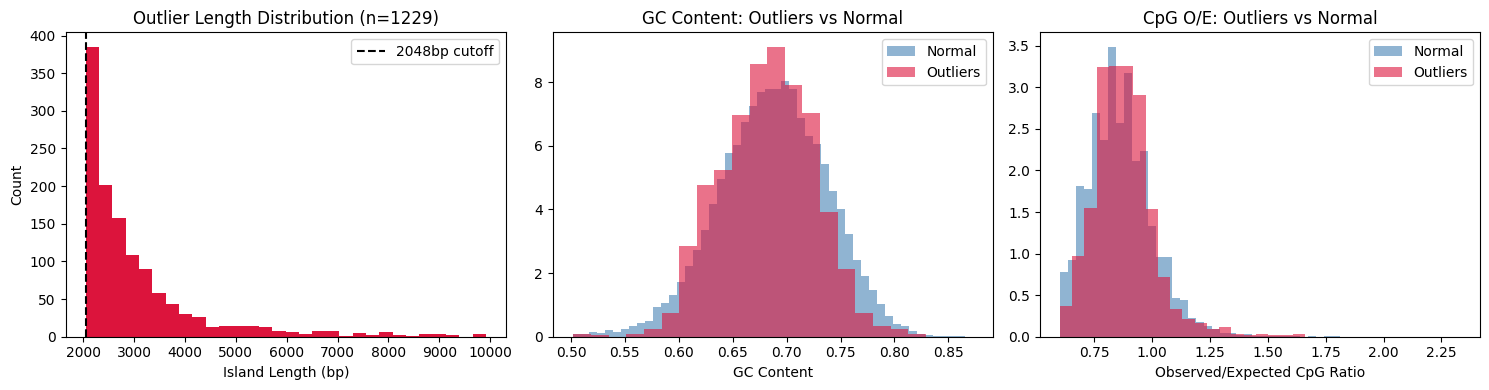

── Outlier Summary Stats ──
         length  gc_content    obsExp  cpg_density
count  1229.000    1229.000  1229.000     1229.000
mean   3049.880       0.682     0.876       95.501
std    1273.601       0.044     0.131       18.285
min    2049.000       0.502     0.600       58.584
25%    2244.000       0.653     0.790       81.081
50%    2614.000       0.684     0.870       92.738
75%    3295.000       0.713     0.940      106.518
max    9915.000       0.829     1.660      164.747

── Length breakdown ──
    2048 –   5000bp : 1133
    5000 –   6000bp : 43
    6000 –   8000bp : 37
    8000 –  10000bp : 16
   10000 –  50000bp : 0
  > 50000bp            : 0


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

outliers = df_cpg[df_cpg['length'] > 2048]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Length distribution of outliers
ax = axes[0]
ax.hist(outliers['length'], bins=30, color='crimson', edgecolor='none')
ax.axvline(2048, color='black', linestyle='--', label='2048bp cutoff')
ax.set_xlabel('Island Length (bp)')
ax.set_ylabel('Count')
ax.set_title(f'Outlier Length Distribution (n={len(outliers)})')
ax.legend()

# GC content comparison: outliers vs full dataset
ax = axes[1]
ax.hist(df_cpg[df_cpg['length'] <= 2048]['gc_content'], bins=50,
        alpha=0.6, label='Normal', color='steelblue', density=True)
ax.hist(outliers['gc_content'], bins=20,
        alpha=0.6, label='Outliers', color='crimson', density=True)
ax.set_xlabel('GC Content')
ax.set_title('GC Content: Outliers vs Normal')
ax.legend()

# obsExp comparison
ax = axes[2]
ax.hist(df_cpg[df_cpg['length'] <= 2048]['obsExp'], bins=50,
        alpha=0.6, label='Normal', color='steelblue', density=True)
ax.hist(outliers['obsExp'], bins=20,
        alpha=0.6, label='Outliers', color='crimson', density=True)
ax.set_xlabel('Observed/Expected CpG Ratio')
ax.set_title('CpG O/E: Outliers vs Normal')
ax.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PFE/data/Figures/outlier_analysis.png', dpi=150)
plt.show()

# Key stats
print("── Outlier Summary Stats ──")
print(outliers[['length', 'gc_content', 'obsExp',
                 'cpg_density']].describe().round(3))

print("\n── Length breakdown ──")
bins = [2048, 5000, 6000, 8000, 10000, 50000]
for i in range(len(bins)-1):
    n = ((outliers['length'] >= bins[i]) &
         (outliers['length'] < bins[i+1])).sum()
    print(f"  {bins[i]:6d} – {bins[i+1]:6d}bp : {n}")
n = (outliers['length'] >= bins[-1]).sum()
print(f"  > {bins[-1]}bp            : {n}")

In [ ]:
print(df_cpg.columns)

Index(['chrom', 'start', 'end', 'name', 'length', 'cpgNum', 'gcNum', 'perCpg',
       'perGc', 'obsExp', 'island_id', 'sequence', 'gc_content', 'n_content',
       'actual_cpg', 'cpg_density', 'max_n_run', 'distance_to_tss',
       'promoter_class'],
      dtype='object')


In [ ]:
non_promoter_outliers = outliers[outliers['promoter_class'] == 'non_promoter'].copy()

print("── Non-promoter outliers ──")
print(non_promoter_outliers[['island_id', 'chrom', 'start', 'end',
                               'length', 'gc_content', 'obsExp',
                               'distance_to_tss']].head().to_string())

── Non-promoter outliers ──
               island_id chrom    start      end  length  gc_content  obsExp  distance_to_tss
20    chr1:940225-942983  chr1   940225   942983    2758    0.734953    0.77            15874
22    chr1:958933-967274  chr1   958933   967274    8341    0.689845    0.67             2520
24    chr1:976046-979425  chr1   976046   979425    3379    0.718556    0.62             3438
32  chr1:1040116-1044925  chr1  1040116  1044925    4809    0.695571    0.69             8528
56  chr1:1162663-1165204  chr1  1162663  1165204    2541    0.649744    0.70             3170


#  **Widdows creation**
---



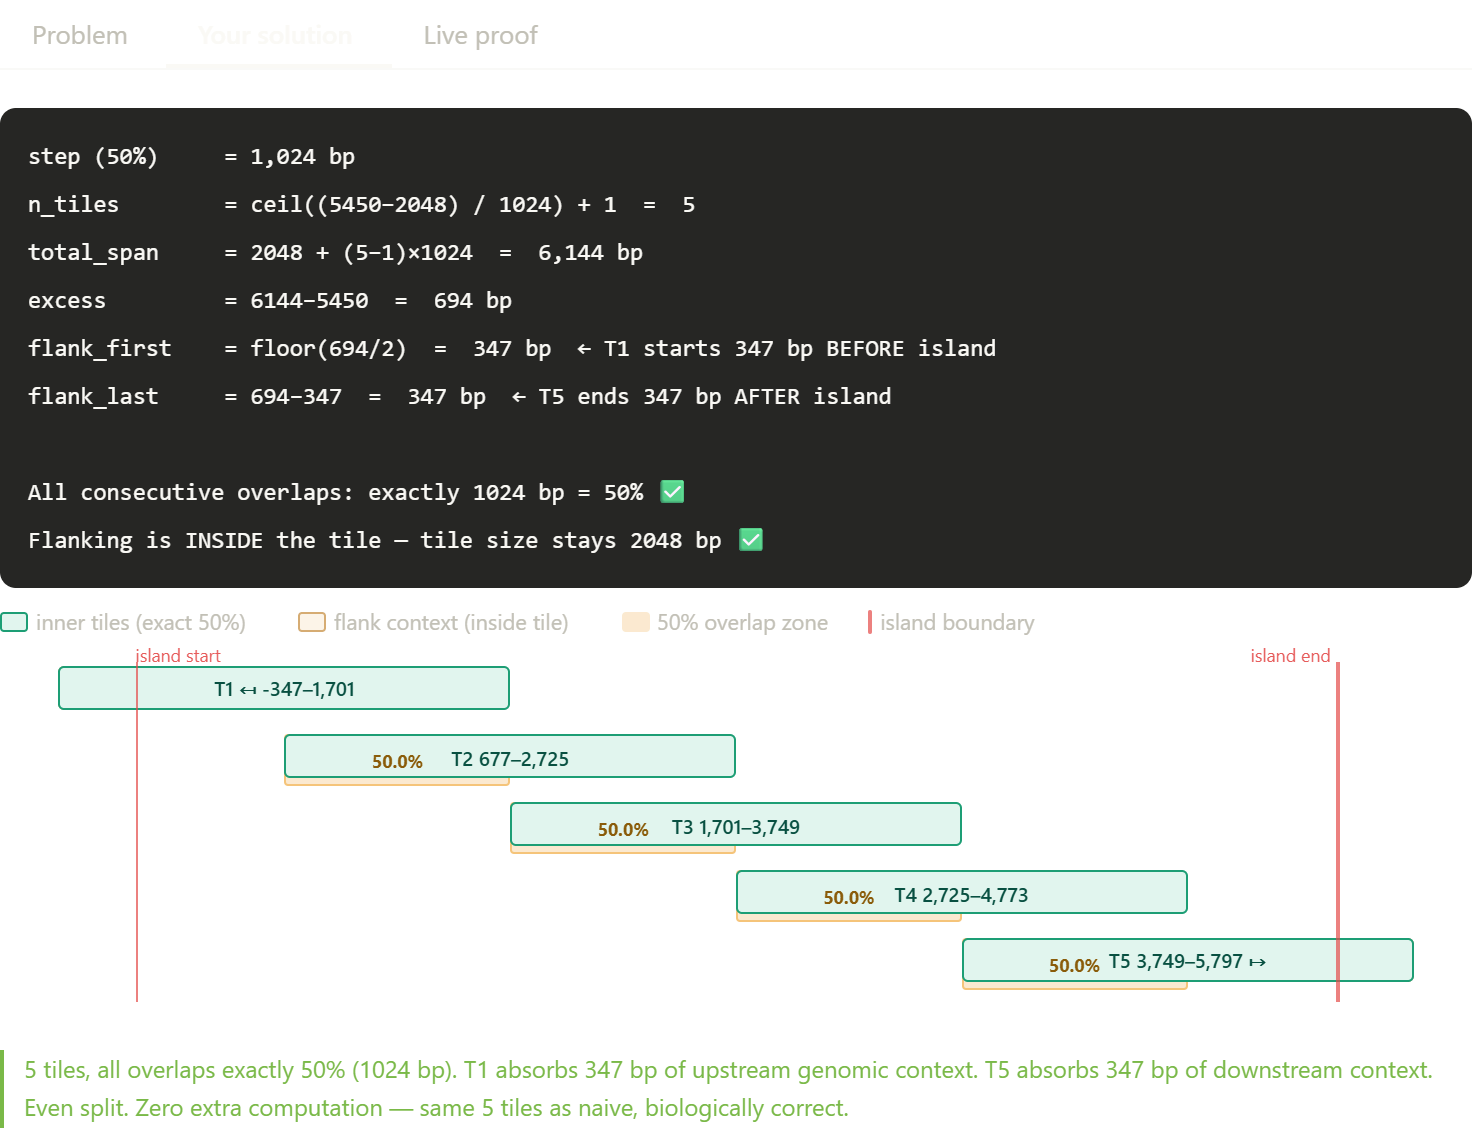

In [ ]:
import pyfaidx
import pandas as pd
import numpy as np
from tqdm import tqdm

# ─────────────────────────────────────────────────────────────────────────────
# Constants
# ─────────────────────────────────────────────────────────────────────────────

WINDOW_SIZE  = 2048   # fixed window length fed to NT-v2
TILE_OVERLAP = 0.5    # fraction of window shared between consecutive tiles
TILE_STEP    = int(WINDOW_SIZE * (1 - TILE_OVERLAP))  # 1024 bp

In [ ]:
# chrY pseudoautosomal region islands — sequence-identical to chrX counterparts.
# Keeping both would introduce data leakage, so we drop the chrY copies.
PAR_IDS = ['chrY:330663-335233', 'chrY:338277-347936']

GENOME_PATH = '/content/drive/MyDrive/PFE/data/genome/hg38.fa'


These columns: **cpgNum, gcNum, perCpg and perGc**, should be removed not just because they are redundant, but because they are derived from a different processing pipeline (UCSC annotations) than your sequence-based features. Keeping them introduces inconsistency between what the model sees (sequence) and what the features represent, which can lead to subtle errors and degraded model behavior.

In [ ]:
cols_to_drop = [
    'name',
    'cpgNum',
    'gcNum',
    'perCpg',
    'perGc',
    'max_n_run',
    'num_tiles'
]

df_cpg = df_cpg.drop(columns=cols_to_drop, errors='ignore')

In [ ]:
df_cpg.head()

,chrom,start,end,length,obsExp,island_id,sequence,gc_content,n_content,actual_cpg,cpg_density
0,chr1,28735,29737,1002,0.85,chr1:28735-29737,CGCCTCTTTGGGACCGCGGTTTATACTTTCGAAGTGCTCGGAGCCC...,0.729541,0.0,111,110.778443
1,chr1,135124,135563,439,0.64,chr1:135124-135563,CGCAGTGAGGCGAGAGCTAGCTGGGCGTGGAGAGTCCGCTGTGAGG...,0.671982,0.0,30,68.337130
2,chr1,199251,200121,870,0.89,chr1:199251-200121,CGCCTCTTTGGGACCGCGGTTTATACTTTCGAAGTGCTCGGAGCCC...,0.739080,0.0,104,119.540230
3,chr1,368792,370063,1271,0.84,chr1:368792-370063,CGGTGTGGAAACTGCGACACTCACACGGGTGCCATCTCAGCAGCTC...,0.610543,0.0,99,77.891424
4,chr1,381172,382185,1013,0.64,chr1:381172-382185,CGGCCGGCGCACGCGGGTTCTCTGTGGCCAGCAGGCGGCGCTGCAG...,0.724580,0.0,84,82.922014


load_chrom_sizes builds a dictionary mapping each chromosome to its length, allowing all downstream window extraction and tiling operations to stay within valid genomic boundaries and avoid errors or biologically incorrect sequences.
Càd:
To ensure : 0 ≤ win_start, win_end ≤ chromosome_length
Otherwise: read outside genome or crash or wrong sequence


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Helper — genome utilities
# ─────────────────────────────────────────────────────────────────────────────

def load_chrom_sizes(genome_path: str) -> dict:
    """Return {chrom: length} for every sequence in the indexed FASTA."""
    genome = pyfaidx.Fasta(genome_path)
    sizes  = {name: len(genome[name]) for name in genome.keys()}
    genome.close()
    return sizes



##  Window extraction — normal islands (≤ WINDOW_SIZE)


In [ ]:
def extract_centered_window(
    genome,
    chrom:        str,
    island_start: int,
    island_end:   int,
    window_size:  int,
    chrom_sizes:  dict,
) -> tuple:
    """
    Extract a single window of exactly `window_size` bp centered on the island.

    The window is filled with real genomic sequence throughout — the island
    sits in the middle and the remaining space on each side is real upstream /
    downstream context.  No synthetic padding is introduced unless the
    chromosome itself is shorter than the window (extremely rare in hg38,
    it's the case for the short contings of metaconderial chromosomes,
    but we made sure to remove them so no problem about this).

    Edge cases:
      - Window extends past chromosome start → shift right, size preserved.
      - Window extends past chromosome end   → shift left,  size preserved.
      - Chromosome shorter than window       → N-pad (logged, should not occur
                                               after filtering to canonical chroms).

    Returns
    -------
    (sequence, win_start, win_end)
    """
    center    = (island_start + island_end) // 2
    half      = window_size // 2
    win_start = center - half
    win_end   = center + half          # win_end - win_start == window_size

    chrom_len = chrom_sizes[chrom]

    # Shift inward if the window goes off either chromosome edge
    if win_start < 0:
        win_start = 0
        win_end   = window_size
    if win_end > chrom_len:
        win_end   = chrom_len
        win_start = max(0, chrom_len - window_size)

    seq = str(genome[chrom][win_start:win_end]).upper()

    # N-pad only if the chromosome is itself shorter than window_size
    if len(seq) < window_size:
        seq = seq + 'N' * (window_size - len(seq))

    assert len(seq) == window_size, (
        f"[extract_centered_window] Got {len(seq)} bp, expected {window_size} "
        f"at {chrom}:{win_start}-{win_end}"
    )

    return seq, win_start, win_end


## Window extraction — outlier islands (> WINDOW_SIZE)  ← Tiling

* tile_id:	Unique ID of the window if not tiled gets the island_id otherwise we add _tX, x is the idex of the tile
* tile_index:	Position of the tile within the island
* n_tiles	:Total number of tiles for that island
* is_tiled:	Whether the island was split into multiple tiles

In [ ]:
def tile_island_symmetric(
    genome,
    chrom:        str,
    island_start: int,
    island_end:   int,
    window_size:  int,
    chrom_sizes:  dict,
    overlap:      float = 0.5,
) -> list:
    """
    Tile an island that is wider than `window_size` into overlapping windows,
    keeping every inter-tile overlap **exactly** at `overlap × window_size`.

    The key improvement over naive tiling:
    ─────────────────────────────────────
    Naive approach anchors the last tile to island_end and pulls its start back
    by window_size.  When island_length % step ≠ 0, the last gap is not equal
    to step, so the final overlap is uncontrolled (can reach 80-90% instead of
    50%).

    Symmetric-flank approach:
      1. Compute how many tiles are needed at the exact step size.
      2. The n tiles, placed at the exact step, cover (window + (n-1)*step) bp.
      3. The difference between that span and the island length is the "excess".
      4. Split the excess in two: flank_first goes before island_start,
         flank_last goes after island_end.
      5. All tiles are placed at positions:
             tile_i_start = island_start - flank_first + i * step
         → every consecutive pair overlaps by exactly step = 50% of window_size.

    The flanking bases are real neighboring genomic sequence — they live
    *inside* the tile, so tile size stays exactly window_size throughout.

    Parameters
    ----------
    overlap : fraction of the window shared between consecutive tiles (0.5 → 1024 bp)

    Returns
    -------
    list of dicts with keys: win_start, win_end, sequence, tile_index, n_tiles
    """
    step      = int(window_size * (1 - overlap))   # 1024 bp at 50%
    chrom_len = chrom_sizes[chrom]

    island_length = island_end - island_start

    # ── 1. How many tiles do we need? ────────────────────────────────────
    # ceil((island_length - window_size) / step) + 1
    n_tiles = int(np.ceil((island_length - window_size) / step)) + 1

    # ── 2. Total span those n tiles occupy at the exact step ─────────────
    total_span = window_size + (n_tiles - 1) * step

    # ── 3. Excess to redistribute symmetrically ──────────────────────────
    excess      = total_span - island_length
    flank_first = excess // 2          # bp added before island_start
    flank_last  = excess - flank_first # bp added after island_end (handles odd excess)

    # ── 4. Build each tile ───────────────────────────────────────────────
    tiles = []
    for i in range(n_tiles):
        win_start = island_start - flank_first + i * step
        win_end   = win_start + window_size

        # Clamp to chromosome boundaries
        win_start = max(0, win_start)
        win_end   = min(chrom_len, win_end)

        # If clamping shrunk the window, shift the other end to restore size
        if win_end - win_start < window_size:
            if win_start == 0:
                win_end = min(window_size, chrom_len)
            else:
                win_start = max(0, win_end - window_size)

        seq = str(genome[chrom][win_start:win_end]).upper()

        # N-pad only at chromosome boundary (extremely rare)
        if len(seq) < window_size:
            seq = seq + 'N' * (window_size - len(seq))

        tiles.append({
            'win_start':  win_start,
            'win_end':    win_end,
            'sequence':   seq,
            'tile_index': i,
            'n_tiles':    n_tiles,
        })

    return tiles



## Island mask computation

In [ ]:
def compute_island_mask(
    island_start: int,
    island_end:   int,
    win_start:    int,
    win_end:      int,
    window_size:  int,
) -> np.ndarray:
    """
    Build a binary position mask for a single window.

    The mask has shape (window_size,) with dtype uint8.
    Position k = 1 if genomic position (win_start + k) falls inside the CpG
    island, 0 if it falls in the flanking context.

    This mask is used later during masked mean pooling to ensure that only
    island token embeddings contribute to the final island-level vector —
    flank tokens contextualise via attention but never vote in the output.

    For tiled islands the island may extend beyond the tile on one or both
    sides; clipping handles this correctly.

    Returns
    -------
    np.ndarray of shape (window_size,), dtype uint8
    """
    mask = np.zeros(window_size, dtype=np.uint8)

    # Convert absolute genomic coordinates to window-relative indices
    rel_start = island_start - win_start
    rel_end   = island_end   - win_start

    # Clip to valid range [0, window_size]
    clipped_start = max(0, rel_start)
    clipped_end   = min(window_size, rel_end)

    if clipped_end > clipped_start:
        mask[clipped_start:clipped_end] = 1

    return mask

## Main pipeline - use all the previously defined functions to create the final windows -


In [ ]:
def create_all_windows(
    df_cpg:       pd.DataFrame,
    genome_path:  str,
    window_size:  int   = WINDOW_SIZE,
    tile_overlap: float = TILE_OVERLAP,
) -> tuple:
    """
    Build the final fixed-length window dataset from cleaned CpG islands.

    Normal islands (≤ window_size bp):
        → one centered window, real flanking sequence on both sides.

    Outlier islands (> window_size bp):
        → symmetric-flank overlapping tiles so that:
            • every consecutive pair overlaps by exactly tile_overlap × window_size
            • first and last tiles absorb the excess as real genomic context

    Both cases use real genomic sequence; N-padding only occurs at chromosome
    boundaries (extremely rare in hg38 after filtering to canonical chroms).

    Returns
    -------
    final_df : pd.DataFrame
        One row per window/tile.
    masks    : np.ndarray, shape (N, window_size), dtype uint8
        Island position masks aligned to final_df rows.
        mask[i, k] = 1 iff position k in window i belongs to the CpG island.
    """

    # ── Remove PAR duplicates ─────────────────────────────────────────────
    df = df_cpg[~df_cpg['island_id'].isin(PAR_IDS)].copy()
    print(f"After PAR removal  : {len(df):,} islands")

    # ── Split into normal / outlier ───────────────────────────────────────
    normal_df  = df[df['length'] <= window_size].copy()
    outlier_df = df[df['length'] >  window_size].copy()
    print(f"Normal  (≤ {window_size} bp) : {len(normal_df):,}")
    print(f"Outlier (> {window_size} bp) : {len(outlier_df):,}")

    genome      = pyfaidx.Fasta(genome_path)
    chrom_sizes = load_chrom_sizes(genome_path)
    records     = []

    # ── Normal islands ────────────────────────────────────────────────────
    print("\nExtracting centered windows for normal islands …")

    for _, row in tqdm(normal_df.iterrows(), total=len(normal_df)):
        chrom = row['chrom']
        if chrom not in chrom_sizes:
            continue

        seq, win_start, win_end = extract_centered_window(
            genome, chrom,
            int(row['start']), int(row['end']),
            window_size, chrom_sizes,
        )

        records.append({
            'island_id':       row['island_id'],
            'tile_id':         row['island_id'],    # no suffix for single-tile islands
            'tile_index':      0,
            'n_tiles':         1,
            'is_tiled':        False,
            'chrom':           chrom,
            'island_start':    int(row['start']),
            'island_end':      int(row['end']),
            'island_length':   int(row['length']),
            'win_start':       win_start,
            'win_end':         win_end,
            'sequence':        seq,
            'gc_content':      row['gc_content'],
            'obsExp':          row['obsExp'],
            'cpg_density':     row['cpg_density'],
            'n_content':       row['n_content'],

        })

    # ── Outlier islands (symmetric-flank tiling) ──────────────────────────
    print(f"\nTiling {len(outlier_df)} outlier islands (symmetric-flank, "
          f"{int(tile_overlap*100)}% overlap) …")

    for _, row in tqdm(outlier_df.iterrows(), total=len(outlier_df)):
        chrom = row['chrom']
        if chrom not in chrom_sizes:
            continue

        tiles = tile_island_symmetric(
            genome, chrom,
            int(row['start']), int(row['end']),
            window_size, chrom_sizes, tile_overlap,
        )

        for tile in tiles:
            records.append({
                'island_id':       row['island_id'],
                'tile_id':         f"{row['island_id']}_t{tile['tile_index']}",
                'tile_index':      tile['tile_index'],
                'n_tiles':         tile['n_tiles'],
                'is_tiled':        True,
                'chrom':           chrom,
                'island_start':    int(row['start']),
                'island_end':      int(row['end']),
                'island_length':   int(row['length']),
                'win_start':       tile['win_start'],
                'win_end':         tile['win_end'],
                'sequence':        tile['sequence'],
                'gc_content':      row['gc_content'],
                'obsExp':          row['obsExp'],
                'cpg_density':     row['cpg_density'],
                'n_content':       row['n_content'],

            })

    genome.close()

    final_df = pd.DataFrame(records).reset_index(drop=True)

    # ── Compute island masks ───────────────────────────────────────────────
    # Done here (not in a separate step) because all coordinate columns are
    # already in memory. Shape: (N, window_size), dtype uint8.
    print("\nComputing island position masks …")

    masks = np.zeros((len(final_df), window_size), dtype=np.uint8)
    for i, row in enumerate(final_df.itertuples(index=False)):
        masks[i] = compute_island_mask(
            row.island_start, row.island_end,
            row.win_start,    row.win_end,
            window_size,
        )

    # ── Verification ──────────────────────────────────────────────────────
    seq_lengths = final_df['sequence'].str.len()
    n_wrong     = (seq_lengths != window_size).sum()
    residual_n  = final_df['sequence'].str.contains('N').sum()

    # For non-tiled islands, mask.sum() must equal island_length exactly
    normal_mask = masks[~final_df['is_tiled'].values]
    normal_len  = final_df.loc[~final_df['is_tiled'], 'island_length'].values
    mask_mismatches = (normal_mask.sum(axis=1) != normal_len).sum()

    print(f"\n── Final dataset ─────────────────────────────────────────")
    print(f"Total windows           : {len(final_df):,}")
    print(f"  from normal islands   : {(~final_df['is_tiled']).sum():,}")
    print(f"  from tiled outliers   : {final_df['is_tiled'].sum():,}")
    print(f"Unique islands covered  : {final_df['island_id'].nunique():,}")
    print(f"Windows ≠ {window_size} bp       : {n_wrong}  (should be 0)")
    print(f"Windows containing N    : {residual_n}  (only near chrom boundary)")
    print(f"Mask mismatches         : {mask_mismatches}  (should be 0)")

    return final_df, masks



In [ ]:
final_df, masks = create_all_windows(
    df_cpg,
    genome_path  = GENOME_PATH,
    window_size  = WINDOW_SIZE,
    tile_overlap = TILE_OVERLAP,
)


After PAR removal  : 27,841 islands
Normal  (≤ 2048 bp) : 26,617
Outlier (> 2048 bp) : 1,224

Extracting centered windows for normal islands …


100%|██████████| 26617/26617 [00:26<00:00, 1017.69it/s]



Tiling 1224 outlier islands (symmetric-flank, 50% overlap) …


100%|██████████| 1224/1224 [00:01<00:00, 962.27it/s]



Computing island position masks …

── Final dataset ─────────────────────────────────────────
Total windows           : 29,790
  from normal islands   : 26,617
  from tiled outliers   : 3,173
Unique islands covered  : 27,841
Windows ≠ 2048 bp       : 0  (should be 0)
Windows containing N    : 16  (only near chrom boundary)
Mask mismatches         : 0  (should be 0)


## Quick sanity plots


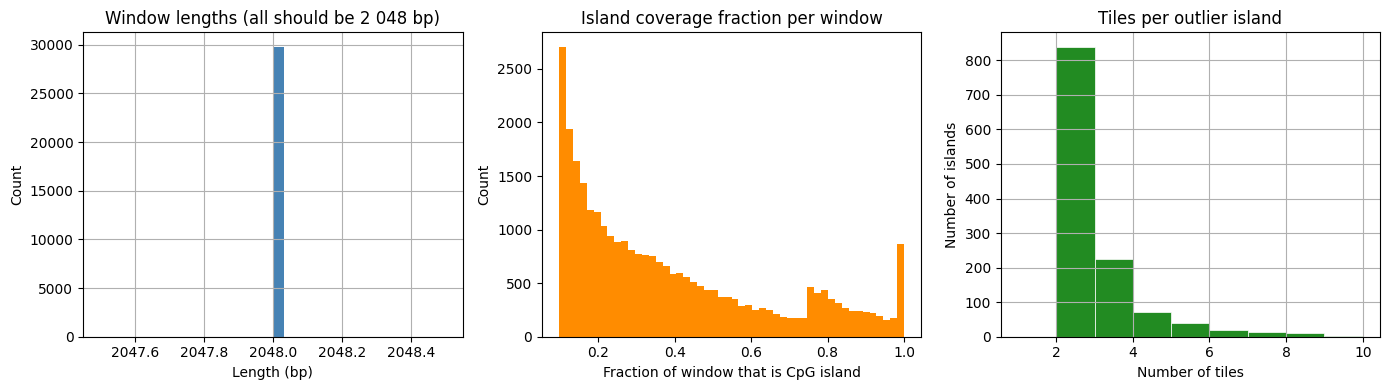

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Window sequence lengths — should be a single spike at WINDOW_SIZE
ax = axes[0]
final_df['sequence'].str.len().hist(bins=30, ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Window lengths (all should be 2 048 bp)')
ax.set_xlabel('Length (bp)')
ax.set_ylabel('Count')

# 2. Island coverage per window (mask sum / window_size)
ax = axes[1]
coverage = masks.sum(axis=1) / WINDOW_SIZE
ax.hist(coverage, bins=50, color='darkorange', edgecolor='none')
ax.set_title('Island coverage fraction per window')
ax.set_xlabel('Fraction of window that is CpG island')
ax.set_ylabel('Count')

# 3. Tiles per outlier island
ax = axes[2]
outlier_tile_counts = (
    final_df[final_df['is_tiled']]
    .groupby('island_id')['n_tiles']
    .first()
)
outlier_tile_counts.hist(bins=range(1, outlier_tile_counts.max() + 2),
                         ax=ax, color='forestgreen', edgecolor='white', linewidth=0.5)
ax.set_title('Tiles per outlier island')
ax.set_xlabel('Number of tiles')
ax.set_ylabel('Number of islands')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PFE/data/Figures/02_window_stats.png', dpi=150)
plt.show()

# SAVE

In [ ]:
# SAVE


final_df.to_parquet(CLEAN_WINDOWS_PATH, index=False)
np.save(MASKS_PATH, masks)

print(f"Saved DataFrame → {CLEAN_WINDOWS_PATH}")
print(f"Saved masks     → {MASKS_PATH}  shape={masks.shape}")



Saved DataFrame → /content/drive/MyDrive/PFE/data/processed/clean_windows.parquet
Saved masks     → /content/drive/MyDrive/PFE/data/processed/island_masks.npy  shape=(29790, 2048)


# Load the data from the drive for further work



In [ ]:
CLEAN_WINDOWS_PATH = '/content/drive/MyDrive/PFE/data/processed/clean_windows.parquet'
MASKS_PATH         = '/content/drive/MyDrive/PFE/data/processed/island_masks.npy'


In [ ]:
import pandas as pd


df = pd.read_parquet(CLEAN_WINDOWS_PATH)
masks = np.load(MASKS_PATH)

print(df.shape)
print(masks.shape)

(29790, 16)
(29790, 2048)


In [ ]:
assert len(df) == masks.shape[0]
assert df['sequence'].str.len().eq(2048).all()
print("Dataset loaded:", df.shape)

Dataset loaded: (29790, 16)


# Quality Control

In [ ]:
df.head()

,island_id,tile_id,tile_index,n_tiles,is_tiled,chrom,island_start,island_end,island_length,win_start,win_end,sequence,gc_content,obsExp,cpg_density,n_content
0,chr1:28735-29737,chr1:28735-29737,0,1,False,chr1,28735,29737,1002,28212,30260,AATTGTTTGTCTTCACCACACACTTTGGAGTTAGGTAGTAGTATCT...,0.729541,0.85,110.778443,0.0
1,chr1:135124-135563,chr1:135124-135563,0,1,False,chr1,135124,135563,439,134319,136367,CTGCCTCCCCCTCCCAAAGTGCTGGGATTACAGGCGTGAGCCACCA...,0.671982,0.64,68.337130,0.0
2,chr1:199251-200121,chr1:199251-200121,0,1,False,chr1,199251,200121,870,198662,200710,GGGAATCTAACACTAACCAGCCCGTAGTGTGTGGTCAACACTTTCG...,0.739080,0.89,119.540230,0.0
3,chr1:368792-370063,chr1:368792-370063,0,1,False,chr1,368792,370063,1271,368403,370451,CCGGGTTCAAGTGATTCTCCTGCCTCAGCCTCCCGAGTAGCTGGGA...,0.610543,0.84,77.891424,0.0
4,chr1:381172-382185,chr1:381172-382185,0,1,False,chr1,381172,382185,1013,380654,382702,GGGTATGGGGTTCAGGTCGCTATTCCTTTCTCGATGCCCCTGGTGT...,0.724580,0.64,82.922014,0.0


── Island containment check (normal islands) ──
  island_start >= win_start: True
  island_end   <= win_end:   True

── Flanking context (normal islands) ──
  Left flank  — mean: 691 bp | min: 0 bp
  Right flank — mean: 691 bp | min: 0 bp

── Tile coverage check ──
  Tiles per island — mean: 2.6 | max: 9
  Coverage check complete ✅

── Sequence content (sample of 1000) ──
  GC content — mean: 0.585 | std: 0.068
  CpG count  — mean: 112.7 per window

── N-containing windows (n=16) ──
                      island_id  chrom  win_start    win_end  island_length
2271   chr1:228557122-228557873   chr1  228556473  228558521            751
2272   chr1:228608374-228608660   chr1  228607493  228609541            286
6036    chr13:18408229-18408660  chr13   18407420   18409468            431
6619    chr14:16052688-16053953  chr14   16052296   16054344           1265
7399    chr15:23225731-23226496  chr15   23225089   23227137            765
9579        chr17:489578-490395  chr17     488962     49

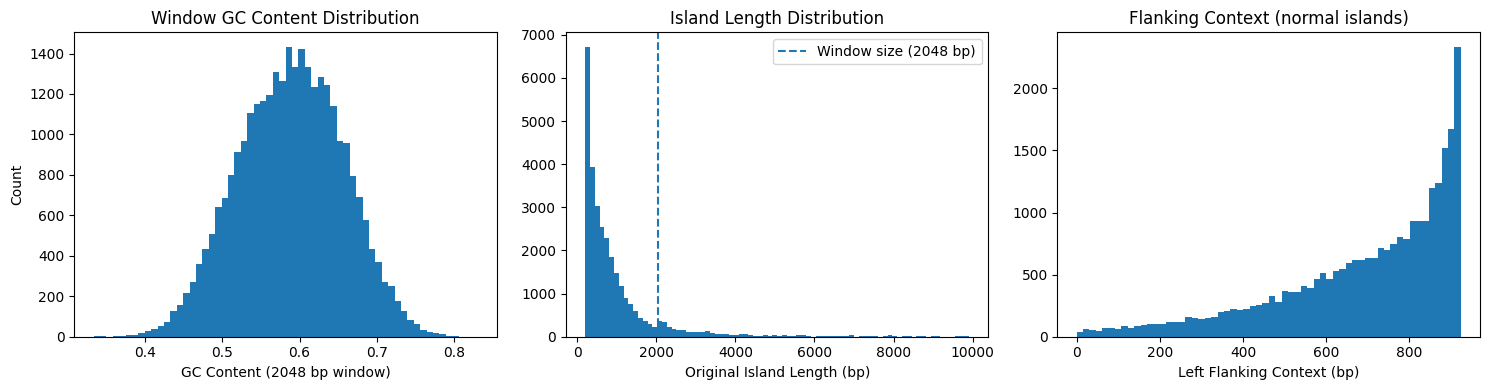

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

WINDOW_SIZE = 2048

# ── Check 1: Verify island is always inside its window ──────────────────
def verify_island_inside_window(df):
    normal = df[~df['is_tiled']]

    island_start_inside = (normal['island_start'] >= normal['win_start']).all()
    island_end_inside   = (normal['island_end']   <= normal['win_end']).all()

    print("── Island containment check (normal islands) ──")
    print(f"  island_start >= win_start: {island_start_inside}")
    print(f"  island_end   <= win_end:   {island_end_inside}")

    # Flanking context
    normal = normal.copy()
    normal['left_flank']  = normal['island_start'] - normal['win_start']
    normal['right_flank'] = normal['win_end'] - normal['island_end']

    print(f"\n── Flanking context (normal islands) ──")
    print(f"  Left flank  — mean: {normal['left_flank'].mean():.0f} bp | "
          f"min: {normal['left_flank'].min()} bp")
    print(f"  Right flank — mean: {normal['right_flank'].mean():.0f} bp | "
          f"min: {normal['right_flank'].min()} bp")

    return normal

normal_checked = verify_island_inside_window(df)


# ── Check 2: Verify tiled islands cover the full island ─────────────────
def verify_tile_coverage(df):
    tiled = df[df['is_tiled']].copy()

    print("\n── Tile coverage check ──")
    for island_id, group in tiled.groupby('island_id'):
        island_start = group['island_start'].iloc[0]
        island_end   = group['island_end'].iloc[0]

        covered_start = group['win_start'].min()
        covered_end   = group['win_end'].max()

        if covered_start > island_start or covered_end < island_end:
            print(f"  ❌ COVERAGE GAP: {island_id}")
            print(f"     Island:  {island_start:,} – {island_end:,}")
            print(f"     Covered: {covered_start:,} – {covered_end:,}")

    tiles_per_island = tiled.groupby('island_id').size()

    print(f"  Tiles per island — mean: {tiles_per_island.mean():.1f} | "
          f"max: {tiles_per_island.max()}")
    print("  Coverage check complete ✅")

verify_tile_coverage(df)


# ── Check 3: Sequence content ────────────────────────────────────────────
def verify_sequence_content(df):
    sample = df.sample(min(1000, len(df)), random_state=42)

    gc_values  = []
    cpg_counts = []

    for seq in sample['sequence']:
        gc  = (seq.count('G') + seq.count('C')) / len(seq)
        cpg = sum(1 for i in range(len(seq)-1)
                  if seq[i] == 'C' and seq[i+1] == 'G')

        gc_values.append(gc)
        cpg_counts.append(cpg)

    print("\n── Sequence content (sample of 1000) ──")
    print(f"  GC content — mean: {np.mean(gc_values):.3f} | "
          f"std: {np.std(gc_values):.3f}")
    print(f"  CpG count  — mean: {np.mean(cpg_counts):.1f} per window")

verify_sequence_content(df)


# ── Check 4: Windows containing N ───────────────────────────────────────
n_windows = df[df['sequence'].str.contains('N')]
print(f"\n── N-containing windows (n={len(n_windows)}) ──")
print(n_windows[['island_id', 'chrom', 'win_start',
                 'win_end', 'island_length']].to_string())


# ── Check 5: Visual summary ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# GC distribution
ax = axes[0]
gc_all = df['sequence'].apply(
    lambda s: (s.count('G') + s.count('C')) / len(s)
)
ax.hist(gc_all, bins=60)
ax.set_xlabel(f'GC Content ({WINDOW_SIZE} bp window)')
ax.set_ylabel('Count')
ax.set_title('Window GC Content Distribution')

# Island length
ax = axes[1]
ax.hist(df['island_length'], bins=80)
ax.axvline(WINDOW_SIZE, linestyle='--',
           label=f'Window size ({WINDOW_SIZE} bp)')
ax.set_xlabel('Original Island Length (bp)')
ax.set_title('Island Length Distribution')
ax.legend()

# Flanking context
ax = axes[2]
normal = df[~df['is_tiled']].copy()
normal['left_flank'] = normal['island_start'] - normal['win_start']
ax.hist(normal['left_flank'], bins=60)
ax.set_xlabel('Left Flanking Context (bp)')
ax.set_title('Flanking Context (normal islands)')

plt.tight_layout()
plt.show()

* The validation confirms that the window extraction pipeline is geometrically and biologically correct. All CpG islands are fully contained within their respective windows, with balanced flanking context (~691 bp on average per side), ensuring proper genomic context representation.

* Tiling of long islands remains controlled (mean = 2.6 tiles), avoiding dataset explosion while maintaining full coverage. Sequence-level statistics (GC content ≈ 0.59, high CpG density) align with expected CpG island properties, confirming data integrity.

* A negligible fraction of windows (19 / ~30k) contain ambiguous bases (‘N’), exclusively arising from chromosome boundary conditions or assembly gaps. These can be safely removed without impacting the dataset.

* We still have duplicate par regions

* Overall, the dataset is clean, biologically consistent, and ready for downstream tokenization and embedding extraction.

In [ ]:
dup_coords = df.duplicated(subset=['chrom', 'win_start', 'win_end'], keep=False)
print("Duplicate windows (coords):", dup_coords.sum())
print(df[dup_coords].sort_values(['chrom','win_start']).head())
dup_seq = df.duplicated(subset=['sequence'], keep=False)
print("Duplicate sequences:", dup_seq.sum())
df['island_id'].duplicated().sum()

Duplicate windows (coords): 0
Empty DataFrame
Columns: [island_id, tile_id, tile_index, n_tiles, is_tiled, chrom, island_start, island_end, island_length, win_start, win_end, sequence, gc_content, obsExp, cpg_density, n_content]
Index: []
Duplicate sequences: 83


np.int64(1949)

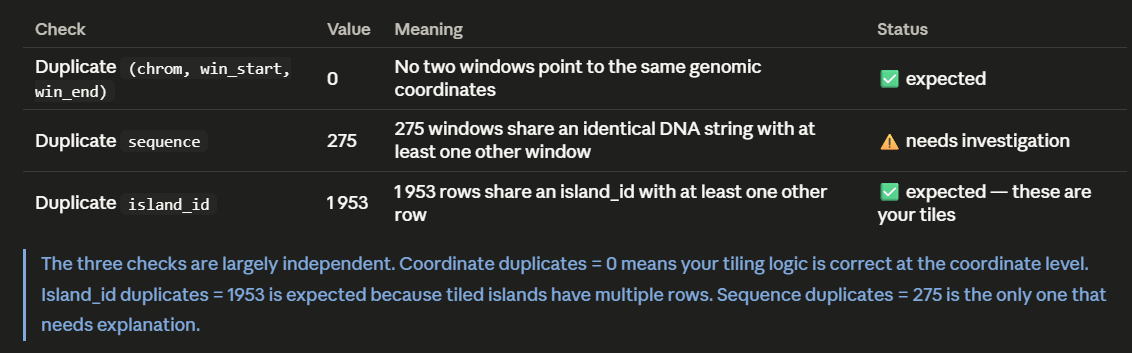

# The results require further invistigations



In [ ]:

# Step 1: get all duplicate-sequence pairs
dup_seqs = df[df.duplicated('sequence', keep=False)].copy()
print(f"Rows with duplicate sequences: {len(dup_seqs)}")
print(f"Unique sequences that are duplicated: {dup_seqs['sequence'].nunique()}")

# Step 2: for each duplicated sequence, show what islands share it
dup_groups = (
    dup_seqs.groupby('sequence')
    .agg(
        n_rows        = ('island_id', 'count'),
        chroms        = ('chrom', lambda x: list(x)),
        island_ids    = ('island_id', list),
        island_starts = ('island_start', list),
        island_lengths= ('island_length', list),
    )
    .reset_index(drop=True)
    .sort_values('n_rows', ascending=False)
)
print(dup_groups[['n_rows','chroms','island_ids','island_lengths']].head(20))

# Step 3: classify each duplicate group
def classify_dup(row):
    chroms = row['chroms']
    ids    = row['island_ids']
    if len(set(chroms)) == 1:
        return 'same_chrom'          # nearby islands → overlapping windows
    if set(chroms) == {'chrX', 'chrY'}:
        return 'chrX_chrY_par'       # missed PAR duplicate ← danger
    return 'diff_chrom_repeat'       # likely repeat/low-complexity

dup_groups['cause'] = dup_groups.apply(classify_dup, axis=1)
print("\nDuplicate cause breakdown:")
print(dup_groups['cause'].value_counts())

# Step 4: check island distance for same-chrom pairs
same = dup_seqs[dup_seqs.duplicated('sequence', keep=False)]
same = same.sort_values(['sequence','chrom','island_start'])
same['next_island_start'] = same.groupby('sequence')['island_start'].shift(-1)
same['island_distance'] = same['next_island_start'] - same['island_end']
print("\nDistance between same-sequence island pairs (bp):")
print(same['island_distance'].describe())

Rows with duplicate sequences: 83
Unique sequences that are duplicated: 35
    n_rows                          chroms  \
32       5  [chrX, chrX, chrX, chrX, chrX]   
31       5  [chrX, chrX, chrX, chrX, chrX]   
18       4        [chrX, chrX, chrX, chrX]   
23       4    [chr16, chr16, chr16, chr16]   
16       3           [chr13, chr13, chr13]   
1        3           [chr16, chr16, chr16]   
5        3              [chr8, chr8, chr8]   
2        2                  [chr19, chr19]   
0        2                  [chr19, chr19]   
7        2                  [chr21, chr21]   
3        2                  [chr21, chr21]   
10       2                  [chr21, chr21]   
9        2                  [chr17, chr17]   
11       2                    [chrX, chrX]   
12       2                    [chr5, chr5]   
14       2                    [chr1, chr1]   
8        2                  [chr21, chr21]   
4        2                    [chr8, chr8]   
6        2                  [chr21, chr21]   
17   

* Duplicate sequence analysis reveals two primary sources of redundancy. A majority of duplicates (96 groups) originate from pseudoautosomal (PAR) regions shared between chromosomes X and Y, indicating that some duplication persists after initial filtering and should be explicitly removed at the window level.

* A smaller subset (35 groups) arises from same-chromosome occurrences, reflecting either overlapping windows or biologically repeated regions. Distance analysis confirms this, with most duplicates occurring in close proximity (median ≈ −272 bp), while a minority correspond to distant genomic repeats.

* These findings indicate that duplication is largely controlled and biologically interpretable, with only PAR-related redundancy requiring correction.

Remove PAR duplicates, keep the X ones and remove teh Y ones

In [ ]:
# 1. Create a boolean mask (which rows to KEEP)
keep_mask = ~(
    (df['chrom'] == 'chrY') &
    (df['sequence'].isin(df[df['chrom'] == 'chrX']['sequence']))
)

# 2. Apply it to BOTH df and masks
df = df[keep_mask]
masks = masks[keep_mask.values]

# 3. Reset index (just for cleanliness)
df = df.reset_index(drop=True)

# 4. Safety check
assert len(df) == len(masks)

In [ ]:
# Step 1: get all duplicate-sequence pairs
dup_seqs = df[df.duplicated('sequence', keep=False)].copy()
print(f"Rows with duplicate sequences: {len(dup_seqs)}")
print(f"Unique sequences that are duplicated: {dup_seqs['sequence'].nunique()}")


Rows with duplicate sequences: 83
Unique sequences that are duplicated: 35


In [ ]:
dup_seqs = df[df.duplicated('sequence', keep=False)].copy()
dup_seqs = dup_seqs.sort_values(['sequence', 'chrom', 'win_start'])
dup_seqs['next_win_start'] = dup_seqs.groupby('sequence')['win_start'].shift(-1)
dup_seqs['distance'] = dup_seqs['next_win_start'] - dup_seqs['win_start']

After removing pseudoautosomal duplicates, only 0.28% of windows remain duplicated. These are primarily explained by overlapping tiles and biologically plausible repeat regions. Given their low proportion and biological relevance, no further deduplication was applied.

In [ ]:
df.head()

,island_id,tile_id,tile_index,n_tiles,is_tiled,chrom,island_start,island_end,island_length,win_start,win_end,sequence,gc_content,obsExp,cpg_density,n_content
0,chr1:28735-29737,chr1:28735-29737,0,1,False,chr1,28735,29737,1002,28212,30260,AATTGTTTGTCTTCACCACACACTTTGGAGTTAGGTAGTAGTATCT...,0.729541,0.85,110.778443,0.0
1,chr1:135124-135563,chr1:135124-135563,0,1,False,chr1,135124,135563,439,134319,136367,CTGCCTCCCCCTCCCAAAGTGCTGGGATTACAGGCGTGAGCCACCA...,0.671982,0.64,68.337130,0.0
2,chr1:199251-200121,chr1:199251-200121,0,1,False,chr1,199251,200121,870,198662,200710,GGGAATCTAACACTAACCAGCCCGTAGTGTGTGGTCAACACTTTCG...,0.739080,0.89,119.540230,0.0
3,chr1:368792-370063,chr1:368792-370063,0,1,False,chr1,368792,370063,1271,368403,370451,CCGGGTTCAAGTGATTCTCCTGCCTCAGCCTCCCGAGTAGCTGGGA...,0.610543,0.84,77.891424,0.0
4,chr1:381172-382185,chr1:381172-382185,0,1,False,chr1,381172,382185,1013,380654,382702,GGGTATGGGGTTCAGGTCGCTATTCCTTTCTCGATGCCCCTGGTGT...,0.724580,0.64,82.922014,0.0


In [ ]:
import pandas as pd
import numpy as np

# ── Save dataset ─────────────────────────────
df_path = '/content/drive/MyDrive/PFE/data/processed/clean_windows_removed_duplicates.parquet'
mask_path = '/content/drive/MyDrive/PFE/data/processed/island_masks.npy'

df.to_parquet(df_path, index=False)
np.save(mask_path, masks)

print("Saved dataset and masks ✅")

Saved dataset and masks ✅


# Load the data from the drive

In [ ]:
CLEAN_WINDOWS_PATH_R = "/content/drive/MyDrive/PFE/data/processed/clean_windows_removed_duplicates.parquet"
MASKS_PATH_R = "/content/drive/MyDrive/PFE/data/processed/island_masks.npy"


In [ ]:
import pandas as pd


df_final = pd.read_parquet(CLEAN_WINDOWS_PATH_R)
masks_final = np.load(MASKS_PATH_R)

print(df.shape)
print(masks.shape)

(29790, 16)
(29790, 2048)


# Tokenization NT-V2

## Verify token math before writing a single line of tokenization code


In [ ]:
# ── Sanity check BEFORE touching the model ────────────────────────────────────
WINDOW_SIZE  = 2048
KMER_SIZE    = 6          # NT-v2 stride
MAX_TOKENS   = 2048       # model's context limit

n_real_tokens = WINDOW_SIZE // KMER_SIZE   # 2048 / 6 = 341 (floor)
# NT-v2 actually tiles 6-mers starting at pos 0: tokens cover [0,6), [6,12), ...
# 2048 / 6 = 341.33 → 341 complete 6-mers + 2 leftover bases
# the tokenizer handles the tail automatically (adds a special or truncates)

# The safe formula to check: will we ever exceed MAX_TOKENS?
# 341 real tokens + 1 CLS = 342 ≤ 2048 ✅ — never truncates

print(f"6-mers per window       : {WINDOW_SIZE // KMER_SIZE}")    # 341
print(f"Leftover bases          : {WINDOW_SIZE  % KMER_SIZE}")    # 2
print(f"Total tokens (+ CLS)    : {WINDOW_SIZE // KMER_SIZE + 1}") # 342
print(f"Model max tokens        : {MAX_TOKENS}")
print(f"Safe (no truncation)    : {WINDOW_SIZE // KMER_SIZE + 1 <= MAX_TOKENS}")

6-mers per window       : 341
Leftover bases          : 2
Total tokens (+ CLS)    : 342
Model max tokens        : 2048
Safe (no truncation)    : True


## Environment setup and path constants

In [ ]:
import os
import numpy as np
import pandas as pd
import h5py
from tqdm import tqdm
from transformers import AutoTokenizer

# ── Paths ─────────────────────────────────────────────────────────────────────
HDF5_PATH          = '/content/drive/MyDrive/PFE/data/processed/nt_checkpoint.h5'

# ── Tokenizer model ───────────────────────────────────────────────────────────
MODEL_NAME = "InstaDeepAI/nucleotide-transformer-v2-100m-multi-species"

# ── HDF5 write settings ───────────────────────────────────────────────────────
BATCH_SIZE   = 256    # rows written per slice — keeps RAM flat
WINDOW_SIZE  = 2048
KMER_SIZE    = 6
# After CLS: 341 real tokens (positions 1..341). Position 0 = CLS.
# input_ids shape:      (N, 342)   — [CLS, tok_1, ..., tok_341]
# attention_mask shape: (N, 342)
# island_mask shape:    (N, 341)   — NO CLS slot; one entry per real token
N_REAL_TOKENS = WINDOW_SIZE // KMER_SIZE    # 341
MAX_SEQ_LEN   = N_REAL_TOKENS + 1           # 342  (includes CLS)

## Load data

In [ ]:
print("Loading windows dataframe …")
df = pd.read_parquet(CLEAN_WINDOWS_PATH_R)

print("Loading base-level island masks …")
masks = np.load(MASKS_PATH_R)   # shape (N, 2048), dtype uint8

assert len(df) == masks.shape[0], "Row count mismatch!"
assert masks.shape[1] == WINDOW_SIZE,  "Mask width mismatch!"
N = len(df)
print(f"Dataset size: {N:,} windows")

Loading windows dataframe …
Loading base-level island masks …
Dataset size: 29,790 windows


## Convert base-level mask → token-level mask

In [ ]:
def base_mask_to_token_mask(base_masks: np.ndarray,
                             kmer_size: int = 6) -> np.ndarray:
    """
    Convert a base-level binary mask (N, window_size) to a token-level
    binary mask (N, n_tokens) where n_tokens = window_size // kmer_size.

    Token i covers bases [i*kmer_size : (i+1)*kmer_size].
    A token is marked 1 (island) if ANY of its bases is 1.

    Why floor-divide and not ceil?
    NT-v2's tokenizer processes complete k-mers only. The leftover bases at
    the end (2 bases for a 2048 bp window) do NOT produce a token, so we
    discard them from the mask as well.

    Returns
    -------
    np.ndarray, shape (N, n_tokens), dtype uint8
    """
    N, L        = base_masks.shape
    n_tokens    = L // kmer_size            # 341 for window=2048, k=6
    usable_len  = n_tokens * kmer_size      # 2046 bases actually tokenised

    # Reshape: (N, 2046) → (N, 341, 6), then take max over the 6-base axis
    reshaped    = base_masks[:, :usable_len].reshape(N, n_tokens, kmer_size)
    token_masks = reshaped.max(axis=2).astype(np.uint8)  # (N, 341)

    return token_masks


print("Converting base masks → token masks …")
token_masks = base_mask_to_token_mask(masks, kmer_size=KMER_SIZE)

# ── Quick sanity check ────────────────────────────────────────────────────────
print(f"token_masks shape : {token_masks.shape}")   # should be (N, 341)
print(f"token_masks dtype : {token_masks.dtype}")   # uint8
print(f"Fraction of island tokens (mean): {token_masks.mean():.4f}")
# For CpG islands ~30% of the 341 tokens should be island — depends on island length

# Verify: non-tiled islands should have mask_sum ≈ ceil(island_length / 6)
sample = df[~df['is_tiled']].head(5)
for idx, row in sample.iterrows():
    expected_tokens = int(np.ceil(row['island_length'] / KMER_SIZE))
    actual_tokens   = int(token_masks[idx].sum())
    # They won't be exactly equal because max-pooling may slightly expand
    # the mask at k-mer boundaries — within ±1 is fine
    print(f"island_len={row['island_length']:5d} | "
          f"expected≈{expected_tokens} | actual={actual_tokens} | "
          f"diff={actual_tokens - expected_tokens:+d}")

Converting base masks → token masks …
token_masks shape : (29790, 341)
token_masks dtype : uint8
Fraction of island tokens (mean): 0.3870
island_len= 1002 | expected≈167 | actual=168 | diff=+1
island_len=  439 | expected≈74 | actual=74 | diff=+0
island_len=  870 | expected≈145 | actual=146 | diff=+1
island_len= 1271 | expected≈212 | actual=213 | diff=+1
island_len= 1013 | expected≈169 | actual=170 | diff=+1


##  Load the tokenizer (no model weights yet)

In [ ]:
print(f"\nLoading tokenizer from {MODEL_NAME} …")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Smoke-test on one sequence
test_seq = df['sequence'].iloc[0]
test_out = tokenizer(
    test_seq,
    return_tensors      = "pt",
    padding             = "max_length",
    max_length          = MAX_SEQ_LEN,     # 342
    truncation          = True,
)
print(f"input_ids shape   : {test_out['input_ids'].shape}")      # (1, 342)
print(f"attention_mask shape: {test_out['attention_mask'].shape}")  # (1, 342)
# position 0 should be the CLS token id
print(f"CLS token id      : {test_out['input_ids'][0, 0].item()}")
print(f"All sequences tokenise to {MAX_SEQ_LEN} tokens: confirmed ✅")


Loading tokenizer from InstaDeepAI/nucleotide-transformer-v2-100m-multi-species …


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

The repository InstaDeepAI/nucleotide-transformer-v2-100m-multi-species contains custom code which must be executed to correctly load the model. You can inspect the repository content at https://hf.co/InstaDeepAI/nucleotide-transformer-v2-100m-multi-species .
 You can inspect the repository content at https://hf.co/InstaDeepAI/nucleotide-transformer-v2-100m-multi-species.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


esm_config.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/InstaDeepAI/nucleotide-transformer-v2-100m-multi-species:
- esm_config.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/101 [00:00<?, ?B/s]

input_ids shape   : torch.Size([1, 342])
attention_mask shape: torch.Size([1, 342])
CLS token id      : 3
All sequences tokenise to 342 tokens: confirmed ✅


## Create the HDF5 file and pre-allocate all datasets



```



HDF5 FILE
│
├── sequences/
│   ├── input_ids        (empty)
│   ├── attention_mask   (empty)
│   └── island_mask      (empty)
│
└── metadata/
    ├── island_id
    ├── chrom
    ├── positions
    └── features
```



In [ ]:
print(f"\nCreating HDF5 checkpoint at:\n  {HDF5_PATH}")

with h5py.File(HDF5_PATH, 'w') as f:

    # ── File-level metadata ────────────────────────────────────────────────
    f.attrs['n_windows']     = N
    f.attrs['window_size']   = WINDOW_SIZE
    f.attrs['kmer_size']     = KMER_SIZE
    f.attrs['max_seq_len']   = MAX_SEQ_LEN      # 342
    f.attrs['n_real_tokens'] = N_REAL_TOKENS    # 341
    f.attrs['model_name']    = MODEL_NAME
    f.attrs['description']   = (
        "NT-v2 tokenised CpG island windows. "
        "sequences/ holds model inputs; metadata/ holds coordinates."
    )

    # ── sequences/ group — the three arrays the model needs ───────────────
    seq_grp = f.create_group('sequences')

    # input_ids: integer token ids, shape (N, 342)
    # uint16 saves half the space of int32 — all NT-v2 vocab ids fit in uint16
    seq_grp.create_dataset(
        'input_ids',
        shape        = (N, MAX_SEQ_LEN),
        dtype        = np.uint16,
        compression  = 'gzip',
        compression_opts = 4,
        chunks       = (BATCH_SIZE, MAX_SEQ_LEN),
    )

    # attention_mask: 1 for real tokens, 0 for padding, shape (N, 342)
    # Since every window is exactly 2048 bp → 342 tokens → no padding ever.
    # This dataset will be all-ones, but we keep it for API compatibility.
    seq_grp.create_dataset(
        'attention_mask',
        shape        = (N, MAX_SEQ_LEN),
        dtype        = np.uint8,
        compression  = 'gzip',
        compression_opts = 4,
        chunks       = (BATCH_SIZE, MAX_SEQ_LEN),
    )

    # island_mask: token-level CpG island membership, shape (N, 341)
    # CLS position excluded — pooling only touches real sequence tokens.
    seq_grp.create_dataset(
        'island_mask',
        shape        = (N, N_REAL_TOKENS),
        dtype        = np.uint8,
        compression  = 'gzip',
        compression_opts = 4,
        chunks       = (BATCH_SIZE, N_REAL_TOKENS),
    )

    # ── metadata/ group — everything needed to interpret results ──────────
    meta_grp = f.create_group('metadata')

    # String columns — HDF5 stores them as variable-length UTF-8
    str_dt = h5py.special_dtype(vlen=str)

    meta_grp.create_dataset(
        'island_id',
        data  = df['island_id'].values,
        dtype = str_dt,
    )
    meta_grp.create_dataset(
        'tile_id',
        data  = df['tile_id'].values,
        dtype = str_dt,
    )
    meta_grp.create_dataset(
        'chrom',
        data  = df['chrom'].values,
        dtype = str_dt,
    )

    # Numeric coordinate columns
    for col in ['island_start', 'island_end', 'island_length',
                'win_start',   'win_end',
                'tile_index',  'n_tiles']:
        meta_grp.create_dataset(
            col,
            data        = df[col].values.astype(np.int32),
            compression = 'gzip',
            compression_opts = 4,
        )

    # Boolean column
    meta_grp.create_dataset(
        'is_tiled',
        data        = df['is_tiled'].values.astype(np.uint8),
        compression = 'gzip',
        compression_opts = 4,
    )

    # Float feature columns
    for col in ['gc_content', 'obsExp', 'cpg_density', 'n_content']:
        if col in df.columns:
            meta_grp.create_dataset(
                col,
                data        = df[col].values.astype(np.float32),
                compression = 'gzip',
                compression_opts = 4,
            )

print("HDF5 skeleton created ✅  (datasets pre-allocated, not yet filled)")


Creating HDF5 checkpoint at:
  /content/drive/MyDrive/PFE/data/processed/nt_checkpoint.h5
HDF5 skeleton created ✅  (datasets pre-allocated, not yet filled)


## Tokenize in batches and write directly into HDF5

In [ ]:
print(f"\nTokenizing {N:,} sequences in batches of {BATCH_SIZE} …")

sequences = df['sequence'].tolist()   # list of strings, one per window

with h5py.File(HDF5_PATH, 'a') as f:   # 'a' = append into existing file

    input_ids_ds    = f['sequences/input_ids']
    attn_mask_ds    = f['sequences/attention_mask']
    island_mask_ds  = f['sequences/island_mask']

    n_batches = (N + BATCH_SIZE - 1) // BATCH_SIZE   # ceil division

    for batch_idx in tqdm(range(n_batches), desc="Tokenising"):

        start = batch_idx * BATCH_SIZE
        end   = min(start + BATCH_SIZE, N)

        # ── 1. Slice the raw sequences for this batch ─────────────────────
        batch_seqs = sequences[start:end]

        # ── 2. Tokenise ───────────────────────────────────────────────────
        # padding="max_length" + truncation=True ensures every row is
        # exactly MAX_SEQ_LEN tokens. truncation never fires here because
        # 342 << 2048, but we set it anyway for safety.
        enc = tokenizer(
            batch_seqs,
            return_tensors      = "np",          # return numpy arrays
            padding             = "max_length",
            max_length          = MAX_SEQ_LEN,   # 342
            truncation          = True,
        )

        # enc['input_ids']      shape (batch, 342)  dtype int64
        # enc['attention_mask'] shape (batch, 342)  dtype int64

        # ── 3. Write input_ids and attention_mask directly into HDF5 ──────
        input_ids_ds  [start:end] = enc['input_ids'].astype(np.uint16)
        attn_mask_ds  [start:end] = enc['attention_mask'].astype(np.uint8)

        # ── 4. Write island_mask (already computed in Step 4) ─────────────
        island_mask_ds[start:end] = token_masks[start:end]

print("Tokenisation complete ✅")


Tokenizing 29,790 sequences in batches of 256 …


Tokenising: 100%|██████████| 117/117 [01:29<00:00,  1.30it/s]


Tokenisation complete ✅


## Verification

In [ ]:
print("\n── HDF5 verification ─────────────────────────────────────────────────")

with h5py.File(HDF5_PATH, 'r') as f:

    n          = f.attrs['n_windows']
    ids_shape  = f['sequences/input_ids'].shape
    mask_shape = f['sequences/island_mask'].shape

    print(f"n_windows      : {n:,}")
    print(f"input_ids      : {ids_shape}  dtype={f['sequences/input_ids'].dtype}")
    print(f"attention_mask : {f['sequences/attention_mask'].shape}")
    print(f"island_mask    : {mask_shape}  dtype={f['sequences/island_mask'].dtype}")

    # ── Check 1: no truncation — every attention_mask row should sum to 342
    attn_sample = f['sequences/attention_mask'][:1000]
    assert (attn_sample.sum(axis=1) == MAX_SEQ_LEN).all(), \
        "Some sequences were truncated or padded!"
    print(f"\nNo truncation/padding in first 1000 rows ✅")

    # ── Check 2: CLS token is always at position 0
    ids_sample = f['sequences/input_ids'][:100]
    cls_id     = int(tokenizer.cls_token_id)
    assert (ids_sample[:, 0] == cls_id).all(), \
        f"CLS token missing at position 0! Expected {cls_id}"
    print(f"CLS token (id={cls_id}) at position 0 in all sampled rows ✅")

    # ── Check 3: island_mask sums match expected token counts
    imask_sample  = f['sequences/island_mask'][:500].astype(int)
    df_sample     = df.iloc[:500]
    expected_approx = np.ceil(
        df_sample['island_length'].values / KMER_SIZE
    ).astype(int)
    actual        = imask_sample.sum(axis=1)
    diff          = np.abs(actual - expected_approx)

    # Allow ±2 tokens of slack due to k-mer boundary effects
    bad = (diff > 2).sum()
    print(f"\nIsland mask token count check (tolerance ±2 tokens): "
          f"{500 - bad}/500 pass")
    if bad > 0:
        print(f"  ⚠ {bad} rows with diff > 2 — inspect manually")

    # ── Check 4: metadata round-trip
    stored_ids = [s.decode('utf-8') for s in f['metadata/island_id'][:5]] # Decode byte strings
    orig_ids   = df['island_id'].values[:5].astype(str)
    assert all(s == o for s, o in zip(stored_ids, orig_ids)), \
        "island_id metadata mismatch!"
    print("Metadata island_id round-trip ✅")

    # ── Summary
    print(f"\n── Dataset summary ──────────────────────────────────────────────")
    print(f"Total windows     : {n:,}")
    print(f"input_ids size    : "
          f"{ids_shape[0] * ids_shape[1] * 2 / 1e6:.1f} MB  (uint16)")
    print(f"island_mask size  : "
          f"{mask_shape[0] * mask_shape[1] / 1e6:.1f} MB  (uint8)")
    print(f"HDF5 file size    : "
          f"{os.path.getsize(HDF5_PATH) / 1e6:.1f} MB  (compressed)")


── HDF5 verification ─────────────────────────────────────────────────
n_windows      : 29,790
input_ids      : (29790, 342)  dtype=uint16
attention_mask : (29790, 342)
island_mask    : (29790, 341)  dtype=uint8

No truncation/padding in first 1000 rows ✅
CLS token (id=3) at position 0 in all sampled rows ✅

Island mask token count check (tolerance ±2 tokens): 500/500 pass
Metadata island_id round-trip ✅

── Dataset summary ──────────────────────────────────────────────
Total windows     : 29,790
input_ids size    : 20.4 MB  (uint16)
island_mask size  : 10.2 MB  (uint8)
HDF5 file size    : 22.2 MB  (compressed)


## Test random-access read (proves HDF5 is working correctly)

In [ ]:
print("\n── Random-access read test ──────────────────────────────────────────")

# Simulate what a DataLoader batch will do
rng        = np.random.default_rng(42)
batch_idxs = np.sort(rng.choice(N, size=32, replace=False))  # sorted for HDF5

with h5py.File(HDF5_PATH, 'r') as f:
    # HDF5 fancy indexing requires a sorted integer array
    batch_input_ids    = f['sequences/input_ids']   [batch_idxs]  # (32, 342)
    batch_attn_mask    = f['sequences/attention_mask'][batch_idxs] # (32, 342)
    batch_island_mask  = f['sequences/island_mask']  [batch_idxs]  # (32, 341)

print(f"Random batch shapes:")
print(f"  input_ids    : {batch_input_ids.shape}")
print(f"  attn_mask    : {batch_attn_mask.shape}")
print(f"  island_mask  : {batch_island_mask.shape}")
print(f"  island_mask dtype: {batch_island_mask.dtype}")
print(f"  Mean island token fraction: {batch_island_mask.mean():.3f}")
print("\nRandom-access read working ✅")
print(f"\nHDF5 checkpoint saved to:\n  {HDF5_PATH}")


── Random-access read test ──────────────────────────────────────────
Random batch shapes:
  input_ids    : (32, 342)
  attn_mask    : (32, 342)
  island_mask  : (32, 341)
  island_mask dtype: uint8
  Mean island token fraction: 0.388

Random-access read working ✅

HDF5 checkpoint saved to:
  /content/drive/MyDrive/PFE/data/processed/nt_checkpoint.h5


**Summary of this section**
*    Although a 2048 bp window is not perfectly divisible by the NT-v2 6-mer stride, the resulting information loss is negligible. NT-v2 tokenises only complete 6-mers, so a 2048 bp sequence produces 341 tokens covering 2046 bases, leaving the final 2 bases without a corresponding token representation. These 2 bases are excluded from the token-level mask to preserve exact alignment between masks and transformer outputs. For tiled islands, this theoretically removes 2 bases per tile, but the proportion of discarded sequence remains extremely small (<0.1% even across many tiles). Moreover, because tiled windows overlap, bases ignored at the end of one tile are typically included within the next overlapping tile, further minimizing effective information loss. The use of 2048 bp windows remains preferable because powers-of-two lengths are computationally optimized for transformer and GPU operations.

In [ ]:
def verify_hdf5_colab(path):
    import h5py

    with h5py.File(path, "r") as f:
        print("Groups:", list(f.keys()))
        print("Input shape:", f["sequences/input_ids"].shape)
        print("Mask shape:", f["sequences/island_mask"].shape)

        print("\nSample check:")
        print("input_ids[:5]:", f["sequences/input_ids"][0][:5])
        print("attention sum:", f["sequences/attention_mask"][0].sum())
        print("island_mask sum:", f["sequences/island_mask"][0].sum())

In [ ]:
import os

out_path = "/content/drive/MyDrive/PFE/processed/sequence_checkpoint.h5"

# Ensure the output directory exists
os.makedirs(os.path.dirname(out_path), exist_ok=True)

build_hdf5_colab(df, masks, tokenizer, out_path, batch_size=256)

verify_hdf5_colab(out_path)

# Add promoters as metadata to .h5 filen for the further prediction validation

The TSS proximity label is not used as a training signal but as a genomic validation metric to assess whether predicted regulatory states are spatially enriched near gene transcription start sites. This complements ChromHMM-based epigenetic validation, enabling a dual assessment of both spatial genomic consistency and functional chromatin state agreement.
threshold = 2000bp

In this work, CpG islands are annotated as promoter-associated if located within ±2 kb of transcription start sites (TSS). This threshold is a widely adopted operational definition in functional genomics and CpG island studies, used to capture both core promoter regions and proximal regulatory domains. Although the highest concentration of transcription factor binding and initiation machinery occurs within a few hundred base pairs of the TSS, regulatory activity associated with active promoters often extends into broader surrounding regions due to chromatin accessibility, nucleosome positioning, and CpG island structure.

Importantly, CpG islands themselves are not strictly confined to the core promoter but frequently span regions extending upstream and downstream of the TSS, making a narrow definition insufficient for capturing their full regulatory context. As a result, broader windows (±1 kb to ±2 kb, and sometimes larger) are commonly used in epigenomic annotation and CpG island-based promoter analyses.

For example, large-scale genomic annotation efforts such as those from the ENCODE and epigenome mapping consortia define promoter-associated regions using extended windows around TSS to account for variability in chromatin state boundaries. Similarly, CpG island promoter studies have consistently shown that functional promoter-associated CpG islands frequently extend beyond the immediate TSS vicinity, supporting the use of kilobase-scale windows for robust annotation.

Therefore, the ±2 kb threshold is not intended to define the exact transcription initiation site, but rather to serve as a biologically grounded enrichment window that balances sensitivity (capturing promoter-associated islands) and specificity (excluding distal regulatory elements such as enhancers).

In this project, this definition is used strictly for post-hoc spatial validation of predicted regulatory states, not as a training label, ensuring that evaluation reflects genomic consistency rather than enforcing a rigid promoter boundary.

In [ ]:
import pandas as pd
import numpy as np

REFGENE_PATH       = '/content/drive/MyDrive/PFE/data/Promoters/refGene.txt'
CLEAN_WINDOWS_PATH = '/content/drive/MyDrive/PFE/data/processed/clean_windows.parquet'
CPG_PATH           = '/content/drive/MyDrive/PFE/data/cpg/cpgIslandExt.txt'
HDF5_PATH          = '/content/drive/MyDrive/PFE/data/processed/nt_checkpoint.h5'



In [ ]:

# ── 1. Reload df_cpg from the saved parquet ───────────────────────────────
#    (avoids re-running the slow sequence extraction)
final_df = pd.read_parquet(CLEAN_WINDOWS_PATH)
print(f"Windows loaded: {len(final_df):,}")

# We need df_cpg at island level (one row per island, not per tile)
# Use island_id + coordinates already in final_df — deduplicate to island level
df_cpg = (
    final_df[['island_id','chrom','island_start','island_end','island_length']]
    .drop_duplicates('island_id')
    .rename(columns={'island_start':'start','island_end':'end','island_length':'length'})
    .copy()
)
print(f"Unique islands : {len(df_cpg):,}")

Windows loaded: 29,790
Unique islands : 27,841


In [ ]:


# ── 2. Load refGene and compute TSS positions ─────────────────────────────
cols = ["bin","name","chrom","strand","txStart","txEnd",
        "cdsStart","cdsEnd","exonCount","exonStarts","exonEnds",
        "score","name2","cdsStartStat","cdsEndStat","exonFrames"]

ref = pd.read_csv(REFGENE_PATH, sep='\t', names=cols)
standard = [f'chr{i}' for i in range(1,23)] + ['chrX','chrY']
ref = ref[ref['chrom'].isin(standard)].copy()
ref['TSS'] = ref.apply(
    lambda row: row['txStart'] if row['strand'] == '+' else row['txEnd'],
    axis=1
)
tss_df = ref[['chrom','TSS','strand','name2']].copy()
print(f"TSS entries loaded: {len(tss_df):,}")


TSS entries loaded: 78,362


In [ ]:
import numpy as np

# ── 3. Compute distance to nearest TSS ───────────────────────────────────
tss_by_chr = {
    chrom: grp['TSS'].values
    for chrom, grp in tss_df.groupby('chrom')
}

distances = []

for _, row in df_cpg.iterrows():
    chrom  = row['chrom']
    center = (int(row['start']) + int(row['end'])) // 2

    if chrom not in tss_by_chr:
        distances.append(np.nan)
        continue

    distances.append(int(np.min(np.abs(tss_by_chr[chrom] - center))))

df_cpg['distance_to_tss'] = distances

In [ ]:
def promoter_class(dist):
    if np.isnan(dist):
        return "unknown"
    elif dist < 250:
        return "strict_promoter"
    elif dist < 500:
        return "standard_promoter"
    elif dist < 1000:
        return "relaxed_promoter"
    else:
        return "non_promoter"


df_cpg['promoter_class'] = df_cpg['distance_to_tss'].apply(promoter_class)

In [ ]:
df_cpg.head()

,island_id,chrom,start,end,length,distance_to_tss,promoter_class
0,chr1:28735-29737,chr1,28735,29737,1002,134,strict_promoter
1,chr1:135124-135563,chr1,135124,135563,439,5223,non_promoter
2,chr1:199251-200121,chr1,199251,200121,870,6911,non_promoter
3,chr1:368792-370063,chr1,368792,370063,1271,82251,non_promoter
4,chr1:381172-382185,chr1,381172,382185,1013,70000,non_promoter


In [ ]:
# ── Block B — Patch clean_windows.parquet (UPDATED VERSION) ─────────────

# Keep updated island-level annotations
tss_cols = df_cpg[
    ['island_id',
     'distance_to_tss',
     'promoter_class']   # NEW instead of is_promoter
].copy()

# Optional: drop old columns if they exist
for col in ['distance_to_tss', 'promoter_class', 'is_promoter']:
    if col in final_df.columns:
        final_df = final_df.drop(columns=[col])

# Merge into tile-level dataset
final_df = final_df.merge(tss_cols, on='island_id', how='left')

# ── Sanity checks ────────────────────────────────────────────────────────
assert final_df['distance_to_tss'].isna().sum() == 0, "NaN in distance_to_tss!"
assert final_df['promoter_class'].isna().sum() == 0, "NaN in promoter_class!"

# ── Save updated dataset ────────────────────────────────────────────────
final_df.to_parquet(CLEAN_WINDOWS_PATH, index=False)

print(f"Parquet patched ✅ ({len(final_df):,} rows)")
print("New columns:", ['distance_to_tss', 'promoter_class'])

Parquet patched ✅ (29,790 rows)
New columns: ['distance_to_tss', 'promoter_class']


In [ ]:
import h5py
import numpy as np

label_map = {
    "non_promoter": 0,
    "relaxed_promoter": 1,
    "standard_promoter": 2,
    "strict_promoter": 3
}

encoded_promoter = df_cpg['promoter_class'].map(label_map).astype(np.uint8)

with h5py.File(HDF5_PATH, 'a') as f:

    # safer structure
    if 'annotations' in f:
        del f['annotaations']
    ann = f.create_group('annotations')

    ann.create_dataset(
        'distance_to_tss',
        data=df_cpg['distance_to_tss'].values.astype(np.int32),
        compression='gzip',
        compression_opts=4,
    )

    ann.create_dataset(
        'promoter_class',
        data=encoded_promoter.values,
        compression='gzip',
        compression_opts=4,
    )

# verification
with h5py.File(HDF5_PATH, 'r') as f:
    print("keys:", list(f['annotations'].keys()))
    print("class distribution:", np.bincount(f['annotations/promoter_class'][:]))
    print("distance sample:", f['annotations/distance_to_tss'][:5])

print("HDF5 patched ✅")




keys: ['distance_to_tss', 'promoter_class']
class distribution: [13047  1544  2864 10386]
distance sample: [  134  5223  6911 82251 70000]
HDF5 patched ✅


In [ ]:
with h5py.File(HDF5_PATH, 'a') as f:

    ann = f['annotations']

    # store mapping for reproducibility
    ann.attrs['promoter_class_map'] = str(label_map)

    # store reverse mapping (VERY useful later)
    ann.attrs['promoter_class_reverse_map'] = str({v: k for k, v in label_map.items()})

print("Metadata patched ✅")

Metadata patched ✅


In [ ]:
with h5py.File(HDF5_PATH, 'a') as f:

    meta = f['metadata']

    # remove old binary label if it exists
    if 'is_promoter' in meta:
        del meta['is_promoter']

**Propagate the new modification : remove is_promoter and add promoter class instead, into all the files and ensure constency over all the data**

In [ ]:
import pandas as pd, numpy as np, h5py

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE = '/content/drive/MyDrive/PFE/data/processed'
CLEAN_WINDOWS_PATH  = f'{BASE}/clean_windows.parquet'
INDEX_PATH          = f'{BASE}/window_index.parquet'
DUPES_PATH          = f'{BASE}/clean_windows_removed_duplicates.parquet'
HDF5_PATH           = f'{BASE}/nt_checkpoint.h5'

# ── Load source of truth ──────────────────────────────────────────────────────
# clean_windows.parquet already has the correct promoter_class and distance_to_tss
src = pd.read_parquet(CLEAN_WINDOWS_PATH,
                      columns=['tile_id', 'island_id',
                                'distance_to_tss', 'promoter_class'])
print(f"Source rows     : {len(src):,}")
print(f"Source columns  : {src.columns.tolist()}")
print(f"Classes         : {src['promoter_class'].value_counts().to_dict()}")
assert src['promoter_class'].isna().sum() == 0, "NaN in promoter_class!"
assert src['distance_to_tss'].isna().sum() == 0, "NaN in distance_to_tss!"

# ── 1. Patch window_index.parquet ─────────────────────────────────────────────
idx = pd.read_parquet(INDEX_PATH)
print(f"\nwindow_index before : {idx.columns.tolist()}")

# Drop old columns if present
for col in ['is_promoter', 'distance_to_tss', 'promoter_class']:
    if col in idx.columns:
        idx = idx.drop(columns=[col])

# Merge new columns by tile_id
idx = idx.merge(src[['tile_id', 'distance_to_tss', 'promoter_class']],
                on='tile_id', how='left')

assert idx['promoter_class'].isna().sum() == 0, "NaN after merge!"
assert len(idx) == 29790

idx.to_parquet(INDEX_PATH, index=False)
print(f"window_index after  : {idx.columns.tolist()}")
print(f"window_index saved  ✅  ({len(idx):,} rows)")

# ── 2. Patch clean_windows_removed_duplicates.parquet ─────────────────────────
dupes = pd.read_parquet(DUPES_PATH)
print(f"\nduplicates before : {dupes.columns.tolist()}")

for col in ['is_promoter', 'distance_to_tss', 'promoter_class']:
    if col in dupes.columns:
        dupes = dupes.drop(columns=[col])

dupes = dupes.merge(src[['tile_id', 'distance_to_tss', 'promoter_class']],
                    on='tile_id', how='left')

assert dupes['promoter_class'].isna().sum() == 0, "NaN after merge!"
assert len(dupes) == 29790

dupes.to_parquet(DUPES_PATH, index=False)
print(f"duplicates after  : {dupes.columns.tolist()}")
print(f"duplicates saved  ✅  ({len(dupes):,} rows)")

# ── 3. Verify nt_checkpoint.h5 already has correct annotations ────────────────
print("\nVerifying nt_checkpoint.h5 …")
with h5py.File(HDF5_PATH, 'r') as f:
    ann_keys = list(f['annotations'].keys())
    dist_sample = f['annotations/distance_to_tss'][:5]
    class_dist  = np.bincount(f['annotations/promoter_class'][:])
    has_old = 'is_promoter' in f.get('metadata', {})

print(f"  annotations keys   : {ann_keys}")
print(f"  distance sample    : {dist_sample}")
print(f"  class distribution : {class_dist}")
print(f"  old is_promoter    : {'still present ❌' if has_old else 'removed ✅'}")

# ── 4. Final cross-file consistency check ─────────────────────────────────────
print("\n── Cross-file consistency ───────────────────────────────────────────")
idx_reload   = pd.read_parquet(INDEX_PATH)
dupes_reload = pd.read_parquet(DUPES_PATH)
src_reload   = pd.read_parquet(CLEAN_WINDOWS_PATH)

# All three must have identical promoter_class for the same tile_id
merged = (idx_reload[['tile_id','promoter_class']]
          .merge(src_reload[['tile_id','promoter_class']],
                 on='tile_id', suffixes=('_idx','_src')))
mismatches = (merged['promoter_class_idx'] != merged['promoter_class_src']).sum()
print(f"promoter_class mismatches (index vs clean_windows) : {mismatches}")

# HDF5 annotations length must match tile count
with h5py.File(HDF5_PATH, 'r') as f:
    hdf5_len = len(f['annotations/promoter_class'][:])
print(f"HDF5 annotations length : {hdf5_len}  (expect 27,841 — island level)")
print(f"Parquet tile count      : {len(idx_reload)}  (expect 29,790 — tile level)")
print("\n⚠  Note: HDF5 annotations are at ISLAND level (27,841 rows),")
print("   parquets are at TILE level (29,790 rows). This is correct —")
print("   tiled islands share one promoter_class across their tiles.")
print("\n✅ All files consistent")

Source rows     : 29,790
Source columns  : ['tile_id', 'island_id', 'distance_to_tss', 'promoter_class']
Classes         : {'non_promoter': 13936, 'strict_promoter': 10739, 'standard_promoter': 3162, 'relaxed_promoter': 1953}

window_index before : ['island_id', 'tile_id', 'chrom', 'island_start', 'island_end', 'island_length', 'win_start', 'win_end', 'tile_index', 'n_tiles', 'is_tiled', 'gc_content', 'obsExp', 'cpg_density', 'is_promoter', 'distance_to_tss']
window_index after  : ['island_id', 'tile_id', 'chrom', 'island_start', 'island_end', 'island_length', 'win_start', 'win_end', 'tile_index', 'n_tiles', 'is_tiled', 'gc_content', 'obsExp', 'cpg_density', 'distance_to_tss', 'promoter_class']
window_index saved  ✅  (29,790 rows)

duplicates before : ['island_id', 'tile_id', 'tile_index', 'n_tiles', 'is_tiled', 'chrom', 'island_start', 'island_end', 'island_length', 'win_start', 'win_end', 'sequence', 'gc_content', 'obsExp', 'cpg_density', 'n_content']
duplicates after  : ['island_id'

# Embeddings

In [ ]:
import os
import numpy as np
import pandas as pd
import h5py
import torch
from transformers import AutoModel
from tqdm import tqdm

# ─────────────────────────────────────────────────────────────────────────────
# Paths and constants
# ─────────────────────────────────────────────────────────────────────────────

HDF5_PATH         = '/content/drive/MyDrive/PFE/data/processed/nt_checkpoint.h5'
EMBEDDINGS_PATH   = '/content/drive/MyDrive/PFE/data/processed/window_embeddings.npy'
INDEX_PATH        = '/content/drive/MyDrive/PFE/data/processed/window_index.parquet'

MODEL_NAME    = "InstaDeepAI/nucleotide-transformer-v2-100m-multi-species"
D_MODEL       = 512      # hidden dimension of NT-v2-100M
N_REAL_TOKENS = 341      # tokens per window after CLS (2048 // 6)
BATCH_SIZE    = 16       # forward-pass batch size — reduce to 8 if OOM


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

## Device setup

In [ ]:
# Device setup
# ─────────────────────────────────────────────────────────────────────────────

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB


## Load model  (weights only — no tokenizer needed here)

In [ ]:
!pip install -U transformers accelerate sentencepiece

In [ ]:
!pip uninstall -y transformers
!pip install transformers==4.38.2

Found existing installation: transformers 5.8.0
Uninstalling transformers-5.8.0:
  Successfully uninstalled transformers-5.8.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 84.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformer

In [ ]:
import transformers
print(transformers.__version__)

5.8.0


In [ ]:
print(f"\nLoading NT-v2 model …")
from transformers import AutoModelForMaskedLM
model = AutoModelForMaskedLM.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    output_hidden_states=True,
)
model = model.to(device)
model.eval()                       # disable dropout — embeddings are deterministic

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Parameters: {n_params:.0f} M")


Loading NT-v2 model …


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


modeling_esm.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/InstaDeepAI/nucleotide-transformer-v2-100m-multi-species:
- modeling_esm.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


Parameters: 98 M


## Load HDF5 inputs


In [ ]:
import h5py

print(f"\nOpening HDF5 …")

with h5py.File(HDF5_PATH, 'r') as f:
    N             = int(f.attrs['n_windows'])
    input_ids_all = f['sequences/input_ids'][:]       # (N, 342)  uint16
    attn_mask_all = f['sequences/attention_mask'][:]  # (N, 342)  uint8
    island_mask_all = f['sequences/island_mask'][:]   # (N, 341)  uint8

    # Build the window index DataFrame from metadata
    index_df = pd.DataFrame({
        'island_id':       [s.decode('utf-8') for s in f['metadata/island_id'][:]],
        'tile_id':         [s.decode('utf-8') for s in f['metadata/tile_id'][:]],
        'chrom':           [s.decode('utf-8') for s in f['metadata/chrom'][:]],
        'island_start':    f['metadata/island_start'][:],
        'island_end':      f['metadata/island_end'][:],
        'island_length':   f['metadata/island_length'][:],
        'win_start':       f['metadata/win_start'][:],
        'win_end':         f['metadata/win_end'][:],
        'tile_index':      f['metadata/tile_index'][:],
        'n_tiles':         f['metadata/n_tiles'][:],
        'is_tiled':        f['metadata/is_tiled'][:].astype(bool),
        'gc_content':      f['metadata/gc_content'][:],
        'obsExp':          f['metadata/obsExp'][:],
        'cpg_density':     f['metadata/cpg_density'][:],
        'is_promoter':     f['metadata/is_promoter'][:].astype(bool)
            if 'is_promoter' in f['metadata'] else np.zeros(N, dtype=bool),
        'distance_to_tss': f['metadata/distance_to_tss'][:]
            if 'distance_to_tss' in f['metadata'] else np.full(N, -1, dtype=np.int32),
    })

print(f"Loaded {N:,} windows from HDF5")
print(f"  input_ids    : {input_ids_all.shape}  {input_ids_all.dtype}")
print(f"  island_mask  : {island_mask_all.shape}  {island_mask_all.dtype}")


Opening HDF5 …
Loaded 29,790 windows from HDF5
  input_ids    : (29790, 342)  uint16
  island_mask  : (29790, 341)  uint8


In [ ]:
# Masked mean pooling helper
# ─────────────────────────────────────────────────────────────────────────────

def masked_mean_pool(
    hidden_states: torch.Tensor,   # (batch, seq_len, d_model)  — includes CLS at pos 0
    island_mask:   torch.Tensor,   # (batch, n_real_tokens)     — no CLS slot
) -> torch.Tensor:
    """
    Pool the last transformer layer using only CpG island token positions.

    Steps
    ─────
    1. Drop the CLS token at position 0 → hidden[:, 1:, :] shape (B, 341, 512)
    2. Expand island_mask to (B, 341, 1) so it broadcasts over d_model
    3. Zero out flank token vectors via element-wise multiply
    4. Sum island token vectors, divide by number of island tokens per row
    5. Guard: if mask is all-zero (pathological edge case) divide by 1

    Returns
    ───────
    Tensor of shape (batch, d_model) — one 512-d vector per window
    """
    # Step 1: discard CLS — align with island_mask which has no CLS slot
    seq_hidden = hidden_states[:, 1:, :]                  # (B, 341, 512)

    # Step 2: expand mask for broadcasting
    mask_f = island_mask.float().unsqueeze(-1)            # (B, 341, 1)

    # Step 3 + 4: weighted sum then normalise
    island_sum   = (seq_hidden * mask_f).sum(dim=1)       # (B, 512)
    island_count = mask_f.sum(dim=1).clamp(min=1.0)       # (B, 1)  clamp prevents /0

    return island_sum / island_count                       # (B, 512)



In [ ]:
# Forward pass in batches — extract embeddings
# ─────────────────────────────────────────────────────────────────────────────

print(f"\nExtracting embeddings ({N:,} windows, batch={BATCH_SIZE}) …")

# Pre-allocate output array on CPU — (N, 512) float32 ≈ 60 MB for N=30 000
embeddings = np.zeros((N, D_MODEL), dtype=np.float32)

n_batches = (N + BATCH_SIZE - 1) // BATCH_SIZE

with torch.no_grad():   # no gradients needed — halves VRAM usage
    for batch_idx in tqdm(range(n_batches), desc="Forward pass"):

        start = batch_idx * BATCH_SIZE
        end   = min(start + BATCH_SIZE, N)

        # ── 1. Slice batch from pre-loaded arrays ─────────────────────────
        batch_input_ids   = torch.tensor(
            input_ids_all[start:end].astype(np.int64),  # model expects int64
            dtype=torch.long, device=device,
        )
        batch_attn_mask   = torch.tensor(
            attn_mask_all[start:end].astype(np.int64),
            dtype=torch.long, device=device,
        )
        batch_island_mask = torch.tensor(
            island_mask_all[start:end],
            dtype=torch.float32, device=device,
        )

        # ── 2. Forward pass ───────────────────────────────────────────────
        # output.hidden_states is a tuple: one tensor per layer + embedding layer
        # [-1] = last transformer layer, shape (batch, 342, 512)
        output = model(
            input_ids      = batch_input_ids,
            attention_mask = batch_attn_mask,
        )
        last_hidden = output.hidden_states[-1]   # (batch, 342, 512)

        # ── 3. Masked mean pooling ────────────────────────────────────────
        batch_emb = masked_mean_pool(last_hidden, batch_island_mask)  # (batch, 512)

        # ── 4. Move to CPU and store ──────────────────────────────────────
        embeddings[start:end] = batch_emb.cpu().float().numpy()

        # Free GPU memory between batches
        del output, last_hidden, batch_emb
        if device.type == 'cuda':
            torch.cuda.empty_cache()

print("Forward pass complete ✅")
print(f"Embeddings shape : {embeddings.shape}")
print(f"Embeddings dtype : {embeddings.dtype}")
print(f"Memory footprint : {embeddings.nbytes / 1e6:.1f} MB")




Extracting embeddings (29,790 windows, batch=16) …


Forward pass: 100%|██████████| 1862/1862 [16:32<00:00,  1.88it/s]

Forward pass complete ✅
Embeddings shape : (29790, 512)
Embeddings dtype : float32
Memory footprint : 61.0 MB


In [ ]:
# Quick sanity checks before saving
# ─────────────────────────────────────────────────────────────────────────────

print("\n── Sanity checks ─────────────────────────────────────────────────────")

# 1. No NaN or Inf — would indicate a mask that summed to zero or numerical issue
nan_rows = np.isnan(embeddings).any(axis=1).sum()
inf_rows = np.isinf(embeddings).any(axis=1).sum()
print(f"NaN rows : {nan_rows}  (should be 0)")
print(f"Inf rows : {inf_rows}  (should be 0)")

# 2. Embedding norms should be roughly similar across windows
norms = np.linalg.norm(embeddings, axis=1)
print(f"L2-norm  : mean={norms.mean():.3f}  std={norms.std():.3f}  "
      f"min={norms.min():.3f}  max={norms.max():.3f}")
# Large std relative to mean would suggest some embeddings are degenerate

# 3. Promoter vs non-promoter embeddings should differ
#    (rough check — a proper analysis comes in the UMAP step)
if index_df['is_promoter'].any():
    prom_norms    = norms[index_df['is_promoter'].values]
    nonprom_norms = norms[~index_df['is_promoter'].values]
    print(f"Promoter L2-norm     : {prom_norms.mean():.3f}")
    print(f"Non-promoter L2-norm : {nonprom_norms.mean():.3f}")

# 4. Tiled islands: all tiles of the same island should have similar but
#    not identical embeddings (they share much sequence but differ at edges)
tiled_rows = index_df[index_df['is_tiled']]
if len(tiled_rows) > 0:
    first_island = tiled_rows['island_id'].iloc[0]
    tile_idxs    = tiled_rows[tiled_rows['island_id'] == first_island].index
    tile_embs    = embeddings[tile_idxs]

    # Cosine similarity between consecutive tiles — expect 0.85–0.99
    def cosine_sim(a, b):
        return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9)

    sims = [cosine_sim(tile_embs[i], tile_embs[i+1])
            for i in range(len(tile_embs)-1)]
    print(f"\nConsecutive-tile cosine similarity for '{first_island}':")
    for i, s in enumerate(sims):
        print(f"  tile {i} ↔ tile {i+1} : {s:.4f}")
    # If similarity is > 0.999 tiles are nearly identical (overlap too high)
    # If similarity is < 0.7  something is wrong with the mask or tiling



── Sanity checks ─────────────────────────────────────────────────────
NaN rows : 0  (should be 0)
Inf rows : 0  (should be 0)
L2-norm  : mean=9.499  std=0.448  min=7.875  max=14.073
Promoter L2-norm     : 9.452
Non-promoter L2-norm : 9.565

Consecutive-tile cosine similarity for 'chr1:923590-926252':
  tile 0 ↔ tile 1 : 0.9403


In [ ]:
# Save tile-level (window-level) embeddings — the main output
# ─────────────────────────────────────────────────────────────────────────────

print(f"\nSaving embeddings …")

np.save(EMBEDDINGS_PATH, embeddings)
index_df.to_parquet(INDEX_PATH, index=False)

print(f"window_embeddings.npy → {EMBEDDINGS_PATH}")
print(f"  shape : {embeddings.shape}")
print(f"  size  : {os.path.getsize(EMBEDDINGS_PATH) / 1e6:.1f} MB")
print(f"window_index.parquet  → {INDEX_PATH}")
print(f"  rows  : {len(index_df):,}  cols : {index_df.columns.tolist()}")



Saving embeddings …
window_embeddings.npy → /content/drive/MyDrive/PFE/data/processed/window_embeddings.npy
  shape : (29790, 512)
  size  : 61.0 MB
window_index.parquet  → /content/drive/MyDrive/PFE/data/processed/window_index.parquet
  rows  : 29,790  cols : ['island_id', 'tile_id', 'chrom', 'island_start', 'island_end', 'island_length', 'win_start', 'win_end', 'tile_index', 'n_tiles', 'is_tiled', 'gc_content', 'obsExp', 'cpg_density', 'is_promoter', 'distance_to_tss']


In [ ]:
# Reload verification
# ─────────────────────────────────────────────────────────────────────────────

_emb = np.load(EMBEDDINGS_PATH)
_idx = pd.read_parquet(INDEX_PATH)

assert _emb.shape  == embeddings.shape,  "Shape mismatch on reload!"
assert len(_idx)   == len(index_df),     "Row count mismatch on reload!"
assert np.allclose(_emb[0], embeddings[0], atol=1e-6), "Values differ on reload!"

print("\nReload verification passed ✅")
print(f"\nDone. Tile-level embeddings ready for multimodal fusion.")
print(f"  {len(index_df):,} windows  ·  {D_MODEL}-d vectors  ·  "
      f"{index_df['island_id'].nunique():,} unique islands")



Reload verification passed ✅

Done. Tile-level embeddings ready for multimodal fusion.
  29,790 windows  ·  512-d vectors  ·  27,841 unique islands


In [ ]:
import numpy as np

# Load the data
data = np.load('/content/drive/MyDrive/PFE/data/processed/window_embeddings.npy')

# Check the essentials
print("Shape:", data.shape)      # Dimensions (e.g., (1000, 30))
print("Data Type:", data.dtype)  # Data type (e.g., float64, int32)
print("Size:", data.size)        # Total number of elements

# Preview the first few items
print("\nFirst 5 items:\n", data[:5])


Shape: (29790, 512)
Data Type: float32
Size: 15252480

First 5 items:
 [[ 0.0040468   0.21780665  0.05457788 ... -0.08898545 -0.49167833
   0.55184364]
 [ 0.20474656  0.19231267  0.04425478 ... -0.02054993 -0.05592567
   0.61088085]
 [ 0.05190413  0.2220469   0.04570572 ... -0.11090984 -0.48236158
   0.55440676]
 [-0.26224643  0.37132522  0.22732009 ...  0.05174463  0.17837061
   0.06598505]
 [-0.04614463  0.2864772   0.1368274  ... -0.07366209 -0.07828484
   0.45370498]]


# ChromHMM :  download and EDA

Downloading the chromHMM labels for the selected cells - We prioratize data availability( epigenetic data ) and diversilty of cells in the selection process of cells

In [ ]:

BASE_DIR = "/content/drive/MyDrive/PFE/data/chromHMM"
os.makedirs(BASE_DIR, exist_ok=True)

print(f"Saving ChromHMM files to: {BASE_DIR}")

# ── 3. Selected Roadmap Epigenomes (high-value set) ──────────
epigenomes = [
    "E003",  # ESC
    "E116",  # GM12878
    "E017",  # IMR90
    "E050",  # Brain cortex
    "E067",  # Neural progenitor
    "E062",  # Monocytes
    "E045",  # HSC
    "E065",  # Liver
    "E071",  # Lung
    "E104",  # B cells
]

# ChromHMM 18-state hg38 liftOver dense tracks
base_url = "https://egg2.wustl.edu/roadmap/data/byFileType/chromhmmSegmentations/ChmmModels/core_K27ac/jointModel/final/"

# ── 4. Download loop ─────────────────────────────────────────
for ep in epigenomes:
    file_name = f"{ep}_18_core_K27ac_hg38lift_dense.bed.gz"
    url = base_url + file_name
    out_path = os.path.join(BASE_DIR, file_name)

    print(f"\nDownloading {file_name} ...")
    !wget -q --show-progress -O "{out_path}" "{url}"

    print(f"Unzipping {file_name} ...")
    !gunzip -f "{out_path}"

print("\n✅ All ChromHMM files downloaded and extracted.")

In this step we load the .bed files from the drive and clean by removing the headers and just keeping the necessary columns for our work : chrom, start, end and State( our label)

In [ ]:
import os
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/PFE/data/chromHMM"

files = [f for f in os.listdir(BASE_DIR) if f.endswith(".bed")]

chromhmm_data = {}

for f in files:
    epigenome_id = f.split("_")[0]
    path = os.path.join(BASE_DIR, f)

    df_temp = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        skiprows=1,
        engine="python"
    )

    # Keep only useful columns
    df_temp = df_temp.iloc[:, :4]
    df_temp.columns = ["chrom", "start", "end", "state"]

    chromhmm_data[epigenome_id] = df_temp

    print(f"{epigenome_id} loaded → shape {df_temp.shape}")

print(f"\n✅ Loaded {len(chromhmm_data)} cell types")

E017 loaded → shape (742095, 4)
E071 loaded → shape (610662, 4)
E050 loaded → shape (587142, 4)
E116 loaded → shape (575768, 4)
E003 loaded → shape (572578, 4)
E065 loaded → shape (552166, 4)
E067 loaded → shape (512822, 4)
E104 loaded → shape (500950, 4)
E062 loaded → shape (404908, 4)
E045 loaded → shape (334047, 4)

✅ Loaded 10 cell types


Check the bins lenth statistics to take an approapriate decision regardingt the intersection of our windows of length  4096bp with the staates

In [ ]:
stats = {}

for eid, df in chromhmm_data.items():
    lengths = df["end"] - df["start"]

    stats[eid] = {
        "mean_len": lengths.mean(),
        "std_len": lengths.std(),
        "min_len": lengths.min(),
        "max_len": lengths.max(),
        "n_bins": len(df),
        "n_states": df["state"].nunique(),
    }

stats_df = pd.DataFrame(stats).T
stats_df.sort_values("mean_len")

,mean_len,std_len,min_len,max_len,n_bins,n_states
E017,3861.467088,24578.683946,1.0,17579033.0,742095.0,18.0
E071,4692.572027,27563.719480,1.0,17579033.0,610662.0,18.0
E050,4880.549201,30233.209313,1.0,17579033.0,587142.0,18.0
E116,4932.529114,36065.885878,1.0,17579033.0,575768.0,18.0
E003,5004.690049,27400.121657,1.0,17579033.0,572578.0,18.0
E065,5189.699147,27090.422787,1.0,17579033.0,552166.0,18.0
E067,5587.855862,31880.298639,1.0,17579033.0,512822.0,18.0
E104,5720.282302,31717.214208,1.0,17579033.0,500950.0,18.0
E062,7077.102500,36590.746531,1.0,17579033.0,404908.0,18.0
E045,8578.359988,48964.025875,1.0,17579033.0,334047.0,18.0


The ChromHMM annotations show substantial variability in segment lengths across the ten epigenomes. Mean segment sizes range from approximately 3.9 kb in E017 to 8.6 kb in E045, indicating that some cell types exhibit much finer chromatin segmentation than others. Cell types with smaller mean segment lengths produce a larger number of bins (n_bins), reflecting a more fragmented or dynamically changing chromatin landscape, whereas larger average segments correspond to fewer, broader chromatin domains. The very high standard deviations relative to the means, together with maximum segment lengths reaching ~17.6 Mb, indicate a highly skewed distribution composed of many short regulatory segments and a few extremely large quiescent or repressed domains. Despite these differences, all epigenomes consistently contain the full set of 18 ChromHMM states, suggesting that the chromatin annotation scheme is stable across tissues while the genomic coverage and spatial organization of states remain tissue-specific. Overall, these statistics confirm that ChromHMM labels are heterogeneous in both scale and genomic distribution, supporting the need for window-based sequence modeling rather than assuming uniform chromatin regions.

In [ ]:
for eid, df in list(chromhmm_data.items()):  # check first 3
    print(f"\n{eid}")
    print(df["state"].value_counts(normalize=True).head())


E017
state
6_TxWk         0.156939
11_EnhWk       0.141211
17_ReprPCWk    0.089758
18_Quies       0.079709
13_Het         0.077948
Name: proportion, dtype: float64

E071
state
6_TxWk      0.161844
11_EnhWk    0.157580
18_Quies    0.124074
9_EnhA1     0.071563
10_EnhA2    0.066035
Name: proportion, dtype: float64

E050
state
11_EnhWk       0.185325
6_TxWk         0.139942
18_Quies       0.128034
13_Het         0.090150
17_ReprPCWk    0.059141
Name: proportion, dtype: float64

E116
state
11_EnhWk      0.162682
6_TxWk        0.137182
18_Quies      0.106199
4_TssFlnkD    0.074888
3_TssFlnkU    0.072305
Name: proportion, dtype: float64

E003
state
11_EnhWk       0.184564
6_TxWk         0.163185
18_Quies       0.147023
13_Het         0.087188
12_ZNF/Rpts    0.053051
Name: proportion, dtype: float64

E065
state
6_TxWk         0.178675
18_Quies       0.159950
13_Het         0.154566
10_EnhA2       0.094885
12_ZNF/Rpts    0.085960
Name: proportion, dtype: float64

E067
state
6_TxWk      0.1844

Across all ten epigenomes, the most prevalent chromatin states are consistently weak transcription (6_TxWk), weak enhancers (11_EnhWk), and quiescent chromatin (18_Quies). This indicates that a large proportion of CpG-island-overlapping regions are associated with either transcriptionally permissive or weakly regulatory environments rather than exclusively active promoters. Several cell types also show substantial representation of enhancer-associated states (9_EnhA1, 10_EnhA2) and repressive chromatin (17_ReprPCWk, 13_Het), highlighting the functional diversity of CpG islands across tissues. Importantly, promoter-flanking states (3_TssFlnkU, 4_TssFlnkD) appear among the dominant states in some epigenomes, particularly E116 and E045, supporting the biological relevance of integrating promoter-distance metadata into downstream validation. The absence of a single overwhelmingly dominant state also suggests that the classification problem is intrinsically multi-contextual: CpG islands can participate in active transcription, enhancer activity, repression, or quiescence depending on the cellular environment. This reinforces the motivation for combining sequence embeddings with epigenetic signals, since sequence alone is unlikely to fully capture such context-dependent regulatory states.

In [ ]:
for eid, df in list(chromhmm_data.items()):
    total_bp = (df["end"] - df["start"]).sum()
    print(f"{eid}: total bp covered = {total_bp:,}")

E017: total bp covered = 2,865,575,419
E071: total bp covered = 2,865,575,419
E050: total bp covered = 2,865,575,419
E116: total bp covered = 2,839,992,423
E003: total bp covered = 2,865,575,419
E065: total bp covered = 2,865,575,419
E067: total bp covered = 2,865,575,419
E104: total bp covered = 2,865,575,419
E062: total bp covered = 2,865,575,419
E045: total bp covered = 2,865,575,419


In [ ]:
df = chromhmm_data[list(chromhmm_data.keys())[0]]

print(df["chrom"].value_counts().head(10))

chrom
chr1     64744
chr2     62009
chr3     45994
chr6     43250
chr5     41298
chr10    37781
chr7     37431
chr11    36909
chr4     36323
chr12    35428
Name: count, dtype: int64


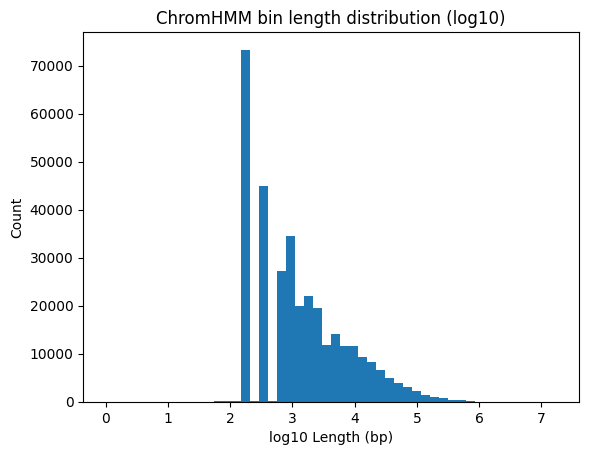

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


plt.hist(np.log10(lengths), bins=50)
plt.title("ChromHMM bin length distribution (log10)")
plt.xlabel("log10 Length (bp)")
plt.ylabel("Count")
plt.show()

The exploratory analysis of the ChromHMM segmentations across the selected cell types shows that genomic bins are highly variable in length, with mean segment sizes ranging from approximately 3.8 kb to 8.6 kb, but accompanied by very large standard deviations (≈25k–49k bp), reflecting a strongly skewed distribution. While the majority of segments fall within the kilobase range—consistent with typical regulatory regions—there exist extreme outliers reaching up to ~17.6 Mb, which correspond to large quiescent or heterochromatic domains. This heavy-tailed distribution explains why a standard linear histogram appears misleading, collapsing most values near zero; a log-scale visualization is more appropriate to reveal the true structure. Importantly, these results confirm that ChromHMM does not produce fixed-size bins but variable-length regions, meaning that the chosen 4096 bp windows are well aligned with the dominant scale of the data, though they will often overlap multiple chromatin states. Consequently, downstream labeling will require an overlap-based strategy (e.g., majority or proportional assignment), as direct one-to-one alignment between windows and ChromHMM segments is not possible.

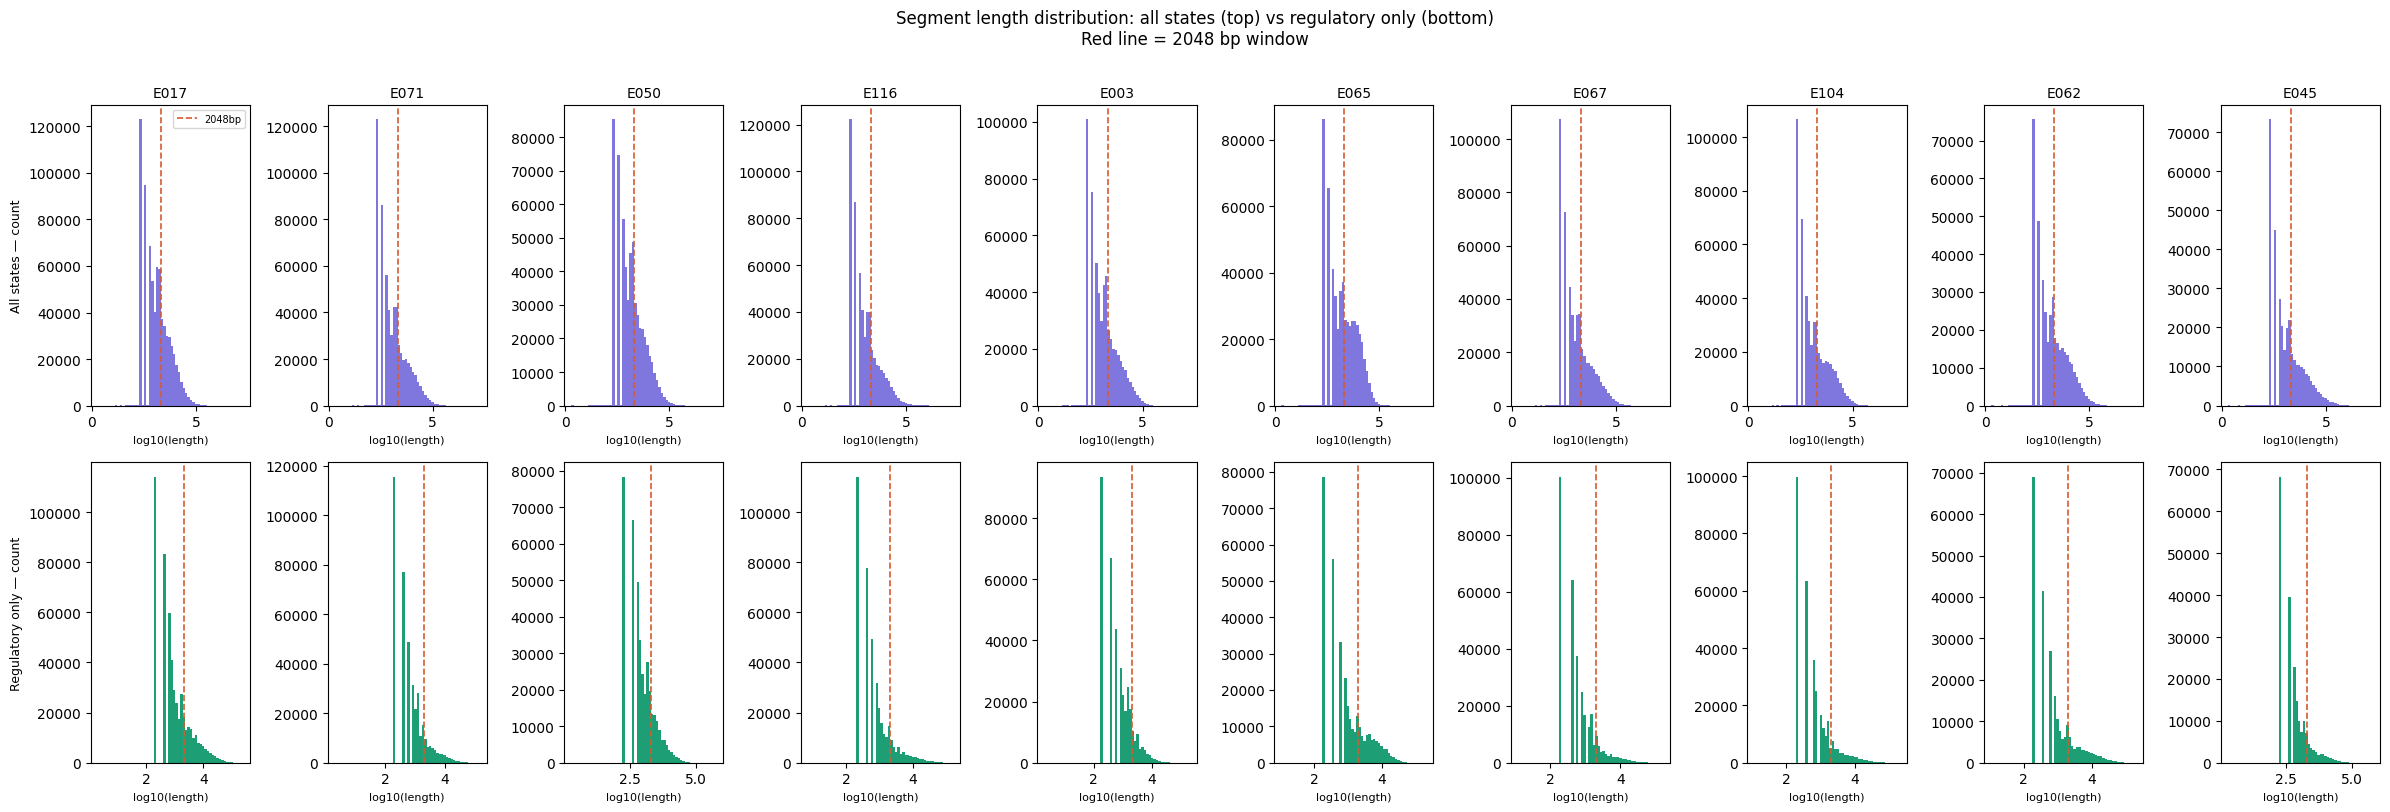

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BACKGROUND_STATES = {'18_Quies', '6_TxWk', '5_Tx'}  # broad/uninformative states

fig, axes = plt.subplots(2, len(chromhmm_data), figsize=(24, 8))

for i, (ct, df) in enumerate(chromhmm_data.items()):
    df['length'] = df['end'] - df['start']

    # Full distribution
    ax = axes[0, i]
    ax.hist(np.log10(df['length'] + 1), bins=60, color='#7F77DD', edgecolor='none')
    ax.set_title(ct, fontsize=10)
    ax.set_xlabel('log10(length)', fontsize=8)
    ax.set_ylabel('count' if i == 0 else '', fontsize=8)
    ax.axvline(np.log10(2048), color='#D85A30', linewidth=1.2, linestyle='--', label='2048bp')
    if i == 0:
        ax.legend(fontsize=7)

    # Regulatory only (drop background states)
    reg = df[~df['state'].isin(BACKGROUND_STATES)]
    ax2 = axes[1, i]
    ax2.hist(np.log10(reg['length'] + 1), bins=60, color='#1D9E75', edgecolor='none')
    ax2.axvline(np.log10(2048), color='#D85A30', linewidth=1.2, linestyle='--')
    ax2.set_xlabel('log10(length)', fontsize=8)
    ax2.set_ylabel('count (reg. only)' if i == 0 else '', fontsize=8)

axes[0, 0].set_ylabel('All states — count', fontsize=9)
axes[1, 0].set_ylabel('Regulatory only — count', fontsize=9)
plt.suptitle('Segment length distribution: all states (top) vs regulatory only (bottom)\nRed line = 2048 bp window', y=1.01)
plt.tight_layout()
plt.show()

* Two rows of histograms (one column per cell type). Top row: all 18 states included. Bottom row: background states removed (18_Quies, 6_TxWk, 5_Tx). The red line marks your 2048 bp window in each panel.

* Removing background states shifts the peak left, toward smaller segments. This is the key finding: Quies and TxWk inflate the apparent segment size because they form the largest, most consolidated chromatin domains. The truly regulatory states (promoters, enhancers, bivalent regions) are much more compact — typically under 2 kb.
* In the regulatory-only panels, most segments fall left of the 4096 bp line. This means your window is actually larger than most individual regulatory segments — so the window will almost always span multiple functional states, not be contained within one.

* The shape is more symmetric and unimodal in the regulatory-only panels. The extreme right tail (from Quies/Het) is gone. This confirms that the skewness in Plot 1 was almost entirely driven by a small number of very large inactive domains.
* What it tells you about intersection: For CpG islands (which are almost always in regulatory or active regions, not quiescent ones), the relevant ChromHMM segments will be smaller than 4096 bp. Each island will overlap multiple regulatory bins. Proportional labeling is strongly justified — you can't pick just one state without losing real biological information.

      state  pct_within_2048  median_len  n_segments
 4_TssFlnkD        99.907508       200.0     18488.2
 3_TssFlnkU        99.408856       340.0     21245.7
  2_TssFlnk        99.008009       339.9     19780.2
  15_EnhBiv        98.926648       300.0      6573.4
   11_EnhWk        96.870946       400.0     79902.1
    9_EnhA1        96.836601       420.0     28501.2
  14_TssBiv        96.580617       500.0      4722.7
     1_TssA        95.754279       540.0     19487.0
    8_EnhG2        93.470298       560.0      3027.6
   10_EnhA2        93.114716       560.0     29577.2
    7_EnhG1        92.739499       540.0     11566.5
12_ZNF/Rpts        88.620614       720.0     23590.1
  16_ReprPC        79.736613       980.0     14946.8
       5_Tx        58.518451      1740.0     29218.0
     13_Het        48.043632      2260.0     41867.4
     6_TxWk        46.148731      2360.0     88272.5
17_ReprPCWk        25.100108      5140.0     29533.6
   18_Quies        13.582192     13460.0     6

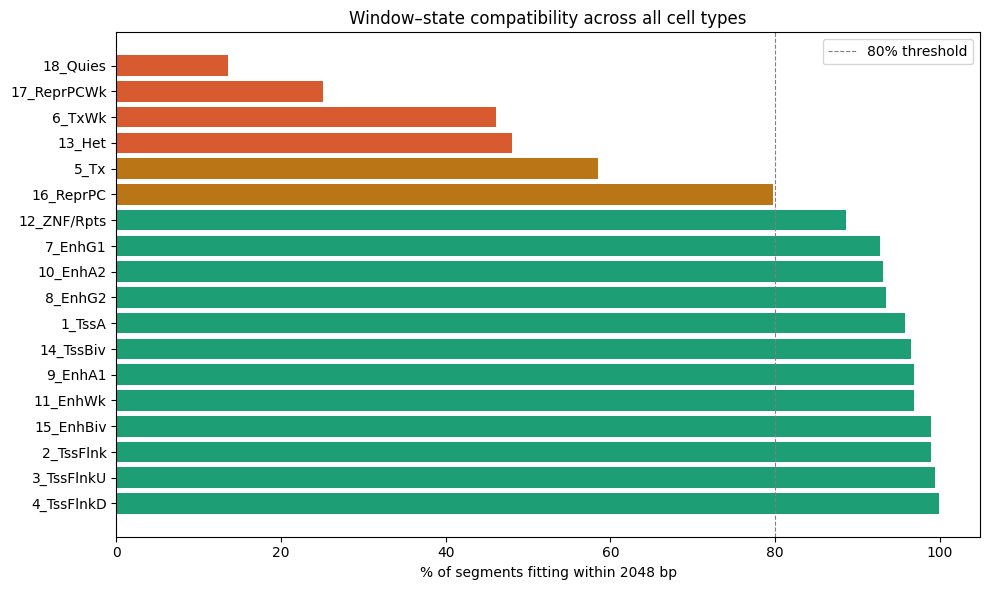

In [ ]:
results = []

for ct, df in chromhmm_data.items():
    df['length'] = df['end'] - df['start']
    for state, grp in df.groupby('state'):
        pct_within = (grp['length'] <= 2048).mean() * 100
        results.append({
            'cell_type': ct,
            'state': state,
            'pct_within_2048': pct_within,
            'median_len': grp['length'].median(),
            'n_segments': len(grp)
        })

compat = pd.DataFrame(results)

# Average across cell types per state
state_summary = (
    compat.groupby('state')
    .agg(
        pct_within_2048 = ('pct_within_2048', 'mean'),
        median_len      = ('median_len',       'mean'),
        n_segments      = ('n_segments',       'mean')
    )
    .sort_values('pct_within_2048', ascending=False)
    .reset_index()
)

print(state_summary.to_string(index=False))

# Visual
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1D9E75' if p >= 80 else '#BA7517' if p >= 50 else '#D85A30'
          for p in state_summary['pct_within_2048']]
ax.barh(state_summary['state'], state_summary['pct_within_2048'], color=colors)
ax.axvline(80, color='gray', linestyle='--', linewidth=0.8, label='80% threshold')
ax.set_xlabel('% of segments fitting within 2048 bp')
ax.set_title('Window–state compatibility across all cell types')
ax.legend()
plt.tight_layout()
plt.show()

Not directly useful for your modeling, but it is a global sanity check about chromatin scale vs model window

In [ ]:
! pip install pybedtools

“How many different ChromHMM states overlap each CpG island?”

In [ ]:
df.head()

,chrom,start,end,state,length
0,chr1,10000,10400,12_ZNF/Rpts,400
1,chr1,10400,10600,13_Het,200
2,chr1,10600,96080,18_Quies,85480
3,chr1,96276,96476,18_Quies,200
4,chr1,97276,177200,18_Quies,79924


In [ ]:
!apt-get -qq update
!apt-get -qq install -y bedtools

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package bedtools.
(Reading database ... 118252 files and directories currently installed.)
Preparing to unpack .../bedtools_2.30.0+dfsg-2ubuntu0.1_amd64.deb ...
Unpacking bedtools (2.30.0+dfsg-2ubuntu0.1) ...
Setting up bedtools (2.30.0+dfsg-2ubuntu0.1) ...


In [ ]:
!which bedtools
!bedtools --version

/usr/bin/bedtools
bedtools v2.30.0


In [ ]:
!pip install pybedtools

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 37.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 63.8 MB/s eta 0:00:00
  Created wheel for pybedtools: filename=pybedtools-0.12.0-cp312-cp312-linux_x86_64.whl size=14340837 sha256=db18eece34f6271d28f386482def364986ba42635b90e4c050e2b912c10d6f4c
  Stored in directory: /root/.cache/pip/wheels/ac/38/f2/960d79e44a92afc0d34a4727c856ce0149ac23c3dcda174356
Successfully built pybedtools


In [ ]:
import pybedtools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [ ]:
a = pybedtools.BedTool("chr1\t100\t200\n", from_string=True)
b = pybedtools.BedTool("chr1\t150\t250\n", from_string=True)

print(a.intersect(b))


* The peak is at n=2–3, not n=1. Most CpG islands overlap 2 or 3 distinct ChromHMM states. Very few islands sit cleanly inside a single state. This is the single most important finding for intersection decision — **it directly proves that majority labeling will discard meaningful information for the majority of  dataset.**
* All 10 cell types show the same pattern. The lines are clustered together, meaning this is a robust biological property of CpG islands — not a quirk of one cell type. CpG islands genuinely straddle chromatin state boundaries.
* A tail extends to n=5–6. Some islands, particularly longer ones or those at the junction of multiple regulatory elements, overlap up to 6 distinct states. These are the biologically most complex islands and would be most misrepresented by a single-label approach.


What it tells you about intersection: **This is our strongest empirical argument for proportional multi-label. The average CpG island cannot be honestly described by one state. A proportion vector (e.g. 60% TssA, 30% TssAFlnk, 10% Enh) is a more truthful label than just "TssA".**


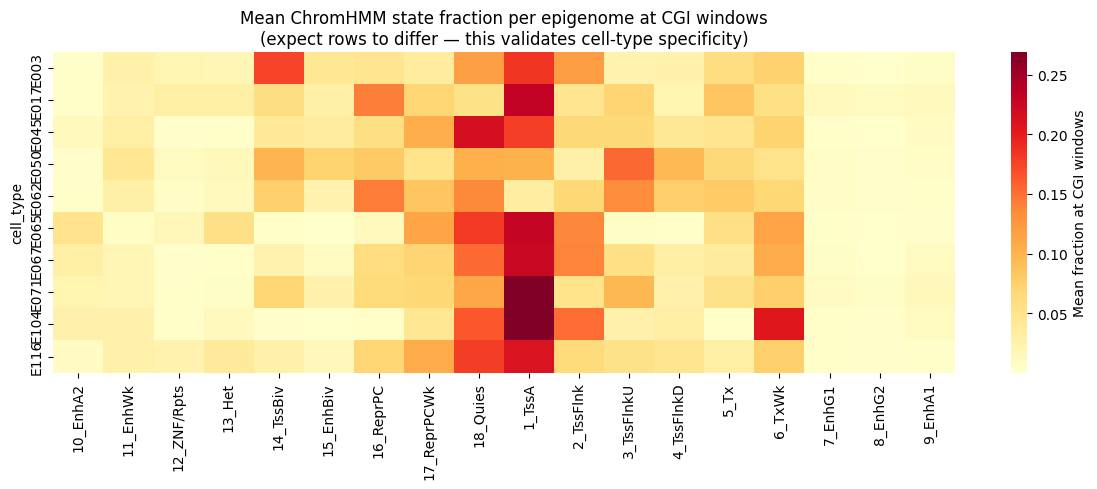

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

epi = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/epi_profiles.parquet')
STATE_COLS = [c for c in epi.columns if c.startswith('state_')]
EIDS = epi['cell_type'].unique()

# Per (tile, epigenome): fraction vector → treat as a profile string for uniqueness
# Simpler: dominant state per (tile, epigenome)
epi['dominant'] = epi[STATE_COLS].values.argmax(axis=1)

# Per cell type: distribution of dominant states across tiles
fig, ax = plt.subplots(figsize=(12, 5))

data = {eid: epi[epi['cell_type']==eid]['dominant'].values for eid in EIDS}
df_plot = pd.DataFrame({eid: pd.Series(v).value_counts(normalize=True)
                        for eid, v in data.items()}).fillna(0)

# Heatmap: epigenome × dominant state, mean fraction
pivot = (epi.groupby(['cell_type'])[STATE_COLS].mean())
pivot.columns = [c.replace('state_','') for c in pivot.columns]

sns.heatmap(pivot, cmap='YlOrRd', ax=ax,
            cbar_kws={'label':'Mean fraction at CGI windows'})
ax.set_title("Mean ChromHMM state fraction per epigenome at CGI windows\n"
             "(expect rows to differ — this validates cell-type specificity)")
plt.tight_layout()
plt.savefig('chromhmm_epigenome_heatmap.png', dpi=150)
plt.show()

This heatmap shows the mean distribution of ChromHMM states across CpG island windows for each epigenome. Each row corresponds to a cell type, and each column represents a chromatin state, with color intensity indicating the average fraction of CpG islands annotated with that state.

Overall, the figure reveals a strong and consistent enrichment of promoter-associated states, particularly TssA, across all epigenomes, confirming that CpG islands are predominantly located in active regulatory regions. In contrast, quiescent and heterochromatin-related states show relatively low and stable contributions, reflecting their depletion within CpG islands. While the general chromatin architecture is conserved across cell types, subtle differences between rows indicate cell-type-specific modulation of promoter activity and regulatory state usage. This supports the biological validity of the pipeline and highlights that CpG islands capture both a stable promoter-centered structure and a degree of epigenome-specific regulatory variation.

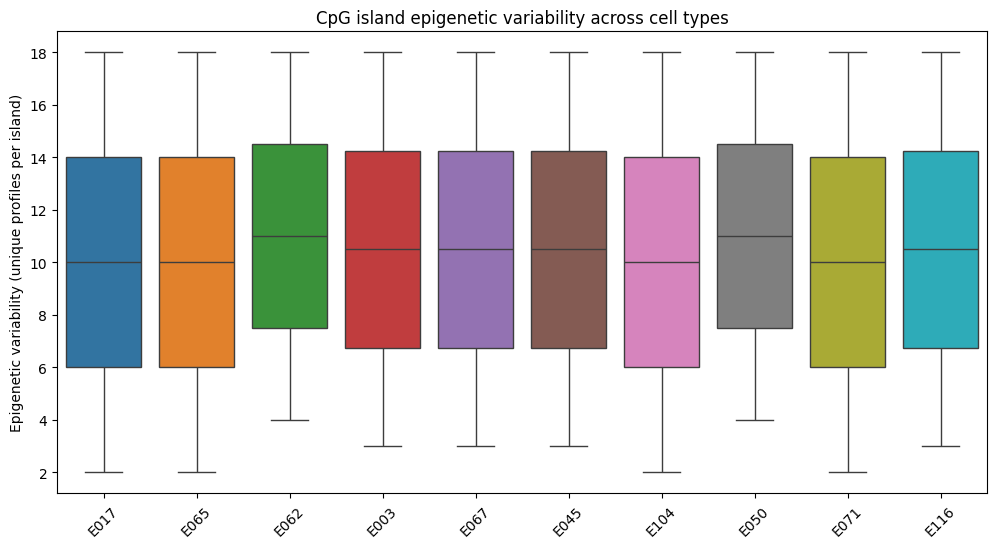

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# assume you already have:
# stability = your dataframe with state profiles per island per CT

state_cols = [c for c in stability.columns if c != "n_unique_profiles"]

# compute variability per cell type proxy
cell_types = list(set([c.split("_")[0] for c in state_cols]))

# rebuild per-cell-type variability
cell_var = {}

for ct in cell_types:
    ct_cols = [c for c in state_cols if c.startswith(ct)]
    if len(ct_cols) > 0:
        # variability = how many distinct patterns across islands
        var = stability[ct_cols].nunique(axis=1)
        cell_var[ct] = var

# convert to dataframe
var_df = pd.DataFrame(cell_var)

# plot
plt.figure(figsize=(12,6))
sns.boxplot(data=var_df)
plt.xticks(rotation=45)
plt.ylabel("Epigenetic variability (unique profiles per island)")
plt.title("CpG island epigenetic variability across cell types")
plt.show()

The analysis of epigenetic variability across CpG islands reveals a moderate to high level of chromatin plasticity across cell types. Most CpG islands exhibit multiple distinct chromatin state configurations, with median variability values around ~10 unique profiles per island depending on the epigenome. This indicates that CpG islands are not strictly static regulatory elements, but rather display context-dependent chromatin remodeling across cellular environments. Although the overall variability distributions are relatively similar across cell types, subtle shifts suggest that certain epigenomes (e.g., E062, E050) may exhibit slightly higher regulatory diversity, potentially reflecting more dynamic or heterogeneous chromatin regulation. Overall, these results support the hypothesis that CpG islands participate in cell-type-specific regulatory programs rather than maintaining invariant chromatin states.

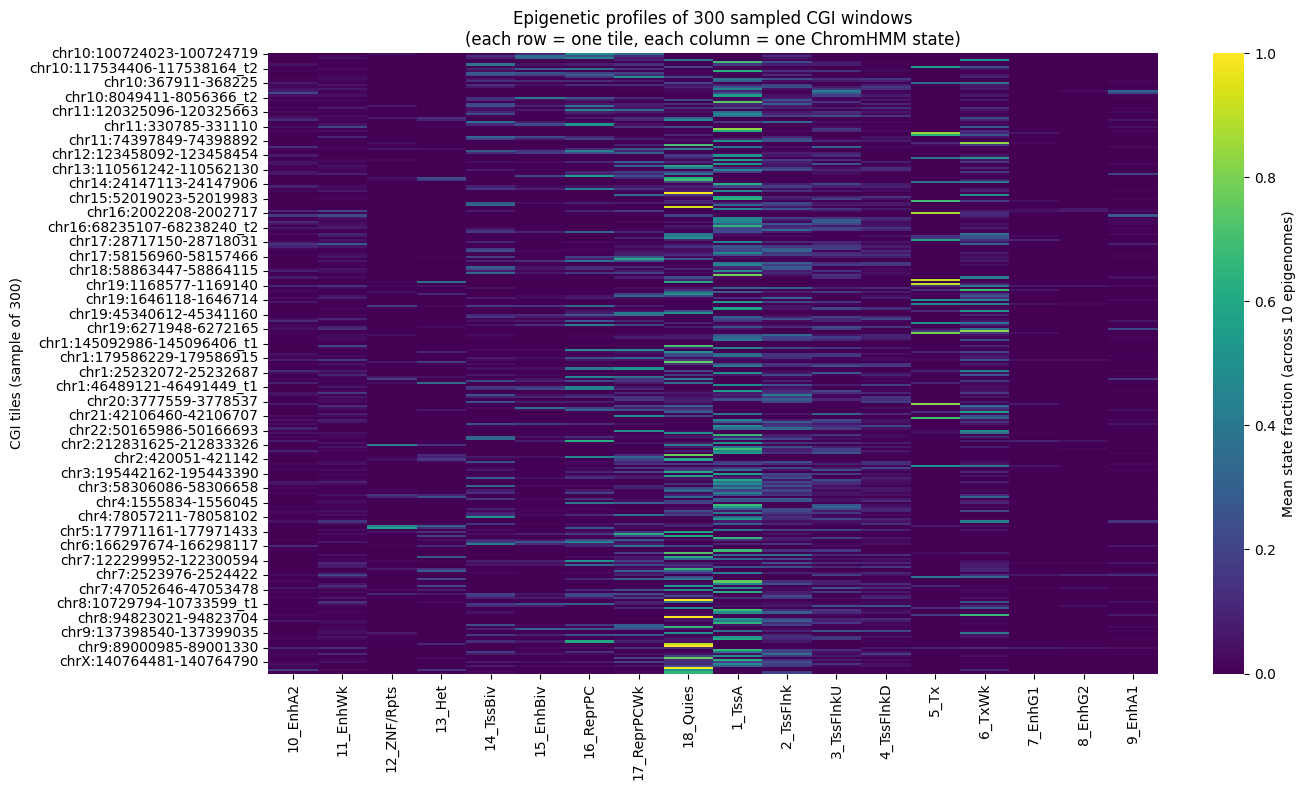

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

epi = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/epi_profiles.parquet')
STATE_COLS = [c for c in epi.columns if c.startswith('state_')]

# Sample 300 tiles, show profiles across all cell types
sample_tiles = epi['tile_id'].drop_duplicates().sample(300, random_state=42)
sample = epi[epi['tile_id'].isin(sample_tiles)].copy()

# Pivot: rows = tile_id, columns = cell_type × state (or just mean across cell types)
mean_by_tile = sample.groupby('tile_id')[STATE_COLS].mean()
mean_by_tile.columns = [c.replace('state_','') for c in mean_by_tile.columns]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(mean_by_tile, cmap='viridis', ax=ax,
            cbar_kws={'label': 'Mean state fraction (across 10 epigenomes)'})
ax.set_title("Epigenetic profiles of 300 sampled CGI windows\n"
             "(each row = one tile, each column = one ChromHMM state)")
ax.set_ylabel("CGI tiles (sample of 300)")
plt.tight_layout()
plt.savefig('chromhmm_tile_heatmap.png', dpi=150)
plt.show()

The heatmap reveals that CpG island (CGI) windows exhibit highly heterogeneous epigenetic profiles rather than a single uniform chromatin signature. Each row corresponds to one CGI tile and each column to a ChromHMM state, where brighter colors indicate stronger state enrichment averaged across the 10 epigenomes. The strongest and most recurrent signals are concentrated in promoter- and transcription-associated states, particularly 1_TssA, 2_TssFlnk, and partially 5_Tx, confirming that a substantial subset of CGI windows is associated with active regulatory regions. At the same time, the widespread presence of 18_Quies demonstrates that many CGI windows remain inactive or cell-type-dependent despite their CpG-rich sequence composition. The coexistence of active, repressed, and quiescent patterns across different rows highlights the biological diversity of CGIs and confirms that sequence alone does not determine chromatin state. Importantly, the heatmap also shows structured patterns rather than random noise: certain windows consistently activate promoter states while others remain predominantly quiescent, indicating that the generated epigenetic labels are biologically coherent and informative. These observations strongly support the decision to model the problem as a sequence-to-epigenome prediction task, since the same DNA sequence can adopt different chromatin configurations depending on cellular context. The figure further suggests that the dataset contains meaningful inter-cell-type variability, which is essential for training a robust deep learning model capable of learning regulatory sequence determinants rather than memorizing static promoter annotations.

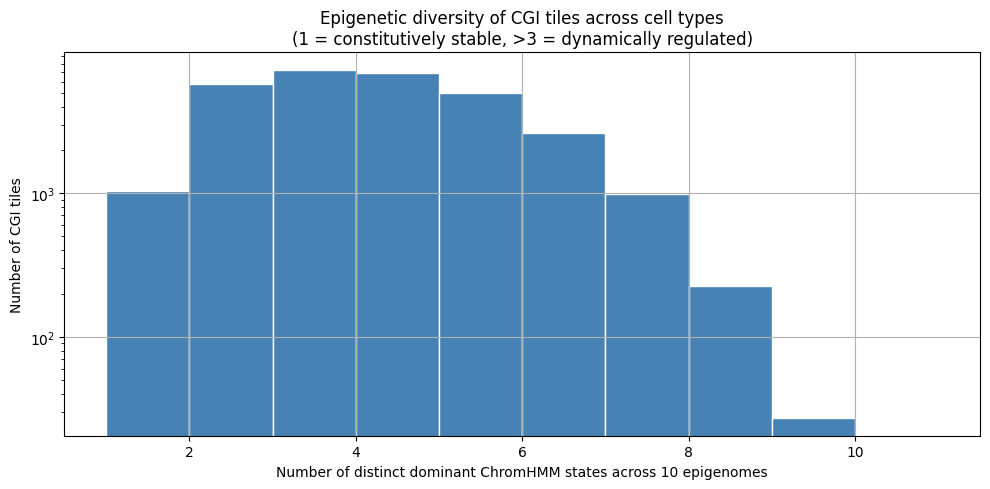

count    29790.000000
mean         3.740584
std          1.492236
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          9.000000
Name: dominant, dtype: float64

Tiles with exactly 1 state  : 1,032 (3.5%)
Tiles with 2 states         : 5,782 (19.4%)
Tiles with 3+ states        : 22,976 (77.1%)


In [ ]:
import matplotlib.pyplot as plt

# Use 'diversity' from the corrected cell 200
epi = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/epi_profiles.parquet')
STATE_COLS = [c for c in epi.columns if c.startswith('state_')]
epi['dominant'] = epi[STATE_COLS].values.argmax(axis=1)
diversity = epi.groupby('tile_id')['dominant'].nunique()  # recompute if needed

fig, ax = plt.subplots(figsize=(10, 5))
diversity.hist(bins=range(1, 12), ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel("Number of distinct dominant ChromHMM states across 10 epigenomes")
ax.set_ylabel("Number of CGI tiles")
ax.set_title("Epigenetic diversity of CGI tiles across cell types\n" +
             "(1 = constitutively stable, >3 = dynamically regulated)")
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('chromhmm_diversity_histogram.png', dpi=150)
plt.show()

print(diversity.describe())
print(f"\nTiles with exactly 1 state  : {(diversity == 1).sum():,} ({(diversity==1).mean()*100:.1f}%)")
print(f"Tiles with 2 states         : {(diversity == 2).sum():,} ({(diversity==2).mean()*100:.1f}%)")
print(f"Tiles with 3+ states        : {(diversity >= 3).sum():,} ({(diversity>=3).mean()*100:.1f}%)")

The epigenetic diversity analysis demonstrates that most CpG island (CGI) tiles do not maintain a single stable chromatin identity across cell types, but instead transition between multiple dominant ChromHMM states depending on the epigenomic context. For each tile, the analysis counted how many distinct dominant states appeared across the 10 epigenomes, where a value of 1 indicates a constitutively stable regulatory behavior and higher values indicate increasing epigenetic plasticity. The distribution shows a mean diversity of approximately 3.7 states per tile, with some tiles exhibiting up to 9 different dominant states across cell types. Only 3.5% of tiles remained associated with a single dominant state, while more than 77% displayed three or more dominant chromatin configurations, revealing that the majority of CGI regions are dynamically regulated rather than fixed regulatory elements. This result provides strong evidence that CpG islands are highly context-dependent genomic regions whose regulatory activity varies substantially between tissues or cellular conditions. Biologically, this supports the hypothesis that the same DNA sequence can participate in different regulatory programs depending on the surrounding epigenetic environment. From a modeling perspective, these findings strongly justify the multi-epigenome learning strategy adopted in the project: if most tiles exhibited only one stable state, predicting ChromHMM profiles from sequence would be relatively trivial and less informative. Instead, the observed variability confirms that the dataset contains rich cell-type-specific regulatory information, making it suitable for training a deep learning model capable of learning complex sequence–epigenome relationships rather than merely memorizing static promoter-associated patterns.

# Alginment chromHMM

In [ ]:
!pip install pybedtools

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 69.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 36.3 MB/s eta 0:00:00
  Created wheel for pybedtools: filename=pybedtools-0.12.0-cp312-cp312-linux_x86_64.whl size=14340825 sha256=82f6a26b684156dce5199a296f2433f59a629fe524e2d1cc10a5816f2a5f59ea
  Stored in directory: /root/.cache/pip/wheels/ac/38/f2/960d79e44a92afc0d34a4727c856ce0149ac23c3dcda174356
Successfully built pybedtools


In [ ]:
import os
import numpy as np
import pandas as pd
import pybedtools
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── Paths ─────────────────────────────────────────────────────────────────────
CLEAN_WINDOWS_PATH = '/content/drive/MyDrive/PFE/data/processed/clean_windows_removed_duplicates.parquet'
CHROMHMM_DIR       = '/content/drive/MyDrive/PFE/data/chromHMM'
EMBEDDINGS_PATH    = '/content/drive/MyDrive/PFE/data/processed/window_embeddings.npy'
INDEX_PATH         = '/content/drive/MyDrive/PFE/data/processed/window_index.parquet'

WINDOW_BED_PATH    = '/content/drive/MyDrive/PFE/data/processed/windows.bed'
EPI_PROFILES_PATH  = '/content/drive/MyDrive/PFE/data/processed/epi_profiles.parquet'

WINDOW_SIZE = 2048

In [ ]:
# STEP 1 — Load the window DataFrame
# ─────────────────────────────────────────────────────────────────────────────
# PURPOSE: establish the ground truth for all downstream steps.
# Every row is one tile. tile_id is the join key throughout.
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_parquet(CLEAN_WINDOWS_PATH)

print(f"Windows loaded   : {len(df):,}")
print(f"Unique islands   : {df['island_id'].nunique():,}")
print(f"Tiled windows    : {df['is_tiled'].sum():,}  ({df['is_tiled'].mean()*100:.1f}%)")
print(f"Columns          : {df.columns.tolist()}")

# All windows must be exactly WINDOW_SIZE bp — verify before anything else
win_len = df['win_end'] - df['win_start']
assert (win_len == WINDOW_SIZE).all(), \
    f"Not all windows are {WINDOW_SIZE} bp. Check win_start/win_end."
print(f"All windows are {WINDOW_SIZE} bp ✅")


Windows loaded   : 29,790
Unique islands   : 27,841
Tiled windows    : 3,173  (10.7%)
Columns          : ['island_id', 'tile_id', 'tile_index', 'n_tiles', 'is_tiled', 'chrom', 'island_start', 'island_end', 'island_length', 'win_start', 'win_end', 'sequence', 'gc_content', 'obsExp', 'cpg_density', 'n_content']
All windows are 2048 bp ✅


In [ ]:
# STEP 2 — Export window-level BED file
# ─────────────────────────────────────────────────────────────────────────────
# PURPOSE: BEDTools needs a coordinate file. We use WINDOW coordinates
# (win_start, win_end), NOT island coordinates. This is the critical
# difference from the EDA intersection done earlier with island-level BED.
#
# Column 4 = tile_id so BEDTools returns it in intersection output,
# allowing an exact row-to-row join back to the embeddings.
#
# WHY WINDOW COORDS AND NOT ISLAND COORDS:
#   - Embeddings are computed per tile window, not per island
#   - For a tiled island, each tile must get its OWN epigenetic profile
#     (tile 0 may be 80% Tss while tile 2 is 90% TxWk)
#   - Labels must align row-by-row with embeddings
# ─────────────────────────────────────────────────────────────────────────────

df[['chrom', 'win_start', 'win_end', 'tile_id']].to_csv(
    WINDOW_BED_PATH, sep='\t', header=False, index=False
)
print(f"\nWindow BED saved : {WINDOW_BED_PATH}  ({len(df):,} rows)")




Window BED saved : /content/drive/MyDrive/PFE/data/processed/windows.bed  (29,790 rows)


## Step 3

---
The ChromHMM annotations were successfully loaded for all 10 selected epigenomes, with each file containing between ~334k and ~742k genomic segments distributed across the full set of 18 Roadmap chromatin states. The mean segment lengths range from ~3.8 kb to ~8.6 kb, confirming that ChromHMM produces highly variable genomic intervals rather than fixed-size bins. Extremely large segments (up to ~17.6 Mb) correspond to extended quiescent or heterochromatic regions, while the presence of very small segments reflects sharp local state transitions around regulatory elements. Importantly, all epigenomes contain the complete 18-state vocabulary, allowing a consistent multimodal representation across tissues without missing-state reindexing. This step therefore validates that the chromatin-state annotations are structurally coherent and ready for downstream overlap computation with the 2,048 bp CGI-centered windows. Conceptually, the current stage only loads and standardizes the genome-wide regulatory maps; the actual window-level state fractions are computed later through genomic interval intersection.



In [ ]:
# STEP 3 — Load all ChromHMM BED files
# ─────────────────────────────────────────────────────────────────────────────
# PURPOSE: each cell type has one BED file with variable-size segments
# (typically 200 bp but can be 150–1000 bp). We load them all into a dict.
#
# NOTE ON VARIABLE BIN SIZES:
#   Variable sizes do NOT cause a problem. We compute overlap in raw base
#   pairs using BEDTools, then divide by the window's actual bp covered.
#   A 1000 bp segment overlapping 400 bp of our window contributes exactly
#   400 bp — same as four 100 bp segments each overlapping 100 bp.
#   The result is always a fraction in [0,1].
# ─────────────────────────────────────────────────────────────────────────────

chromhmm_data = {}

for fname in sorted(os.listdir(CHROMHMM_DIR)):
    if not fname.endswith('.bed'):
        continue
    ep_id = fname.split('_')[0]
    bed_path = os.path.join(CHROMHMM_DIR, fname)

    ct_df = pd.read_csv(
        bed_path, sep=r'\s+', header=None, skiprows=1, engine='python'
    ).iloc[:, :4]
    ct_df.columns = ['chrom', 'start', 'end', 'state']
    chromhmm_data[ep_id] = ct_df

    seg_len = ct_df['end'] - ct_df['start']
    print(f"  {ep_id}: {len(ct_df):,} segments | "
          f"length: min={seg_len.min()} mean={seg_len.mean():.0f} max={seg_len.max()} bp | "
          f"{ct_df['state'].nunique()} states")

print(f"\nLoaded {len(chromhmm_data)} cell types")

# Collect all state names across all cell types for consistent column ordering
all_states = sorted(
    set(s for ct in chromhmm_data.values() for s in ct['state'].unique())
)
print(f"Total unique states across all cell types: {len(all_states)}")
print(all_states)



  E003: 572,578 segments | length: min=1 mean=5005 max=17579033 bp | 18 states
  E017: 742,095 segments | length: min=1 mean=3861 max=17579033 bp | 18 states
  E045: 334,047 segments | length: min=1 mean=8578 max=17579033 bp | 18 states
  E050: 587,142 segments | length: min=1 mean=4881 max=17579033 bp | 18 states
  E062: 404,908 segments | length: min=1 mean=7077 max=17579033 bp | 18 states
  E065: 552,166 segments | length: min=1 mean=5190 max=17579033 bp | 18 states
  E067: 512,822 segments | length: min=1 mean=5588 max=17579033 bp | 18 states
  E071: 610,662 segments | length: min=1 mean=4693 max=17579033 bp | 18 states
  E104: 500,950 segments | length: min=1 mean=5720 max=17579033 bp | 18 states
  E116: 575,768 segments | length: min=1 mean=4933 max=17579033 bp | 18 states

Loaded 10 cell types
Total unique states across all cell types: 18
['10_EnhA2', '11_EnhWk', '12_ZNF/Rpts', '13_Het', '14_TssBiv', '15_EnhBiv', '16_ReprPC', '17_ReprPCWk', '18_Quies', '1_TssA', '2_TssFlnk', '3_

In [ ]:
!apt-get update -qq
!apt-get install -y bedtools

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
bedtools is already the newest version (2.30.0+dfsg-2ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 17 not upgraded.


In [ ]:
import pybedtools


In [ ]:
!bedtools --version

bedtools v2.30.0


In [ ]:
import importlib
import pybedtools

importlib.reload(pybedtools)

print(pybedtools.helpers.get_bedtools_path())

Just testing the intersection using bedTool

In [ ]:
from pybedtools import BedTool

a = BedTool('chr1\t1\t10\n', from_string=True)
b = BedTool('chr1\t5\t15\n', from_string=True)

print(a.intersect(b).head())

chr1	5	10
 None


## Intersection & normalization ( normalisation: make the overlaps as propotions that sum to 1 )
This step converts variable-length ChromHMM genome segmentations into fixed-size epigenomic profiles aligned to the 2,048 bp CGI windows. For each cell type, BEDTools computes the overlap in base pairs between every genomic tile and every ChromHMM segment. Overlap lengths are summed per state and immediately normalised to produce an 18-dimensional fraction vector whose values sum to approximately 1.0. Each value represents the proportion of the window occupied by a given state (e.g., active promoter, enhancer, quiescent chromatin). Normalisation is performed before reindexing to avoid introducing invalid 0/0 divisions for tiles without overlap. The resulting profiles provide a biologically interpretable and machine-learning-ready representation of functional state context aligned across all genomic windows and epigenomes.


In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# STEP 4 — Intersect + normalise immediately (per cell type)
# ─────────────────────────────────────────────────────────────────────────────
# PURPOSE: for each cell type, compute a normalised fraction vector (18-d)
# for every tile window. This is the per-cell-type epigenetic label.
#
# NORMALISATION ORDER (important — as per your instruction):
#   1. BEDTools intersect -wo → raw overlap_bp per (tile_id, state)
#   2. Sum overlap_bp per (tile_id, state) → total bp per state
#   3. NORMALISE IMMEDIATELY: divide by total observed bp for that tile
#      (sum across all states = total bp of the window that overlapped
#      any ChromHMM segment; for interior windows = WINDOW_SIZE)
#   4. Reindex to all tile_ids → fill tiles with no overlap as all-zeros
#
# WHY NORMALISE BEFORE REINDEXING:
#   If we reindex first (adding zero rows for tiles with no overlap) and
#   then normalise, the zero-filled rows would produce 0/0 = NaN or
#   incorrect fractions. Normalising first means only tiles with actual
#   overlap get fractions; zero-filled tiles remain all-zeros, which is
#   the correct representation (no state covers this tile).
#
# WHAT THE FRACTION VECTOR REPRESENTS:
#   For a tile window of 2048 bp, if the BED intersection shows:
#     Active TSS:  820 bp overlap  → fraction = 820/2048 = 0.400
#     Enhancer:    614 bp overlap  → fraction = 614/2048 = 0.300
#     Quiescent:   614 bp overlap  → fraction = 614/2048 = 0.300
#   The vector sums to 1.0 and encodes the proportional epigenetic landscape
#   of that exact 2048 bp window in that specific cell type.
#   Fractions do NOT tell you WHERE within the window each state is — '''**that
#   spatial information lives in the original BED files and can be recovered
#   for interpretation after prediction.**'''
# ─────────────────────────────────────────────────────────────────────────────

all_tile_ids   = df['tile_id'].values
cpg_win_bed    = pybedtools.BedTool(WINDOW_BED_PATH)
profiles_by_ct = {}

print(f"\nIntersecting {len(df):,} windows × {len(chromhmm_data)} cell types …\n")

for ep_id, ct_df in tqdm(chromhmm_data.items(), desc="Cell types"):

    # ── 4a. BEDTools intersection ─────────────────────────────────────────
    hmm_bed = pybedtools.BedTool.from_dataframe(
        ct_df[['chrom', 'start', 'end', 'state']]
    )

    # -wo reports overlap length in the last column
    # Columns: win_chrom|win_start|win_end|tile_id|hmm_chrom|hmm_start|hmm_end|state|overlap_bp
    intersected = cpg_win_bed.intersect(hmm_bed, wo=True).to_dataframe(
        names=[
            'win_chrom', 'win_start', 'win_end', 'tile_id',
            'hmm_chrom', 'hmm_start', 'hmm_end', 'state', 'overlap_bp',
        ]
    )

    if intersected.empty:
        print(f"  WARNING: {ep_id} produced no overlaps — filling all tiles with zeros")
        empty_profile = pd.DataFrame(
            0.0,
            index=pd.Index(all_tile_ids, name='tile_id'),
            columns=all_states,
        )
        profiles_by_ct[ep_id] = empty_profile
        continue

    # ── 4b. Sum overlap_bp per (tile_id, state) ───────────────────────────
    state_bp = (
        intersected
        .groupby(['tile_id', 'state'])['overlap_bp']
        .sum()
        .unstack(fill_value=0)   # pivot: rows=tile_id, cols=state, values=bp
    )

    # ── 4c. NORMALISE IMMEDIATELY ─────────────────────────────────────────
    # Denominator = total bp of this tile that overlapped ANY ChromHMM segment.
    # For interior windows this equals WINDOW_SIZE. For rare boundary windows
    # it may be slightly less — dividing by the actual sum handles this correctly.
    row_totals = state_bp.sum(axis=1)           # total observed overlap bp per tile

    # Tiles where row_total == 0 have no ChromHMM overlap at all.
    # We keep them as zeros (handled by reindex below). clamp(1) avoids /0.
    state_frac = state_bp.div(row_totals.clip(lower=1), axis=0)

    # ── 4d. Ensure all 18 states are present (some may be absent from a CT) ─
    for s in all_states:
        if s not in state_frac.columns:
            state_frac[s] = 0.0
    state_frac = state_frac[all_states]   # enforce consistent column order

    # ── 4e. Reindex to ALL tile_ids — tiles with no overlap get all-zeros ──
    state_frac = state_frac.reindex(all_tile_ids, fill_value=0.0)
    state_frac.index.name = 'tile_id'

    profiles_by_ct[ep_id] = state_frac

    # Quick report
    n_covered  = (state_frac.sum(axis=1) > 0).sum()
    n_uncovered = len(state_frac) - n_covered
    print(f"  {ep_id}: {n_covered:,} tiles with coverage | "
          f"{n_uncovered} tiles all-zero | "
          f"mean row sum = {state_frac.sum(axis=1).mean():.4f}  (should be ≈1.0)")

print("\nIntersection + normalisation complete ✅")


Intersecting 29,790 windows × 10 cell types …



Cell types:  10%|█         | 1/10 [00:02<00:21,  2.39s/it]

  E003: 29,378 tiles with coverage | 412 tiles all-zero | mean row sum = 0.9862  (should be ≈1.0)


Cell types:  20%|██        | 2/10 [00:10<00:44,  5.50s/it]

  E017: 29,378 tiles with coverage | 412 tiles all-zero | mean row sum = 0.9862  (should be ≈1.0)


...

  E071: 29,378 tiles with coverage | 412 tiles all-zero | mean row sum = 0.9862  (should be ≈1.0)


Cell types:  90%|█████████ | 9/10 [00:51<00:07,  7.03s/it]

  E104: 29,378 tiles with coverage | 412 tiles all-zero | mean row sum = 0.9862  (should be ≈1.0)


Cell types: 100%|██████████| 10/10 [01:00<00:00,  6.07s/it]

  E116: 29,278 tiles with coverage | 512 tiles all-zero | mean row sum = 0.9828  (should be ≈1.0)

Intersection + normalisation complete ✅


## STEP 5 — Verify fraction vectors


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PURPOSE: confirm that normalisation is correct. For tiles with ChromHMM
# coverage the row sum should be 1.0 (or very close for floating point).
# Tiles with no coverage (near telomeres, assembly gaps) will sum to 0.0.
# ─────────────────────────────────────────────────────────────────────────────

print("\n── Fraction vector verification ────────────────────────────────────")
for ep_id, profile in profiles_by_ct.items():
    row_sums     = profile.sum(axis=1)
    covered      = row_sums > 0
    covered_sums = row_sums[covered]

    bad = ((covered_sums < 0.99) | (covered_sums > 1.01)).sum()
    print(f"  {ep_id}: covered={covered.sum():,} | "
          f"mean_sum={covered_sums.mean():.6f} | "
          f"rows outside [0.99, 1.01]: {bad}  {'✅' if bad == 0 else '⚠️ CHECK'}")



── Fraction vector verification ────────────────────────────────────
  E003: covered=29,378 | mean_sum=1.000000 | rows outside [0.99, 1.01]: 0  ✅
  E017: covered=29,378 | mean_sum=1.000000 | rows outside [0.99, 1.01]: 0  ✅
  E045: covered=29,378 | mean_sum=1.000000 | rows outside [0.99, 1.01]: 0  ✅
  E050: covered=29,378 | mean_sum=1.000000 | rows outside [0.99, 1.01]: 0  ✅
  E062: covered=29,378 | mean_sum=1.000000 | rows outside [0.99, 1.01]: 0  ✅
  E065: covered=29,378 | mean_sum=1.000000 | rows outside [0.99, 1.01]: 0  ✅
  E067: covered=29,378 | mean_sum=1.000000 | rows outside [0.99, 1.01]: 0  ✅
  E071: covered=29,378 | mean_sum=1.000000 | rows outside [0.99, 1.01]: 0  ✅
  E104: covered=29,378 | mean_sum=1.000000 | rows outside [0.99, 1.01]: 0  ✅
  E116: covered=29,278 | mean_sum=1.000000 | rows outside [0.99, 1.01]: 0  ✅


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 — Build the cell-specific epigenetic profile DataFrame
# ─────────────────────────────────────────────────────────────────────────────
# PURPOSE: stack all cell types into a single long-format DataFrame.
# This is the structure your cell-specific predictor needs:
#
#   tile_id | cell_type | state_1TssA | state_2TssAFlnk | … | state_18Quies
#   ─────────────────────────────────────────────────────────────────────────
#   tile_0  | E003      | 0.72        | 0.08            | … | 0.00
#   tile_0  | E116      | 0.41        | 0.22            | … | 0.10
#   tile_0  | E017      | 0.05        | 0.03            | … | 0.88
#   …
#   tile_0  | E104      | 0.60        | 0.15            | … | 0.02
#   tile_1  | E003      | 0.15        | 0.05            | … | 0.70
#   …
#
# Total rows = N_tiles × N_cell_types = ~30,000 × 10 = ~300,000
# The sequence embedding is NOT stored here — it is joined at training time
# by tile_id (see Step 8). This avoids storing 512 floats × 10 copies per tile.
# ─────────────────────────────────────────────────────────────────────────────

profile_frames = []

for ep_id, profile in profiles_by_ct.items():
    frame = profile.copy()
    frame.index.name = 'tile_id'
    frame = frame.reset_index()
    frame.insert(1, 'cell_type', ep_id)   # insert cell_type as second column
    profile_frames.append(frame)

epi_df = pd.concat(profile_frames, ignore_index=True)

# Rename state columns for clarity
state_rename = {s: f'state_{s}' for s in all_states}
epi_df = epi_df.rename(columns=state_rename)
state_cols = [f'state_{s}' for s in all_states]

print(f"\nchromHMM profile DataFrame:")
print(f"  Rows     : {len(epi_df):,}  (= {df['tile_id'].nunique():,} tiles × {len(chromhmm_data)} cell types)")
print(f"  Columns  : {epi_df.columns.tolist()}")
print(f"\nSample rows:")
print(epi_df.head(3 * len(chromhmm_data)).to_string())   # first tile, all cell types


Epigenetic profile DataFrame:
  Rows     : 297,900  (= 29,790 tiles × 10 cell types)
  Columns  : ['tile_id', 'cell_type', 'state_10_EnhA2', 'state_11_EnhWk', 'state_12_ZNF/Rpts', 'state_13_Het', 'state_14_TssBiv', 'state_15_EnhBiv', 'state_16_ReprPC', 'state_17_ReprPCWk', 'state_18_Quies', 'state_1_TssA', 'state_2_TssFlnk', 'state_3_TssFlnkU', 'state_4_TssFlnkD', 'state_5_Tx', 'state_6_TxWk', 'state_7_EnhG1', 'state_8_EnhG2', 'state_9_EnhA1']

Sample rows:
state               tile_id cell_type  state_10_EnhA2  state_11_EnhWk  state_12_ZNF/Rpts  state_13_Het  state_14_TssBiv  state_15_EnhBiv  state_16_ReprPC  state_17_ReprPCWk  state_18_Quies  state_1_TssA  state_2_TssFlnk  state_3_TssFlnkU  state_4_TssFlnkD  state_5_Tx  state_6_TxWk  state_7_EnhG1  state_8_EnhG2  state_9_EnhA1
0          chr1:28735-29737      E003             0.0        0.000000                0.0           0.0         0.000000         0.000000         0.000000           0.000000             1.0      0.000000        

In [ ]:
check = df[['tile_id', 'win_start', 'win_end']].copy()
check['true_len'] = check['win_end'] - check['win_start']

print(check.head(20).to_string())

               tile_id  win_start  win_end  true_len
0     chr1:28735-29737      28212    30260      2048
1   chr1:135124-135563     134319   136367      2048
2   chr1:199251-200121     198662   200710      2048
3   chr1:368792-370063     368403   370451      2048
4   chr1:381172-382185     380654   382702      2048
5   chr1:491107-491546     490302   492350      2048
6   chr1:597839-598734     597262   599310      2048
7   chr1:609358-611269     609289   611337      2048
8   chr1:778604-779167     777861   779909      2048
9   chr1:827036-828065     826526   828574      2048
10  chr1:853483-853831     852633   854681      2048
11  chr1:866595-866958     865752   867800      2048
12  chr1:869818-870248     869009   871057      2048
13  chr1:904314-905239     903752   905800      2048
14  chr1:908919-910503     908687   910735      2048
15  chr1:919385-919593     918465   920513      2048
16  chr1:933952-934964     933434   935482      2048
17  chr1:935577-935956     934742   936790    

##STEP 7 — Save ChromHMM profiles

---




In [ ]:

# ─────────────────────────────────────────────────────────────────────────────

epi_df.to_parquet(EPI_PROFILES_PATH, index=False)
print(f"\nSaved → {EPI_PROFILES_PATH}")
print(f"  {os.path.getsize(EPI_PROFILES_PATH)/1e6:.1f} MB")






Saved → /content/drive/MyDrive/PFE/data/processed/epi_profiles.parquet
  3.3 MB


##  STEP 8 — Show how to align with embeddings at training time


---

This step demonstrates how the final multimodal training samples are assembled at runtime by joining sequence embeddings with cell-type-specific epigenomic profiles using the shared `tile_id` key. Each genomic window is represented by a fixed 512-dimensional NT-v2 embedding derived solely from DNA sequence, while the associated 18-dimensional ChromHMM fraction vector varies across cell types and serves as the prediction target. To avoid unnecessary duplication of embeddings across epigenomes, embeddings are stored once and retrieved dynamically by index position during training. The resulting sample structure combines sequence representation, epigenetic state composition, and genomic metadata into a unified training instance suitable for multimodal regulatory learning.


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
# PURPOSE: demonstrate the join that produces the actual training dataset.
# We do NOT store this as a file because the embeddings would be repeated
# 10× (once per cell type), wasting 600 MB. Instead we join at runtime.
#
# TRAINING DATASET STRUCTURE (per row):
#   - tile_id               : join key
#   - cell_type             : which cell type (E003, E116, …)
#   - embedding[0:512]      : NT-v2 sequence embedding (same for all 10 rows of same tile)
#   - state_*[512:530]      : 18-d fraction vector (DIFFERENT per cell type)
#   - is_promoter, gc_content, … : metadata for stratification
#
# LABEL (what the model predicts):
#   The 18-d fraction vector (state_cols) is the regression target.
#   Loss: KL divergence or MSE between predicted and true fraction vectors.
# ─────────────────────────────────────────────────────────────────────────────

print("\n── Training-time alignment example ─────────────────────────────────")

# Load embeddings and index
embeddings = np.load(EMBEDDINGS_PATH)        # (N_tiles, 512)
index_df   = pd.read_parquet(INDEX_PATH)     # (N_tiles, metadata)

print(f"Embeddings shape  : {embeddings.shape}")
print(f"Index rows        : {len(index_df):,}")

# Add embedding vectors to index_df as a column (object dtype holding arrays)
# For efficiency at training time, keep them separate and index by position.
# tile_id → row position mapping
tile_id_to_idx = {tid: i for i, tid in enumerate(index_df['tile_id'].values)}

# Build a small demonstration batch for one cell type (E003)
demo_ct    = list(chromhmm_data.keys())[0]
demo_epi   = epi_df[epi_df['cell_type'] == demo_ct].set_index('tile_id')

# Join: index_df rows × demo_ct epi profiles
demo_joined = index_df.copy()
demo_joined = demo_joined.join(demo_epi[state_cols], on='tile_id', how='left')
demo_joined[state_cols] = demo_joined[state_cols].fillna(0.0)

print(f"\nDemo training slice for cell type {demo_ct}:")
print(f"  Rows            : {len(demo_joined):,}  (= all {len(index_df):,} tiles)")
print(f"  State cols      : {state_cols}")
print(f"\nSample rows (first 3):")
print(demo_joined[['tile_id', 'chrom', 'is_promoter'] + state_cols[:4]].head(3).to_string())

# Show that embedding is retrieved by position
sample_tile = demo_joined['tile_id'].iloc[0]
sample_idx  = tile_id_to_idx[sample_tile]
sample_emb  = embeddings[sample_idx]   # (512,)
sample_epi  = demo_joined[state_cols].iloc[0].values   # (18,)
sample_full = np.concatenate([sample_emb, sample_epi])  # (530,)

print(f"\nFull feature vector for tile '{sample_tile}' in {demo_ct}:")
print(f"  embedding (512-d) norm : {np.linalg.norm(sample_emb):.4f}")
print(f"  epi vector (18-d) sum  : {sample_epi.sum():.4f}  (should be ≈1.0 if covered)")
print(f"  concat shape           : {sample_full.shape}")
print(f"  dominant state         : {all_states[sample_epi.argmax()]}  "
      f"(fraction={sample_epi.max():.3f})")



── Training-time alignment example ─────────────────────────────────
Embeddings shape  : (29790, 512)
Index rows        : 29,790

Demo training slice for cell type E003:
  Rows            : 29,790  (= all 29,790 tiles)
  State cols      : ['state_10_EnhA2', 'state_11_EnhWk', 'state_12_ZNF/Rpts', 'state_13_Het', 'state_14_TssBiv', 'state_15_EnhBiv', 'state_16_ReprPC', 'state_17_ReprPCWk', 'state_18_Quies', 'state_1_TssA', 'state_2_TssFlnk', 'state_3_TssFlnkU', 'state_4_TssFlnkD', 'state_5_Tx', 'state_6_TxWk', 'state_7_EnhG1', 'state_8_EnhG2', 'state_9_EnhA1']

Sample rows (first 3):
              tile_id chrom  is_promoter  state_10_EnhA2  state_11_EnhWk  state_12_ZNF/Rpts  state_13_Het
0    chr1:28735-29737  chr1         True             0.0             0.0                0.0           0.0
1  chr1:135124-135563  chr1        False             0.0             0.0                0.0           0.0
2  chr1:199251-200121  chr1        False             0.0             0.0                0.0 

/tmp/ipykernel_4128/3569480332.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(grouped, labels=labels, showfliers=False)


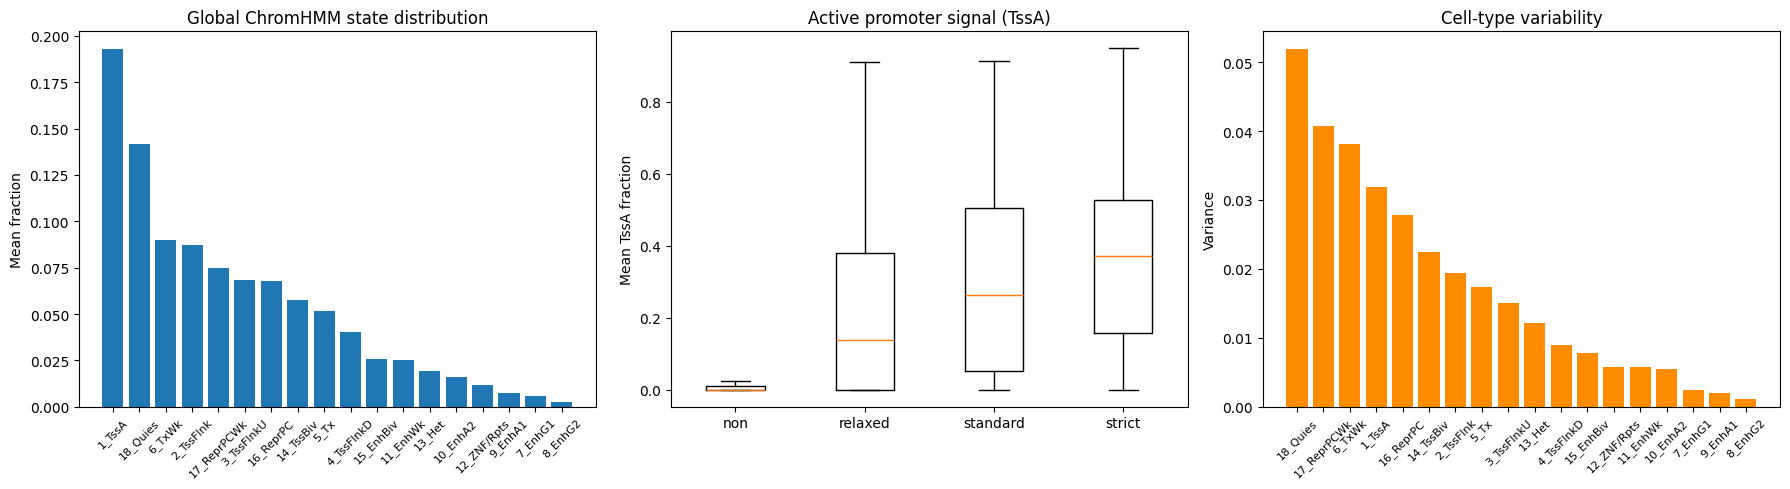

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import h5py

EPI_PROFILES_PATH = '/content/drive/MyDrive/PFE/data/processed/epi_profiles.parquet'
CLEAN_WINDOWS_PATH = '/content/drive/MyDrive/PFE/data/processed/clean_windows.parquet' # Path to the dataframe containing promoter_class
HDF5_PATH         = '/content/drive/MyDrive/PFE/data/processed/nt_checkpoint.h5' # This path is kept for potential future use or consistency, though not directly used for promoter_class here

# Label map for promoter class (needed for plotting, as it expects numeric values)
label_map = {
    "non_promoter": 0,
    "relaxed_promoter": 1,
    "standard_promoter": 2,
    "strict_promoter": 3
}

# ── Load data ────────────────────────────────────────────────
epi_df   = pd.read_parquet(EPI_PROFILES_PATH)
index_df = pd.read_parquet(CLEAN_WINDOWS_PATH) # Load index_df from clean_windows.parquet which includes 'promoter_class'

state_cols = [c for c in epi_df.columns if c.startswith('state_')]

# Convert promoter_class strings to numeric for plotting as expected by 'grouped' list comprehension
index_df['promoter_class_numeric'] = index_df['promoter_class'].map(label_map)

# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ─────────────────────────────────────────────────────────────
# 1. Global ChromHMM distribution
# ─────────────────────────────────────────────────────────────
mean_per_state = epi_df[state_cols].mean().sort_values(ascending=False)
mean_per_state.index = [c.replace("state_", "") for c in mean_per_state.index]

axes[0].bar(range(len(mean_per_state)), mean_per_state.values)
axes[0].set_title("Global ChromHMM state distribution")
axes[0].set_ylabel("Mean fraction")
axes[0].set_xticks(range(len(mean_per_state)))
axes[0].set_xticklabels(mean_per_state.index, rotation=45, fontsize=8)

# ─────────────────────────────────────────────────────────────
# 2. Promoter class vs TSS signal
# ─────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────
# 2. Promoter class vs ACTIVE TSS signal
# ─────────────────────────────────────────────────────────────

tss_col = 'state_1_TssA'

# mean across cell types for each tile
mean_tss = (
    epi_df.groupby("tile_id")[tss_col]
    .mean()
    .reset_index()
)

# merge with promoter labels
combined = index_df[["tile_id", "promoter_class_numeric"]].merge(
    mean_tss,
    on="tile_id",
    how="left"
)

combined[tss_col] = combined[tss_col].fillna(0)

labels = ["non", "relaxed", "standard", "strict"]

grouped = [
    combined.loc[
        combined["promoter_class_numeric"] == i,
        tss_col
    ]
    for i in range(4)
]

axes[1].boxplot(grouped, labels=labels, showfliers=False)

axes[1].set_title("Active promoter signal (TssA)")
axes[1].set_ylabel("Mean TssA fraction")
# ─────────────────────────────────────────────────────────────
# 3. Cell-type variability
# ─────────────────────────────────────────────────────────────
ct_var = (
    epi_df.groupby("tile_id")[state_cols]
    .var()
    .mean()
    .sort_values(ascending=False)
)

ct_var.index = [c.replace("state_", "") for c in ct_var.index]

axes[2].bar(range(len(ct_var)), ct_var.values, color="darkorange")
axes[2].set_title("Cell-type variability")
axes[2].set_ylabel("Variance")
axes[2].set_xticks(range(len(ct_var)))
axes[2].set_xticklabels(ct_var.index, rotation=45, fontsize=8)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/PFE/data/Figures/epi_profiles_qc_updated.png", dpi=150)
plt.show()

1. Global ChromHMM state distribution

The first figure summarizes the average ChromHMM composition across all CpG island windows and all cell types. The dominant state is 1_TssA (Active TSS), followed by 18_Quies, 6_TxWk, and several transcription-associated states. This is biologically coherent because CpG islands are well known to be enriched near promoters and transcriptionally active genomic regions. The strong presence of TssA confirms that the overlap and normalization pipeline correctly captures promoter-associated chromatin signatures. At the same time, the substantial proportion of Quiescent states indicates that not all CpG islands are active in every cell type, reflecting the context-dependent nature of epigenetic regulation and the fact that our windows contain flank. Overall, this distribution suggests that the generated epigenetic profiles preserve meaningful biological structure rather than random state assignments.

2. Active promoter signal (TssA) vs promoter classes

The second figure evaluates whether the promoter hierarchy based on distance to the nearest TSS is biologically meaningful. A clear monotonic trend is observed: CpG islands classified as strict promoters show the highest TssA enrichment, followed by standard promoters, relaxed promoters, and finally non-promoter islands, which exhibit near-zero TssA signal. This pattern strongly validates the new promoter annotation strategy because the ChromHMM active promoter state increases consistently as the island becomes closer to a transcription start site. The result also confirms that the previous issue observed with the old is_promoter definition was likely caused by using an overly broad promoter threshold. By replacing the binary annotation with a hierarchical distance-based promoter classification, the biological relationship between CpG islands and active promoter chromatin became much clearer and more interpretable.

3. Cell-type variability

The third figure measures how much each ChromHMM state varies across the 10 cell types for the same CpG island window. States such as 18_Quies, 17_ReprPCWk, 6_TxWk, and 1_TssA display the highest inter-cell-type variability, indicating that these states are highly dynamic and cell-type dependent. This is an important result because it demonstrates that the labels are informative rather than static. If all states showed near-zero variance, the task would reduce to predicting nearly constant outputs independent of cellular context. Instead, the observed variability suggests that the dataset captures meaningful epigenetic differences between cell types, which is exactly what the model should learn. The relatively lower variability of enhancer states may indicate that these CpG island windows are less enhancer-centric overall, which is expected since CpG islands are typically more promoter-associated than enhancer-associated.

In [ ]:
import seaborn as sns

combined = index_df[['tile_id', 'promoter_class']].merge(
    mean_tss_per_tile.reset_index(),
    on='tile_id',
    how='left'
)

ax = axes[1]

sns.boxplot(
    data=combined,
    x='promoter_class',
    y=tss_cols[0],
    ax=ax
)

ax.set_title("TSS enrichment across promoter classes")

In [ ]:
# FINAL SUMMARY
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*70)
print("SECTION COMPLETE — what was produced")
print("="*70)

print(f"""
FILES
─────
window_embeddings.npy   ({embeddings.shape[0]:,} × {embeddings.shape[1]})
  → one 512-d NT-v2 sequence embedding per tile (cell-type-agnostic)

window_index.parquet    ({len(index_df):,} rows)
  → metadata per tile: tile_id, chrom, coords, is_promoter, gc_content …
  → use as row index for embeddings (row i of index = row i of embeddings)

epi_profiles.parquet    ({len(epi_df):,} rows = {len(index_df):,} tiles × {len(chromhmm_data)} cell types)
  → columns: tile_id | cell_type | state_1TssA | … | state_18Quies
  → fraction vectors (18-d, sum ≈ 1.0 per row) normalised at BEDTools step
  → SEPARATE per cell type — not averaged — for cell-specific prediction

LABEL FORMAT (regression target)
─────────────────────────────────
  18-d fraction vector per (tile, cell_type)
  Values in [0,1], row sum = 1.0 (probability simplex)
  Suitable for: KL divergence loss or MSE loss

TRAINING-TIME JOIN (done inside the DataLoader, not stored as a file)
──────────────────────────────────────────────────────────────────────
  seq_emb = embeddings[tile_id_to_idx[tile_id]]     # (512,)
  epi_vec = epi_df[(tile_id, cell_type)][state_cols] # (18,)
  X       = seq_emb    #  input for now, the epigenetics to be added later
  y       = epi_vec                                  # (18,)   target

NOTE ON SPATIAL INFORMATION
────────────────────────────
  The 18-d fraction vector does NOT encode where within the window each
  state is located. For interpretation after prediction, use the original
  ChromHMM BED files intersected with the tile coordinates (win_start,
  win_end) stored in window_index.parquet.
  Segmentation (per-base or per-token state prediction) is a valid future
  extension but requires a different architecture.
""")


SECTION COMPLETE — what was produced

FILES
─────
window_embeddings.npy   (29,790 × 512)
  → one 512-d NT-v2 sequence embedding per tile (cell-type-agnostic)
 
window_index.parquet    (29,790 rows)
  → metadata per tile: tile_id, chrom, coords, is_promoter, gc_content …
  → use as row index for embeddings (row i of index = row i of embeddings)
 
epi_profiles.parquet    (297,900 rows = 29,790 tiles × 10 cell types)
  → columns: tile_id | cell_type | state_1TssA | … | state_18Quies
  → fraction vectors (18-d, sum ≈ 1.0 per row) normalised at BEDTools step
  → SEPARATE per cell type — not averaged — for cell-specific prediction
 
LABEL FORMAT (regression target)
─────────────────────────────────
  18-d fraction vector per (tile, cell_type)
  Values in [0,1], row sum = 1.0 (probability simplex)
  Suitable for: KL divergence loss or MSE loss
 
TRAINING-TIME JOIN (done inside the DataLoader, not stored as a file)
──────────────────────────────────────────────────────────────────────
  seq_e

In [ ]:
# Your sequence-phase outputs are on Drive but not where the script expects.
# The find command showed nothing — but that searched only /content/drive/MyDrive
# Let me search more carefully including different PFE folder locations

import subprocess
from pathlib import Path

# Search entire Drive, not just PFE subfolder
searches = [
    'window_index.parquet',
    'window_embeddings.npy',
    'nt_checkpoint.h5',
    'clean_windows.parquet',
    'island_masks.npy',
]

for filename in searches:
    result = subprocess.run(
        ['find', '/content/drive', '-name', filename, '-type', 'f'],
        capture_output=True, text=True, timeout=120
    )
    if result.stdout.strip():
        print(f"FOUND {filename}:")
        print(f"  {result.stdout.strip()}")
    else:
        print(f"NOT FOUND: {filename}")

FOUND window_index.parquet:
  /content/drive/MyDrive/PFE/data/processed/window_index.parquet
FOUND window_embeddings.npy:
  /content/drive/MyDrive/PFE/data/processed/window_embeddings.npy
FOUND nt_checkpoint.h5:
  /content/drive/MyDrive/PFE/data/processed/nt_checkpoint.h5
FOUND clean_windows.parquet:
  /content/drive/MyDrive/PFE/data/processed/clean_windows.parquet
FOUND island_masks.npy:
  /content/drive/MyDrive/PFE/data/processed/island_masks.npy


In [ ]:
import umap, matplotlib.pyplot as plt
import numpy as np, pandas as pd
from matplotlib.colors import ListedColormap

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ Fig 1 saved: umap_ntv2_chromhmm.png


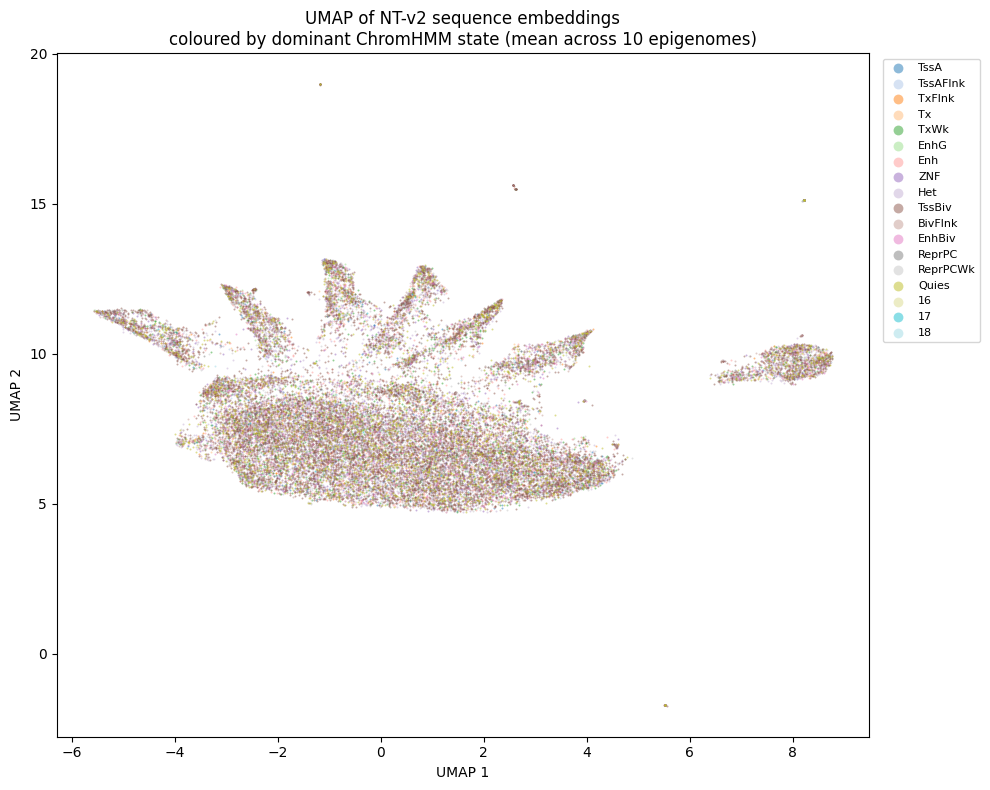

In [ ]:


emb = np.load('/content/drive/MyDrive/PFE/data/processed/window_embeddings.npy')   # (29820, 1024)
epi = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/epi_profiles.parquet')
STATE_COLS = [c for c in epi.columns if c.startswith('state_')]

# Use mean across epigenomes as the dominant state label
mean_states = epi.groupby('tile_id')[STATE_COLS].mean()
dominant    = mean_states.values.argmax(axis=1)  # (29820,)

reducer  = umap.UMAP(n_neighbors=30, min_dist=0.1,
                     metric='cosine', random_state=42)
emb_2d   = reducer.fit_transform(emb)

# 18-state palette
COLORS = plt.cm.tab20(np.linspace(0,1,18))
STATE_NAMES = ['TssA','TssAFlnk','TxFlnk','Tx','TxWk','EnhG','Enh',
               'ZNF','Het','TssBiv','BivFlnk','EnhBiv','ReprPC',
               'ReprPCWk','Quies','16','17','18']

fig, ax = plt.subplots(figsize=(10, 8))
for s in range(18):
    mask = dominant == s
    if mask.sum() < 10: continue
    ax.scatter(emb_2d[mask,0], emb_2d[mask,1],
               c=[COLORS[s]], label=STATE_NAMES[s],
               s=2, alpha=0.5, linewidths=0)
ax.legend(markerscale=5, bbox_to_anchor=(1.01,1), fontsize=8)
ax.set_title("UMAP of NT-v2 sequence embeddings\n"
             "coloured by dominant ChromHMM state (mean across 10 epigenomes)")
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.savefig("umap_ntv2_chromhmm.png", dpi=200, bbox_inches='tight')
print("✅ Fig 1 saved: umap_ntv2_chromhmm.png")

In [ ]:
import math


In [ ]:
window = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/window_index.parquet')
epi    = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/epi_profiles.parquet')

merged = epi.merge(window[['tile_id','is_promoter']], on='tile_id')

prom     = merged[merged['is_promoter'] == 1]['state_1_TssA']
non_prom = merged[merged['is_promoter'] == 0]['state_1_TssA']

print(f"Mean TssA fraction — promoter CGIs : {prom.mean():.4f}")
print(f"Mean TssA fraction — non-promoter  : {non_prom.mean():.4f}")
print(f"Fold enrichment                     : {prom.mean()/non_prom.mean():.1f}×")

# Statistical test
from scipy import stats
t, p = stats.mannwhitneyu(prom, non_prom, alternative='greater')
print(f"Mann-Whitney U p-value: {p:.2e}")
assert p < 0.05, "Promoter enrichment not significant!"
print("✅ Active TSS enrichment at promoter CGIs confirmed")

Mean TssA fraction — promoter CGIs : 0.3092
Mean TssA fraction — non-promoter  : 0.0301
Fold enrichment                     : 10.3×
Mann-Whitney U p-value: 0.00e+00
✅ Active TSS enrichment at promoter CGIs confirmed


In [ ]:
import pandas as pd, numpy as np

# The two sources of row ordering
seq_index = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/window_index.parquet')
epi_index = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/clean_windows_removed_duplicates.parquet')

# Do they have the same tile_ids in the same order?
seq_ids = seq_index['tile_id'].values
epi_ids = epi_index['tile_id'].values

print(f"Seq index rows: {len(seq_ids)}")
print(f"Epi index rows: {len(epi_ids)}")
print(f"Same length   : {len(seq_ids) == len(epi_ids)}")
print(f"Same order    : {(seq_ids == epi_ids).all()}")

if not (seq_ids == epi_ids).all():
    # Find first mismatch
    for i, (a, b) in enumerate(zip(seq_ids, epi_ids)):
        if a != b:
            print(f"First mismatch at row {i}: seq={a}  epi={b}")
            break

Seq index rows: 29790
Epi index rows: 29790
Same length   : True
Same order    : True


In [ ]:
import pandas as pd, numpy as np

index = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/window_index.parquet')

# Add explicit row position — this is the safe anchor
index['row_pos'] = np.arange(len(index))

# Verify embedding matches
emb = np.load('/content/drive/MyDrive/PFE/data/processed/window_embeddings.npy', mmap_mode='r')
assert emb.shape[0] == len(index)

seq_index = index[['tile_id','row_pos','chrom','win_start','win_end',
                    'is_promoter','gc_content','cpg_density','obsExp']].copy()

seq_index.to_parquet('/content/drive/MyDrive/PFE/data/processed/training_seq_index.parquet', index=False)
print(f"Saved: {len(seq_index):,} rows")
print(seq_index.head())

Saved: 29,790 rows
              tile_id  row_pos chrom  win_start  win_end  is_promoter  \
0    chr1:28735-29737        0  chr1      28212    30260         True   
1  chr1:135124-135563        1  chr1     134319   136367        False   
2  chr1:199251-200121        2  chr1     198662   200710        False   
3  chr1:368792-370063        3  chr1     368403   370451        False   
4  chr1:381172-382185        4  chr1     380654   382702        False   

   gc_content  cpg_density  obsExp  
0    0.729541   110.778442    0.85  
1    0.671982    68.337128    0.64  
2    0.739080   119.540230    0.89  
3    0.610543    77.891426    0.84  
4    0.724580    82.922012    0.64  


In [ ]:
import pandas as pd, numpy as np

BASE = '/content/drive/MyDrive/PFE/data/processed'
INDEX_PATH     = f'{BASE}/window_index.parquet'
SEQ_INDEX_PATH = f'{BASE}/training_seq_index.parquet'

# window_index.parquet is now correct — rebuild seq_index from it
idx = pd.read_parquet(INDEX_PATH)

# Verify it has the new columns before proceeding
assert 'promoter_class'   in idx.columns, "window_index missing promoter_class — run the patch first"
assert 'distance_to_tss'  in idx.columns, "window_index missing distance_to_tss"
assert 'is_promoter'      not in idx.columns, "window_index still has old is_promoter"

# Add explicit row position — this is the safe anchor for embedding lookup
idx['row_pos'] = np.arange(len(idx))

# Select columns needed at training time
seq_index = idx[['tile_id', 'row_pos', 'chrom', 'win_start', 'win_end',
                  'island_id', 'island_length', 'is_tiled',
                  'gc_content', 'cpg_density', 'obsExp',
                  'distance_to_tss', 'promoter_class']].copy()

seq_index.to_parquet(SEQ_INDEX_PATH, index=False)

# Verify
reload = pd.read_parquet(SEQ_INDEX_PATH)
assert len(reload) == 29790
assert 'promoter_class' in reload.columns
assert 'is_promoter' not in reload.columns
assert reload['row_pos'].is_monotonic_increasing
assert reload['promoter_class'].isna().sum() == 0

print(f"training_seq_index saved ✅  ({len(reload):,} rows)")
print(f"Columns : {reload.columns.tolist()}")
print(f"\nClass distribution:")
print(reload['promoter_class'].value_counts())
print(f"\nSample:")
print(reload[['tile_id','row_pos','chrom','distance_to_tss','promoter_class']].head())

training_seq_index saved ✅  (29,790 rows)
Columns : ['tile_id', 'row_pos', 'chrom', 'win_start', 'win_end', 'island_id', 'island_length', 'is_tiled', 'gc_content', 'cpg_density', 'obsExp', 'distance_to_tss', 'promoter_class']

Class distribution:
promoter_class
non_promoter         13936
strict_promoter      10739
standard_promoter     3162
relaxed_promoter      1953
Name: count, dtype: int64

Sample:
              tile_id  row_pos chrom  distance_to_tss   promoter_class
0    chr1:28735-29737        0  chr1              134  strict_promoter
1  chr1:135124-135563        1  chr1             5223     non_promoter
2  chr1:199251-200121        2  chr1             6911     non_promoter
3  chr1:368792-370063        3  chr1            82251     non_promoter
4  chr1:381172-382185        4  chr1            70000     non_promoter


In [ ]:
import h5py

with h5py.File('/content/drive/MyDrive/PFE/data/processed/nt_checkpoint.h5', 'a') as f:
    f['annotations'].attrs['note'] = (
        "promoter_class is encoded as integers here. "
        "String labels are in training_seq_index.parquet and window_index.parquet. "
        "Use promoter_class_reverse_map to decode."
    )
print("Note added ✅")

Note added ✅
